# An Earth-Venus-Earth Link Budget from Open Research Institute
This document contains a detailed link budget analysis for Earth-Venus-Earth (EVE) communications. It begins with a Python dataclass for each fixed earth station. Dataclasses are a type of Python object where only variables are declared. No methods are included. The site-specific dataclasses have parameters that are true for the site regardless of the target. Following the site-specific dataclasses are link budget classes, which contain target-specific values and methods that return various gains and losses. The most important output of a link budget object is a carrier to noise ratio at a particular receive bandwidth. A link budget class inherits a particular site dataclass. The site-specific dataclasses and the link budgets can be mixed and matched. This gives flexibility, as a link budget for a particular target, such as EVE, can be calculated for different sites by having that link budget inherit different site-specific dataclasses. 

## What is a Link Budget?

If you have ever planned out income and expenses with respect to pay, and handled monthly bills, then you have used a budget. A budget is a balance between an amount of something coming into an account or collection, and an amount of something going out. A link budget uses the same concepts as a financial budget, with income (gain) and expenses (losses) counted up over a period of time and space. The link in link budget is the physical path or link between transmitter and receiver. Like financial budgeting, link budgets can range from a very simple picture of financial activity to a very complex accounting of a wide variety of types of income and expenses. 

Link budgets are models of the real world. There are many ways to represent the physical environment and almost any model of that environment can be improved. A simple link budget can be very useful. A complex one can be very wrong. 

A high quality link budget is accurate, accessible, and flexible. Link budgets can be used in a variety of ways. The most familiar role is predictive, where a link budget is used to design a communications experiment or system implementation. Link budgets can also be used as documentation. These are accurate only after the fact of a communications experiment or system implementation. Finally, link budgets are an excellent educational resource, providing a system-level view of radio communications. The goal for this link budget is to be useful in all three of these roles: predictive, documentary, and educational. 

This link budget is written in an object oriented coding style. An object oriented style means that we construct our calculations so that they can be controlled and manipulated in a modular manner. The gains and losses are described using classes. Classes are structures that contain members and methods. Members, which are things like variables and constants, are the "nouns" of our model. The methods, or functions, are the "verbs". When we think about our link budget, we group members and methods that are related to particular concepts. For example, one of the first classes in the link budget has to do with noise temperature, which is a very important part of our radio environment. The amount of noise impacts signal reception and performance. We need to know where sources of noise come from, and account for them.

Once we have decided on a topic or subject, we define a class. We list the members and the methods that belong to that class. Then we use our class definition to create a calculator. Think of a calculator as if you had a physical custom-designed calculator that let you enter in everything having to do with, say, noise temperature. Each member could be given a value through a keypad. Each method might have its own button. You press the button and, as long as you've defined all the members needed by that method, the answer to that particular calculation pops out. We use several different calculators along the way as we build up all the gains and losses of our link budget. Deciding what work goes into what class is part of the art of computer programming. Two different people, when given the same problem, and each deciding to use object oriented techniques, may come up with very different class structures for their code. The first person might have approached the problem in a highly modular way, with many classes and lots of intermediate results. The second person might have solved the problem with one class, doing things in less steps but with more complexity per step. As long as the right answer comes out and the program doesn't use more resources than are available, both approaches are valid.

## EVE compared to EME
The communications mode most similar to EVE is Earth-Moon-Earth (EME). EVE is more challenging than EME communications due to several factors.

1. Much greater distances involved
2. Greater variability in the distances involved
3. Doppler rate of change due to orbital positions of Earth and Venus changing with respect to each other
4. Different signal reflection characteristics from Venus compared to the Moon
5. Doppler spreading, which is a type of Doppler due to the signal being reflected off a rotating object. 


## Contributors
The team contributing to the link budget includes but is not limited to Michelle Thompson, Matthew Wishek, Paul Williamson, Rose Easton, Thomas Telkamp, Pete Wyckoff, Gary K6MG, Lee Blanton, and John K5JBT. Questions or comments about this document can be directed to the issues and pull request functions in the repository https://github.com/OpenResearchInstitute/EVE, or one can write an email to hello at openresearch dot institute.


## Imports

This link budget is written in a Jupyter Lab Notebook, using the Python computer language. We import the Python modules that we need for the project. Some cells may repeat some of the imports. 

In [1]:
# Imports
import numpy as np
import scipy
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Dict, Any
from skyfield.api import load, wgs84
from datetime import datetime, timedelta, timezone
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math
import plotly.io as pio
pio.renderers.default = "notebook"

## Dataclass Definitions

Dataclasses in Python are classes that contain only variables and constants. In other words, they are only "nouns", containing no methods. Our dataclasses contain information about specific sites. Each site gets its own dataclass. We set up dataclasses using the naming format SiteNameLinkParameters. Values for the members of the class have been given to us from sites such as Deep Space Exploration Society (DSES), who first asked for assistance with an EVE link budget. Our dataclasses set the values that are true for these sites regardless of the celestial target. For example, 1296 MHz (23cm band) is a common frequency for all sorts of communications, not just EVE. The location and elevation of a site remains the same no matter what it's pointing at. Values like this belong to the SiteNameLinkParameters class.

Can you see three values that could belong to a PhysicalConstants dataclass? Unless the speed of light, Boltzmann's constant, and reference temperature are specific to a particular site, then these values are the sort of thing that should be moved to dataclass dedicated to Physical Constants. This is just one of many decisions along the way that we might need to make in order to improve our link budget. 

In [30]:
# Dataclass Definitions
@dataclass
class DSESLinkParameters: #things that are true for the site regardless of the target
    # location of this dish in Google Earth is 38°22'51"N 103°09'22"W
    latitude: float = 38.380833 # from FCC converter
    longitude: float = -103.156111 # from FCC converter
    elevation: float = 1311 # meters, from online calculator
    default_elevation_deg: float = 30.0 # Venus elevation near conjunction
    receive_only: bool = False   # default - sites can transmit and receive
#    tx_frequency_mhz: float = 1296.0 # Transmit frequency
    tx_frequency_mhz: float = 2304.0 # Transmit frequency anticipated for October 2026
    tx_power_w: float = 1500.0 # Transmit power in watts
    tx_antenna_diameter_m: float = 18.29 # Transmit antenna diameter
    tx_antenna_efficiency: float = 0.69 # Transmit antenna efficiency
    rx_antenna_diameter_m: float = 18.29 # Receive antenna diameter
    rx_antenna_efficiency: float = 0.69 # Receive antenna efficiency
    tx_line_loss_db: float = 0.5 # provided
    rx_line_loss_db: float = 0.5 # provided
    pointing_error_deg: float = 0.01 # provided
    lna_noise_figure_db: float = 0.4 # from datasheet for the Kuhne MKU LNA 132 AH SMA
    lna_noise_figure_K: float = 290 * (10**(lna_noise_figure_db/10) - 1) # calculated from lna_noise_figure_db
    receiver_noise_bandwidth: float = 100e3 # operational receiver bandwidth. 
    c: float = 299792458  # Speed of light in m/s
    k: float = 1.380649e-23  # Boltzmann constant in J/K
    t0: float = 290  # Reference temperature in K


@dataclass
class DwingelooLinkParameters: #things that are true for the site regardless of the target
    latitude: float = 52.81213723180477 # from Thomas
    longitude: float = 6.396346463227839 # from Thomas
    elevation: float = 70.26 # from Thomas
    default_elevation_deg: float = 20.0 # Venus elevation near conjunction
    receive_only: bool = False   # default - sites can transmit and receive
    tx_frequency_mhz: float = 1299.5 # Transmit frequency from Thomas
#    tx_frequency_mhz: float = 2304.0 # Transmit frequency anticipated for October 2026
    tx_power_w: float = 1000.0 # Transmit power in watts
    tx_antenna_diameter_m: float = 25 # Transmit antenna diameter from Thomas
    tx_antenna_efficiency: float = 0.69 # Transmit antenna efficiency from Thomas
    rx_antenna_diameter_m: float = 25 # Receive antenna diameter from Thomas
    rx_antenna_efficiency: float = 0.69 # Receive antenna efficiency from Thomas
    tx_line_loss_db: float = 0.5 # best guess
    rx_line_loss_db: float = 0.5 # best guess
    pointing_error_deg: float = 0.01 # best guess
    lna_noise_figure_db: float = 0.629 # best guess working backwards from a Tsys = 65 measured recently from Thomas
    lna_noise_figure_K: float = 290 * (10**(lna_noise_figure_db/10) - 1) # calculated from lna_noise_figure_db
    receiver_noise_bandwidth: float = 100e3 # operational receiver bandwidth. 
    c: float = 299792458  # Speed of light in m/s
    k: float = 1.380649e-23  # Boltzmann constant in J/K
    t0: float = 290  # Reference temperature in K


@dataclass
class StockertLinkParameters:
    # Astropeiler Stockert 25 m, Bad Muenstereifel, Germany (DL0EF)
    # Contact: Astropeiler Stockert e.V. they announced a detailed
    # technical write-up of the March 2025 EVE reception was forthcoming.
    # obtaining it would retire most TBDs below.
    latitude: float = 50.5700      # degrees N (Wikipedia)
    longitude: float = 6.7233      # degrees E (Wikipedia)
    elevation: float = 435.0       # meters (Wikipedia)
    default_elevation_deg: float = 20.0  # Venus elevation near conjunction
                                         # same convention as other EU sites
    receive_only: bool = True      # TBD no published 23cm TX capability
                                   # found for the 25 m dish and DL0EF absent
                                   # from PA0PLY 1296 EME station list.
    tx_frequency_mhz: float = 1299.5  # rx focus matches the frequency it
                                      # demonstrably received in March 2025.
                                      # Receiver coverage 1280–1430 MHz per
                                      # astropeiler.de instruments page
    tx_power_w: float = 0.0           # rx only
    tx_antenna_diameter_m: float = 25.0  # confirmed (Wikipedia, astropeiler.de)
    tx_antenna_efficiency: float = 0.69  # copied from the Dwingeloo convention (same-vintage
                                         # 1956 25 m dish), not measured
    rx_antenna_diameter_m: float = 25.0  # confirmed
    rx_antenna_efficiency: float = 0.69  # same caveat
    tx_line_loss_db: float = 0.0   # rx only
    rx_line_loss_db: float = 0.5   # TBD assumed, notebook convention
    pointing_error_deg: float = 0.01  # TBD assumed, notebook convention
    lna_noise_figure_db: float = 0.6  # inferred, not measured.
                                      # CAMRAS reports Stockert's receive
                                      # chain "a bit more sensitive" than
                                      # Dwingeloo's (measured Tsys = 65 K,
                                      # i.e. NF equiv 0.629 dB), so the true
                                      # value sits slightly below that.
                                      # Caltech-donated LNAs installed 2022.
                                      # Try and get the measured Tsys from Astropeiler.
                                      # We asked late 2025.
    lna_noise_figure_K: float = 290 * (10**(lna_noise_figure_db/10) - 1)  # derived
    receiver_noise_bandwidth: float = 100e3  # notebook convention
    c: float = 299792458           # Speed of light in m/s
    k: float = 1.380649e-23        # Boltzmann constant in J/K
    t0: float = 290                # Reference temperature in K
 
 
# Action Items
# Ask after the Astropeiler's technical write-up of the 2025-03-22 EVE
# reception (announced by CAMRAS as forthcoming). This should provide
# measured Tsys, and possibly efficiency and pointing. Asked, waiting.
# Aperture efficiency: assumed 0.69 by analogy with Dwingeloo,
# replace with a Stockert measurement if we get it.
# Receive line loss: assumed.
# Pointing error: assumed, asked for the drive system's actual spec.
# lna_noise_figure_db is an inferred upper bound from a qualitative
# CAMRAS statement, and is not a measurement. 

@dataclass
class BochumLinkParameters:
    # AMSAT-DL dish, Bochum, Germany
    # Contact: AMSAT-DL / Bochum team for verification of all RF parameters
    # Location from published sources — confirm with contact
    latitude: float = 51.440000    # degrees N  # VERIFY
    longitude: float = 7.210000    # degrees E  # VERIFY
    elevation: float = 100.0       # meters     # VERIFY
    default_elevation_deg: float = 20.0 # Venus elevation near conjunction
    receive_only: bool = False   # might be receive only for October 2026
    tx_frequency_mhz: float = 2304.0            # VERIFY — confirm they can tx at 2304
    tx_power_w: float = 250.0                  # 2009 used magnetron ~7kW, current setup is 250 W as per P. Gülzow
    tx_antenna_diameter_m: float = 20.0
    tx_antenna_efficiency: float = 0.69         # VERIFY — assumed typical parabolic, not Bochum-specific
    rx_antenna_diameter_m: float = 20.0
    rx_antenna_efficiency: float = 0.69         # VERIFY — assumed, not measured
    tx_line_loss_db: float = 0.5                # VERIFY
    rx_line_loss_db: float = 0.5                # VERIFY
    pointing_error_deg: float = 0.01            # VERIFY
    lna_noise_figure_db: float = 0.5            # VERIFY — no datasheet value in hand
    lna_noise_figure_K: float = 290 * (10**(lna_noise_figure_db/10) - 1)  # derived
    receiver_noise_bandwidth: float = 100e3     # VERIFY - this is a guess
    c: float = 299792458
    k: float = 1.380649e-23
    t0: float = 290

@dataclass
class GBTLinkParameters:
    # Green Bank Telescope — receive-only for EVE! need bistatic approach!
    # National Radio Quiet Zone — no transmission possible
    latitude: float = 38.433     # degrees N  # VERIFY via GBO
    longitude: float = -79.840   # degrees E  # VERIFY via GBO
    elevation: float = 807.0     # meters     # VERIFY via GBO
    default_elevation_deg: float = 32.0 # Venus elevation near conjunction
    receive_only: bool = True   # Green Bank is receive only
    tx_frequency_mhz: float = 2304.0          # not applicable — rx only, but we need to have a value here
    #tx_frequency_mhz: float = 1299.5          # not applicable — rx only, but we need to have a value here
    tx_power_w: float = 0.0                   # rx only
    tx_antenna_diameter_m: float = 100.0      # confirmed
    tx_antenna_efficiency: float = 0.71       # VERIFY — use GBT sensitivity calculator
    rx_antenna_diameter_m: float = 100.0      # confirmed
    rx_antenna_efficiency: float = 0.71       # VERIFY — use GBT sensitivity calculator
    tx_line_loss_db: float = 0.0              # rx only
    rx_line_loss_db: float = 0.5             # VERIFY
    pointing_error_deg: float = 0.001        # VERIFY — GBT pointing is exceptional
    lna_noise_figure_db: float = 0.3         # VERIFY — use GBT sensitivity calculator at 2304 MHz
    lna_noise_figure_K: float = 290 * (10**(lna_noise_figure_db/10) - 1)
    receiver_noise_bandwidth: float = 100e3
    c: float = 299792458
    k: float = 1.380649e-23
    t0: float = 290

@dataclass
class EffelsbergLinkParameters:
    # Effelsberg 100m Radio Telescope, Max Planck Institute for Radio Astronomy
    # Bad Münstereifel-Effelsberg, Germany
    # Coordinates, elevation, diameter, and pointing below are from the
    # MPIfR 100m telescope technical specifications page.
    # Remaining VERIFY flags are parameters the MPIfR tech-spec sheet does not cover.
    latitude:  float = 50.524833   # 50° 31' 29.4" N  (MPIfR spec)
    longitude: float =  6.883611   #  6° 53' 01.0" E  (MPIfR spec)
    elevation: float = 369.0       # intersection of main axes, m (MPIfR spec)
    default_elevation_deg: float = 20.0   # Venus elevation near conjunction
    # Operational elevation range is 8.1°–89° per MPIfR spec;
    # consider using 8.1° as min_elevation in visibility plots.
    receive_only: bool = True             # assume receive-only for EVE
    tx_frequency_mhz: float = 1299.5      # focus on 1299.5 for now
    #tx_frequency_mhz: float = 2304.0      # 
    tx_power_w: float = 0.0               # receive-only placeholder
    tx_antenna_diameter_m: float = 100.0  # MPIfR spec (confirmed)
    tx_antenna_efficiency: float = 0.69   # VERIFY — assumed; Ruze surface η ≈ 1.00
                                          # at L/S-band from 0.5 mm RMS, but total
                                          # aperture efficiency requires MPIfR measurement
    rx_antenna_diameter_m: float = 100.0  # MPIfR spec (confirmed)
    rx_antenna_efficiency: float = 0.69   # VERIFY — same caveat as tx
    tx_line_loss_db: float = 0.5          # VERIFY — not in MPIfR spec sheet
    rx_line_loss_db: float = 0.5          # VERIFY — not in MPIfR spec sheet
    pointing_error_deg: float = 0.000556  # 2 arcsec effective (MPIfR spec: 1–2 arcsec)
    lna_noise_figure_db: float = 0.3      # VERIFY — depends on receiver choice
    lna_noise_figure_K: float = 290 * (10**(lna_noise_figure_db/10) - 1)
    receiver_noise_bandwidth: float = 100e3
    c: float = 299792458
    k: float = 1.380649e-23
    t0: float = 290

# =============================================================================
# Standalone dataclass for review. Candidate JA (Japan) station for EVE
#
#
#      Action Item: try and contact JH1KRC Mike Watanabe. He's a prominent Japanese 23cm
#      EME operator.
#
#      A JARL-affiliated "big gun" infrastructure was 8N1EME. This was 
#      also known as Project BIG_DISH. It was a 32-meter
#      Mitsubishi Electric Cassegrain antenna (IBA-4) at the former KDDI
#      Ibaraki Satellite Communication Center, Takahagi City, grid QM06.
#      Special license issued to the JARL Ibaraki Branch and 40 operators
#      involved including JH1KRC. They did/do CW/SSB/JT65 EME on 
#      144/432/1296/5760 MHz with 323 EME QSOs completed (2007–2008 era operations).
#
#      So, KDDI decommissioned the site and the two 32 m antennas 
#      (Takahagi + Hitachi) were handed to NAOJ and are now
#      operated by NAOJ / Ibaraki University as VLBI radio telescopes
#      (Japanese VLBI Network, East Asia VLBI Network).
#      As an amateur transmit site it is unavailable today.
#      As a professional receive partner, potentially interesting,
#      with the same bistatic pattern as GBT and Effelsberg in this notebook.
#
#      Japan's 23cm amateur allocation is 1260–1300 MHz, so 1296–1299.5 MHz
#      operation is in-band for JA stations. However, Japan has no amateur 
#      allocation at 2300–2305 MHz (JA 13cm is 2400–2450),
#      so a JA station could not transmit in the proposed October 2026
#      2304 MHz campaign.
#
# The dataclass below models the real site (Takahagi 32 m), receive-only,
# at 1299.5 MHz. Values are labeled confirmed vs. TBD or verify, as usual.
# =============================================================================


@dataclass
class Takahagi32mLinkParameters:
    # Former KDDI Ibaraki Satellite Communication Center (8N1EME site),
    # Takahagi City, Japan with grid QM06.
    # Now the NAOJ / Ibaraki University Takahagi 32 m radio telescope.
    # Contact path: Ibaraki University Center for Astronomy / NAOJ Mizusawa;
    # amateur liaison historically via Project BIG-DISH (JH1KRC et al.)
    latitude: float = 36.694444    # 36°41'40" N (NAOJ Ibaraki station page)
    longitude: float = 140.695556  # 140°41'44" E (NAOJ Ibaraki station page)
                                   # NAOJ lists one coordinate pair for the
                                   # two-antenna site; TBD which pair really
                                   # is Takahagi vs. Hitachi? (they are super close)
    elevation: float = 100.0       # meters TBD! PLACEHOLDER, not
                                   # sourced from any data so get from NAOJ/VLBI
                                   # station catalog (ITRF position exists)
    default_elevation_deg: float = 20.0  # Venus elevation near conjunction
                                         # TBD compute for QM06
    receive_only: bool = True      # site is now a radio telescope and no current
                                   # amateur transmit is done here as far as I can tell.
                                   # Historical 8N1EME TX values kept below,
                                   # zeroed/annotated, in case a new special
                                   # license like the JARL Ibaraki Branch 2007
                                   # can happen again.
    tx_frequency_mhz: float = 1299.5  # not applicable, rx only, value here
                                      # for the framework. 1299.5 is inside the
                                      # JA 1260–1300 MHz allocation.
    tx_power_w: float = 0.0        # rx only (8N1EME historically ran 500 W
                                   # per band under its special license according to
                                   # EME2008 conference paper)
    tx_antenna_diameter_m: float = 32.0  # confirmed (Mitsubishi Electric
                                         # Cassegrain, IBA-4, 1980s INTELSAT)
    tx_antenna_efficiency: float = 0.60  # TBD assumed for a telecom
                                         # Cassegrain at L-band. Not measured.
                                         # PASJ paper on the astronomy upgrade
                                         # may have measured aperture
                                         # efficiency, maybe we can pull it from there
    rx_antenna_diameter_m: float = 32.0  # confirmed (same dish)
    rx_antenna_efficiency: float = 0.60  # TBD same note as tx
    tx_line_loss_db: float = 0.0   # rx only
    rx_line_loss_db: float = 0.5   # TBD assumed, matches other sites' 
                                   # convention for unknowns; depends entirely
                                   # on which receiver/feed is in the beam now though.
    pointing_error_deg: float = 0.01  # TBD and assumed but a VLBI telescope
                                      # likely does much better, so get spec
    lna_noise_figure_db: float = 0.2  # HISTORICAL: HB9BBD LNA @ 1296 MHz used
                                      # by 8N1EME (EME2008 paper). Current
                                      # astronomy receiver Tsys at 1.3 GHz is
                                      # totally TBD and 23cm may not even be
                                      # among its current observing bands
    lna_noise_figure_K: float = 290 * (10**(lna_noise_figure_db/10) - 1)  # derived
    receiver_noise_bandwidth: float = 100e3  # notebook convention
    c: float = 299792458           # Speed of light in m/s
    k: float = 1.380649e-23        # Boltzmann constant in J/K
    t0: float = 290                # Reference temperature in K


# =============================================================================
# ACTION ITEMS
# [AI-1] Resolve which coordinate pair is the Takahagi antenna vs. Hitachi
#        (both 32 m, same former KDDI site area). VLBI station catalogs have
#        exact ITRF positions for each.
# [AI-2] Elevation is a placeholder so we need to get true height from NAOJ/JVN station data.
# [AI-3] Compute Venus elevation from QM06 near the Oct 2026 conjunction
#        (site is well-placed for a Pacific-longitude receive slot the
#        European dishes can't cover. This is worth checking mutual visibilit
#        and we can in the visibility section below).
# [AI-4] Determine whether ANY current amateur access path exists Contact:
#        Project BIG-DISH alumni / JH1KRC; Ibaraki Univ. Center for Astronomy.
# [AI-5] Aperture efficiency: check the PASJ paper "Hitachi and Takahagi 32 m
#        radio telescopes: Upgrade of the antennas from satellite
#        communication to radio astronomy" for measured values. Asked for a copy,
#        could not find it online. 
# [AI-6] Verify Japanese amateur allocations and operating culture. 
#        1260–1300 MHz believed available and 2300–2305 MHz believed not.
# [AI-7] Line loss: depends on current feed/receiver chain unknown, but small.
# [AI-8] Pointing spec for the telescope in its astronomy configuration.
# [AI-9] Current receiver coverage: confirm the telescope even has a 1.3 GHz
#        (L-band) receiver in its present VLBI instrument suite. Its normal
#        bands may be 6.7/8/22 GHz methanol/continuum/water-maser work.
# =============================================================================


## Select the Site

We select the site that we want to use for the link budget by setting the variable SiteLinkParameters to the name of one of the desired dataclasses defined above. If the link budget is transmitting from and receiving to the same station, then it's a monostatic link budget. The `receive_only` boolean value in the dataclass must be set to `False`. The link budget analysis uses the transmitter and receiver from the site named below. 

In [3]:
SiteLinkParameters = DwingelooLinkParameters

## What Sites Might be Involved?

Let's take a moment to talk about what sites are involved in this sort of amateur radio and amateur radio astronomy work. 

### Dwingeloo Radio Observatory (Netherlands)

Completed in 1956, the Dwingeloo Radio Telescope features a 25-meter dish that was briefly the world's largest fully steerable radio telescope. After ending scientific operations in 2000, it was designated as a national heritage site in 2009. Since 2007, the C.A. Muller Radio Astronomy Station (CAMRAS) foundation has restored and operates the telescope for amateur radio astronomy and Earth-Moon-Earth (EME) communication. Today, Dwingeloo stands as the world's largest radio telescope for amateur use, with volunteers conducting radio astronomy observations, supporting educational outreach, and participating in special projects like visual moonbounce. This information is from Wikipedia and CAMRAS. 

### Stockert Radio Telescope (Germany)

Inaugurated on September 17, 1956, the 25-meter Stockert dish was Germany's first telescope for radio astronomy. After serving the University of Bonn and Max Planck Institute until 1995, it gained historical monument status in 1999. Since 2005, the telescope has been owned by the Nordrhein-Westfalen-Stiftung and is maintained by Astropeiler Stockert e.V., a volunteer association that proudly calls it "the largest and most capable radio telescope in the world operated by amateurs." Astropeiler The facility is now equipped with modern technology for scientific observations, student education, and public outreach. This information is from Wikipedia and Stockert.
 
### Deep Space Exploration Society (DSES) (Colorado, USA)

The DSES is a Colorado-based nonprofit organization dedicated to practical astronomy and space science education. Its primary facility is a restored 60-foot dish antenna located in Kiowa County, Colorado. Known as the Paul Plishner Radio Astronomy and Space Sciences Center, the site features a former National Bureau of Standards antenna originally built for tropospheric propagation research between 1957-1974. In addition to radio astronomy research, DSES uses its 60-foot dish for amateur radio EME (moonbounce) activities on the 432 and 1296 MHz bands. This information is from Wikipedia and DSES.

### Bochum Observatory (Germany)

Founded in 1946 by Professor Heinz Kaminski as a popular observatory, Bochum Observatory gained international recognition after detecting signals from Sputnik 1 in 1957. Its 20-meter parabolic antenna, inaugurated in 1965, became famous during the 1957-1975 period for receiving transmissions from Russian and American space vehicles, including Apollo missions. Today, the facility participates in research projects with NASA and DLR, receiving solar data from space probes while also serving as an educational center focusing on sustainability, climate change, and sky observation. This information is from Wikipedia and Bochum.

These historic sites represent the essential bridge between professional radio astronomy and amateur radio enthusiasts, making significant contributions to astronomical research, space communication, and public education while preserving important scientific heritage. When we say Dwingeloo, Stockert, DSES, or Bochum, we are talking about specific station configurations that are located at these sites. Each site has multiple configurations for a wide variety of scientific and communications targets. 

### Green Bank Telescope (West Virginia, USA)
The largest fully steerable dish in the world, and strictly receive-only for our purposes: it sits inside the National Radio Quiet Zone, so no transmission is possible. Any link budget involving GBT is bistatic by definition. Aperture efficiency and receiver noise figures should be pulled from the GBT sensitivity calculator rather than the placeholder values.

### Effelsberg (Germany)
The Max Planck Institute for Radio Astronomy's 100 m telescope. Coordinates, elevation, diameter, and pointing are from the MPIfR technical specification page (pointing is 1–2 arcseconds — effectively perfect for our beamwidths); aperture efficiency and line losses are not covered by the spec sheet and remain assumptions. Modeled as receive-only for EVE.

### Takahagi, Ibaraki, (Japan)
The former KDDI Ibaraki Satellite Communication Center antenna, famous in amateur circles as the 8N1EME "Project BIG-DISH" station (2007–2008), which ran EME on 144 through 5760 MHz under a special license issued to the JARL Ibaraki Branch. KDDI has since decommissioned the site, and the dish is now a radio telescope operated by NAOJ and Ibaraki University for VLBI work. Therefore, it is modeled receive-only, and even that requires confirming a current L-band receiver exists and an observing-time path is possible. This is a Pacific-longitude receive site that covers mutual-visibility windows that no European or North American dish can cover. See and clear action items in the dataclass.

| Site | Diameter | TX / RX | Frequency (MHz) | Data quality |
|---|---|---|---|---|
| DSES | 18.3 m | TX + RX | 2304 | Provided by site team |
| Dwingeloo | 25 m | TX + RX | 1299.5 | Provided by Thomas |
| Stockert | 25 m | RX only (TX TBD) | 1299.5 | Position confirmed and RF inferred/assumed |
| Bochum | 20 m | TX + RX (TBD) | 2304 (VERIFY) | Mostly unverified |
| GBT | 100 m | RX only | — | Placeholders; use GBT calculator |
| Effelsberg | 100 m | RX only | — | MPIfR spec + assumptions |
| Takahagi | 32 m | RX only (TBD) | — | Historical + placeholders |



## System Noise Temperature Worksheet

### Introduction

The system noise temperature is an important factor in determining the sensitivity of a radio telescope or communication system. It represents the total noise from all sources that affects the system's ability to detect weak signals. It is measured in Kelvin (K).

Unlike signal strength, which scales with dish diameter, system noise temperature is largely independent of the physical size of the antenna. Instead, it depends on factors related to the quality of the antenna construction, receiver electronics, and environmental conditions.

### Key Components

This system noise temperature calculation has the following components

1. Sky Noise (T_sky): Background radiation from the whole universe anda model of atmospheric contributions. This varies with elevation angle (more atmosphere at lower angles) and weather conditions (clear, cloudy, rainy).

2. Spillover Noise (T_spillover): Noise caused by the antenna feed pattern transmitting energy beyond the dish edges. This means it also picks up thermal radiation from the ground. This is determined by the feed design and positioning.

3. Scatter Noise (T_scatter): Noise resulting from dish surface imperfections that scatter incoming signals. Calculated using the Ruze equation, which relates surface RMS errors to performance degradation at a given wavelength.

4. Receiver Noise (T_receiver): Noise generated by the receiver's electronic components, often specified as noise figure or noise temperature.

### Total System Temperature

The total system noise temperature is calculated as:

T_sys = T_ant + T_receiver

Where T_ant (the antenna temperature) is the combination of sky noise, spillover noise, and scatter noise:

T_ant = (main_beam_efficiency * T_sky) + T_spillover + T_scatter

### Impact on Performance

A lower system noise temperature directly translates to better sensitivity. For deep space communications, minimizing each noise component is essential. The best way to do this is to use high-quality low-noise amplifiers (LNAs). The noise from the LNA is the most significant factor at the receiver. Precise dish surfaces minimize scatter noise. If they're out of round or warped, then there's a degradation. Well-designed feeds reduce spillover noise. The feed needs to be matched as well as it can be to the dish dimension. Operating at higher elevation angles when possible reduces sky noise because we're going through less of the atmosphere. 

This worksheet implements some calculations for each of these noise components. The goal is to produce a realistic system performance assessment, and to provide a solid system noise temperature to the Link Budget calculation. 

In [4]:
#import numpy as np
#from dataclasses import dataclass
#from typing import Optional, Dict, Any

class SystemNoiseTemperature:
    """
    A class to calculate system noise temperature for radio systems.
    """
    
    def __init__(self, params: 'SiteLinkParameters'):
        """
        Initialize the system noise temperature calculator.
        
        Parameters:
        params (SiteLinkParameters): The link parameters object containing system settings
        """
        self.params = params
    
    def calculate_sky_noise(self, elevation_angle_deg: float, atmospheric_conditions: str = 'clear') -> float:
        """
        Calculate sky noise temperature based on frequency and elevation angle.
        
        Parameters:
        elevation_angle_deg (float): Elevation angle in degrees
        atmospheric_conditions (str): Weather conditions ('clear', 'cloudy', 'rain')
        
        Returns:
        float: Sky noise temperature in Kelvin
        """
        # Convert elevation angle to radians
        elev_rad = np.radians(elevation_angle_deg)
        
        # Basic atmospheric attenuation model
        base_temp = 2.7  # cosmic background radiation
        
        # Atmospheric contribution increases at lower elevation angles
        air_mass = 1.0 / np.sin(elev_rad)
        
        # Frequency dependent atmospheric absorption
        freq_ghz = self.params.tx_frequency_mhz / 1000.0
        freq_factor = 0.1 * freq_ghz / 10.0
        
        # Weather condition factors
        weather_factors = {
            'clear': 1.0,
            'cloudy': 1.5,
            'rain': 3.0
        }
        
        weather_multiplier = weather_factors.get(atmospheric_conditions, 1.0)
        
        return base_temp + (270 * (1 - np.exp(-freq_factor * air_mass))) * weather_multiplier

    def calculate_spillover_noise(self, spillover_efficiency: float, ground_temp: float = 290.0) -> float:
        """
        Calculate spillover noise contribution.
        
        Parameters:
        spillover_efficiency (float): Efficiency of the antenna's spillover (0-1)
        ground_temp (float): Ground temperature in Kelvin
        
        Returns:
        float: Spillover noise temperature in Kelvin
        """
        return ground_temp * (1 - spillover_efficiency)

    def calculate_scatter_noise(self, surface_rms_mm: float) -> float:
        """
        Calculate scattering noise due to surface imperfections using the Ruze equation.
        
        Parameters:
        surface_rms_mm (float): Root mean square surface error in mm
        
        Returns:
        float: Scatter noise temperature in Kelvin
        """
        wavelength_mm = 300000 / self.params.tx_frequency_mhz  # Convert MHz to wavelength in mm
        surface_efficiency = np.exp(-(4 * np.pi * surface_rms_mm / wavelength_mm) ** 2)
        return 290 * (1 - surface_efficiency)

    def calculate_system_noise(self, 
                              main_beam_efficiency: float,
                              spillover_efficiency: float,
                              surface_rms_mm: float,
                              receiver_temp: float,
                              elevation_angle_deg: float,
                              atmospheric_conditions: str = 'clear',
                              ground_temp: float = 290.0) -> Dict[str, float]:
        """
        Calculate total system noise temperature and its components.
        
        Parameters:
        main_beam_efficiency (float): Main beam efficiency of the antenna (0-1)
        spillover_efficiency (float): Spillover efficiency of the antenna (0-1)
        surface_rms_mm (float): RMS surface error in mm
        receiver_temp (float): Receiver noise temperature in Kelvin
        elevation_angle_deg (float): Elevation angle in degrees
        atmospheric_conditions (str): Weather conditions ('clear', 'cloudy', 'rain')
        ground_temp (float): Ground temperature in Kelvin
        
        Returns:
        Dict[str, float]: Dictionary containing total and component temperatures
        """
        # Calculate individual components
        sky_noise = self.calculate_sky_noise(elevation_angle_deg, atmospheric_conditions)
        spillover_noise = self.calculate_spillover_noise(spillover_efficiency, ground_temp)
        scatter_noise = self.calculate_scatter_noise(surface_rms_mm)
        
        # Calculate antenna temperature
        t_ant = (main_beam_efficiency * sky_noise + 
                spillover_noise + scatter_noise)
        
        # Calculate total system temperature
        t_sys = t_ant + receiver_temp
        
        return {
            'T_sys': t_sys,
            'T_ant': t_ant,
            'T_sky': sky_noise,
            'T_spillover': spillover_noise,
            'T_scatter': scatter_noise,
            'T_receiver': receiver_temp
        }

    def get_noise_temperature_summary(self, **kwargs) -> Dict[str, Any]:
        """
        Returns a comprehensive summary of noise temperature calculations.
        
        Parameters:
        **kwargs: Keyword arguments that can override default parameters
                 (main_beam_efficiency, spillover_efficiency, surface_rms_mm, 
                  receiver_temp, elevation_angle_deg, atmospheric_conditions)
        
        Returns:
        Dict[str, Any]: Dictionary with noise temperature results and parameters used
        """
        # Default values (these could/should be stored in SiteLinkParameters instead)
        defaults = {
            'main_beam_efficiency': 0.69,
            'spillover_efficiency': 0.95,
            'surface_rms_mm': 3.0,
            'receiver_temp': self.params.lna_noise_figure_K,  
            'elevation_angle_deg': 45.0,
            'atmospheric_conditions': 'clear',
            'ground_temp': 290.0
        }
        
        # Override defaults with any provided keyword arguments. 
        # we got a lot of good advice on the defaults, but if we know
        # about some sort of update or change to the defaults, then we
        # provide them to the noise calculator get_noise_temperature_summary method. 
        params = {**defaults, **kwargs}
        
        # Calculate system noise
        noise_temps = self.calculate_system_noise(
            main_beam_efficiency=params['main_beam_efficiency'],
            spillover_efficiency=params['spillover_efficiency'],
            surface_rms_mm=params['surface_rms_mm'],
            receiver_temp=params['receiver_temp'],
            elevation_angle_deg=params['elevation_angle_deg'],
            atmospheric_conditions=params['atmospheric_conditions'],
            ground_temp=params['ground_temp']
        )
        
        # Add parameters used for calculation to results
        result = {
            'noise_temperatures': noise_temps,
            'parameters_used': params,
            'frequency_mhz': self.params.tx_frequency_mhz 
        }
        
        return result

    
# Create calculator
params = SiteLinkParameters()
noise_calculator = SystemNoiseTemperature(params)

# Get full noise temperature analysis with default parameters
results = noise_calculator.get_noise_temperature_summary(
)

# Print results
print(f"System Noise Analysis at {results['frequency_mhz']} MHz:")
print(f"Elevation: {results['parameters_used']['elevation_angle_deg']}°")
print(f"Conditions: {results['parameters_used']['atmospheric_conditions']}")
print("\nNoise Temperatures:")
for key, value in results['noise_temperatures'].items():
    print(f"  {key}: {value:.1f} K")
print("\n")


# Get full noise temperature analysis with compromised session parameters
results = noise_calculator.get_noise_temperature_summary(
    elevation_angle_deg=5.0,  # Lower elevation than default - this is a keyword argument change
    atmospheric_conditions='cloudy'  # Worse conditions than default - this is a keyword argument change
)

# Print results
print(f"System Noise Analysis at {results['frequency_mhz']} MHz:")
print(f"Elevation: {results['parameters_used']['elevation_angle_deg']}°")
print(f"Conditions: {results['parameters_used']['atmospheric_conditions']}")
print("\nNoise Temperatures:")
for key, value in results['noise_temperatures'].items():
    print(f"  {key}: {value:.1f} K")


System Noise Analysis at 1299.5 MHz:
Elevation: 45.0°
Conditions: clear

Noise Temperatures:
  T_sys: 72.6 K
  T_ant: 27.4 K
  T_sky: 7.6 K
  T_spillover: 14.5 K
  T_scatter: 7.6 K
  T_receiver: 45.2 K


System Noise Analysis at 1299.5 MHz:
Elevation: 5.0°
Conditions: cloudy

Noise Temperatures:
  T_sys: 107.9 K
  T_ant: 62.7 K
  T_sky: 58.8 K
  T_spillover: 14.5 K
  T_scatter: 7.6 K
  T_receiver: 45.2 K


## EVELinkBudget Class
This link budget class for EVE is called EVELinkBudget. It targets Venus as a reflective surface. We inherit site specific link parameters (SiteNameLinkParameters) and call them "params". We then call upon them inside the link budget class. We then set up all of our Venus specific values in this class and define the functions that we need in order to calculate this specific link budget. 

What does this section do? This is where the budgeting happens. We add up all the gains and subtract the losses. This gives power at the receiver. We calculate the noise in our receive bandwidth, and subtract it from our power at the receiver. This gives a carrier to noise ratio (CNR) in dB. 

Our communications mode must be able to operate at this CNR or lower in order to close the link. Too low, and the signal cannot be heard at the receiver. We use the CNR result as an input to calculations about candidate communications modes.

Later on, when we use our CNR to evaulate different modes, we'll include an additional margin above this CNR. Sometimes we use 10 dB over the calculated CNR. Sometimes we use 3 dB over the calculated CNR. It depends on the communications goals of a particular mode. Demodulating and decoding digital communications signals requires more "adverse margin" than simply detecting an analog carrier. Both cases are presented later on in this link budget.

We run this section for the minimum distance from Earth to Venus, and then we run it again to get the maximum. Note the large difference. 

In [5]:
# Define the EVE link budget here
# Venus specific

class EVELinkBudget:
    def __init__(self, params, tx_params=None):
        self.params = params          # always the primary/receiver site
        self.tx_params = tx_params    # optional transmitter override
        
        # Guard: receive-only site needs a transmitter designated
        if params.receive_only and tx_params is None:
            raise ValueError(
                f"{params.__class__.__name__} is receive-only. "
                "Pass tx_params= to designate the transmitting site."
            )
        # Venus characteristics
        self.venus_radius_km = 6051.8    # Venus radius in km
        self.venus_radar_albedo = 0.152  # see Venus radar albedo (Radio Echo Observations of Venus and Mercury at 23 cm Wavelength, 1965)
                                         # see Variations in the Radar Cross Section of Venus J. V. Evans Lincoln Laboratory,
                                         # Massachusetts Institute of Technology (Received 19 December 1967)

    
    def wavelength(self) -> float:
        """Calculate wavelength in meters from frequency"""
        return self.params.c / (self.params.tx_frequency_mhz * 1e6)

    # Original venus_reflection_gain(), but does not match the way albedo was measured
    #def venus_reflection_gain(self) -> float:
    #    """Calculate reflection gain from Venus surface
    #    Venus radar cross section = π * radius²"""
    #    # see also https://hamradio.engineering/eme-path-loss-free-space-loss-passive-reflector-loss/
    #    venus_radius_m = self.venus_radius_km * 1000
    #    radar_cross_section = np.pi * venus_radius_m**2
    #    return 10 * np.log10(radar_cross_section)

    def venus_reflection_gain(self) -> float:
        """
        Passive reflector gain for Venus, derived from the monostatic radar range equation:

            Pr = Pt * Gt * Gr * lambda^2 * sigma / (4*pi)^3 / R^4

        where sigma = rho * pi * R_v^2  (isotropic diffuse scatterer)

        Splitting sigma into gain (geometric + frequency) and loss (albedo):
            venus_reflection_gain = 10*log10(4*pi * pi*R_v^2 / lambda^2)
            venus_reflection_loss  = 10*log10(rho)                         [negative]

        Both terms are ADDED in calculate_link_budget (not subtracted), since
        venus_reflection_loss is already negative.

        The albedo value (0.152, from Goldstein & Carpenter 1963) was derived
        using this same radar range equation, so the formula and the data are
        internally consistent. Venus at 2304 MHz (13cm) behaves as a rough
        diffuse scatterer, not a specular reflector, making this the appropriate
        model. The Magellan GREDR reflectivity map uses the same physical model.

        Note: a flat-plate (billboard) passive reflector model gives ~49 dB more
        signal at this frequency but is not appropriate for a rough planetary surface.
        """
        wavelength = self.params.c / (self.params.tx_frequency_mhz * 1e6)
        venus_radius_m = self.venus_radius_km * 1000
        sigma_geometric = np.pi * venus_radius_m**2
        return 10 * np.log10(4 * np.pi * sigma_geometric / wavelength**2)

    def venus_reflection_loss(self) -> float:
        # use radar albedo for Venus to get this loss
        return 10 * np.log10(self.venus_radar_albedo)

    def tx_antenna_gain(self) -> float:
        """Transmitter antenna gain (monostatic convenience method)."""
        return self._antenna_gain(self.params.tx_antenna_diameter_m,
                                  self.params.tx_antenna_efficiency)

    def rx_antenna_gain(self) -> float:
        """Receiver antenna gain (monostatic convenience method)."""
        return self._antenna_gain(self.params.rx_antenna_diameter_m,
                                  self.params.rx_antenna_efficiency)

    def free_space_loss(self, distance_km: float, round_trip: bool = True) -> float:
        """Calculate free space loss, optionally for round trip
        
        Args:
            distance_km: Distance in kilometers
            round_trip: If True, calculate round trip loss (both directions)
        """
        wavelength = self.wavelength()
        distance_m = distance_km * 1000
        one_way_loss = 20 * np.log10(4 * np.pi * distance_m / wavelength)
        return one_way_loss * 2 if round_trip else one_way_loss
    
    def pointing_loss(self) -> float:
        """Calculate pointing loss"""
        pointing_error_rad = np.radians(self.params.pointing_error_deg)
        #tracking_error_rad = np.radians(self.params.tracking_error_deg) # if we know tracking error
        total_error_rad = np.sqrt(pointing_error_rad**2)
        #total_error_rad = np.sqrt(pointing_error_rad**2 + tracking_error_rad**2) # if we know tracking error
        return -12 * (total_error_rad / self.antenna_beamwidth_rad())**2
    
    def antenna_beamwidth_rad(self) -> float:
        """Calculate antenna beamwidth in radians"""
        return 1.22 * self.wavelength() / self.params.tx_antenna_diameter_m

    def _antenna_gain(self, diameter_m: float, efficiency: float) -> float:
        """Calculate antenna gain from diameter and efficiency."""
        wavelength = self.wavelength()
        return 10 * np.log10(efficiency * (np.pi * diameter_m / wavelength) ** 2)


    def calculate_link_budget(self, distance_km: float,
                              elevation_deg: float = None,
                              atmospheric_conditions: str = 'clear') -> dict:
        """Calculate complete link budget for a given distance, elevation, and condition"""
        # Use tx_params for transmit side if provided, else self.params (monostatic)
        tx = self.tx_params if self.tx_params is not None else self.params
        rx = self.params
        if elevation_deg is None:
            elevation_deg = rx.default_elevation_deg
        
        # Convert transmit power to dBW
        # Note: tx_power must come from tx, not self.params, to support bistatic cases
        tx_power_dbw = 10 * np.log10(tx.tx_power_w)
        
        # Calculate antenna gains (only once each for TX and RX)
        #tx_gain = self.tx_antenna_gain()
        #rx_gain = self.rx_antenna_gain()


        tx_gain = self._antenna_gain(tx.tx_antenna_diameter_m,
                                  tx.tx_antenna_efficiency)
        tx_line  = tx.tx_line_loss_db

        rx_gain = self._antenna_gain(rx.rx_antenna_diameter_m,
                                  rx.rx_antenna_efficiency)
        rx_line  = rx.rx_line_loss_db



        
        venus_gain = self.venus_reflection_gain()
        
        # Calculate losses
        fs_loss = self.free_space_loss(distance_km, round_trip=True)
        point_loss = self.pointing_loss()
        venus_loss = self.venus_reflection_loss()
        
        # Calculate received power (passive reflection scenario)
        rx_power = (
            tx_power_dbw 
            + tx_gain  # TX antenna gain
            + rx_gain  # RX antenna gain
            - fs_loss  # Two-way path loss
            - tx_line          # was self.params.tx_line_loss_db; reported TX line loss at site
            - rx_line          # was self.params.rx_line_loss_db; reported RX line loss at site
            + point_loss  # Pointing loss
            + venus_loss  # Venus reflection loss (already negative)
            + venus_gain  # Venus reflection gain
        )

        # Instantiate a fresh SystemNoiseTemperature from the receive site parameters.
        # This correctly uses the receiver's frequency, LNA noise figure, and elevation-
        # dependent sky noise. It does not use the global noise_calculator from the worksheet 
        # cell. The System Temperature Worksheet cell is illustrative only and always uses 
        # SiteLinkParameters(), which will miss the bistatic case. 
        # Passing the receiver's elevation_deg ensures Tsys reflects actual observing geometry.
        rx_noise_calc = SystemNoiseTemperature(rx)
        results = rx_noise_calc.get_noise_temperature_summary(
            elevation_angle_deg=elevation_deg,
            atmospheric_conditions=atmospheric_conditions
        )
        t_sys = results['noise_temperatures']['T_sys']
                
        noise_dbw = 10 * np.log10(self.params.k * t_sys * self.params.receiver_noise_bandwidth)

        
        # Calculate CNR
        cnr = rx_power - noise_dbw

        # Calculate CNR in 1Hz
        bandwidth_factor_db = 10 * np.log10(self.params.receiver_noise_bandwidth / 1)
        cnr_db_1hz = cnr + bandwidth_factor_db
        
        return {
            'tx_power_dbw': tx_power_dbw,
            'radius_venus_km': self.venus_radius_km,
            'venus_radar_albedo': self.venus_radar_albedo,
            'tx_gain_db': tx_gain,
            'rx_gain_db': rx_gain,
            'free_space_loss_db': fs_loss,
            'pointing_loss_db': point_loss,
            'venus_reflection_loss_db': venus_loss,
            'venus_reflection_gain_db': venus_gain,
            'system_noise_temperature': t_sys,
            'rx_power_dbw': rx_power,
            'noise_dbw': noise_dbw,
            'cnr_db': cnr,
            'cnr_db_1hz': cnr_db_1hz
        }

        

## Link Budget Calculator Setup
We fetch all the siteLinkParameters, put them in a variable named `params`, and then create a calculator instance with `calculator - EVELinkBudget(params)`. 
We've specified the class of EVELinkBudget above. We're now creating the object that we use to call the various methods inside of the object's class. One of these methods is `calculate_link_budget()`. Since the distance to Venus varies quite a bit, this is a parameter we need to provide in order to get a useful result. 

Whenever we need to calculate the CNR for our link, we call `our_results = calculator.calculate_link_budget(distance to Venus)`. 

And, `our_results['cnr_db_1hz']` is our 1 Hz CNR. 

In [6]:
# Cell 2: Create calculator instance
params = SiteLinkParameters() # note bistatic special case right below

# Monostatic — unchanged, nothing breaks
calculator = EVELinkBudget(params)

# General Bistatic Case - who is transmitting to whom?
# Important - doublecheck frequencies!! it's easy to mix them up here
#calculator = EVELinkBudget(params, 
#                           tx_params=DwingelooLinkParameters())

min_distance_km = 38_000_000  # Minimum Earth-Venus distance
max_distance_km = 261_000_000  # Maximum Earth-Venus distance

# Print detailed results for minimum and maximum distances - can then be used in following cells
max_results = calculator.calculate_link_budget(max_distance_km)
min_results = calculator.calculate_link_budget(min_distance_km)

print(f"Link Budget at Minimum Distance (38 million km) at {params.default_elevation_deg} degrees elevation at {params.receiver_noise_bandwidth/1e6} MHz receiver bandwidth")
for key, value in min_results.items():
    print(f"{key}: {value:.2f}")

print(f"\nLink Budget at Maximum Distance (261 million km) at {params.default_elevation_deg} degrees elevation at {params.receiver_noise_bandwidth/1e6} MHz receiver bandwidth")
for key, value in max_results.items():
    print(f"{key}: {value:.2f}")

Link Budget at Minimum Distance (38 million km) at 20.0 degrees elevation at 0.1 MHz receiver bandwidth
tx_power_dbw: 30.00
radius_venus_km: 6051.80
venus_radar_albedo: 0.15
tx_gain_db: 49.03
rx_gain_db: 49.03
free_space_loss_db: 492.64
pointing_loss_db: -0.00
venus_reflection_loss_db: -8.18
venus_reflection_gain_db: 164.34
system_noise_temperature: 76.14
rx_power_dbw: -209.42
noise_dbw: -159.78
cnr_db: -49.64
cnr_db_1hz: 0.36

Link Budget at Maximum Distance (261 million km) at 20.0 degrees elevation at 0.1 MHz receiver bandwidth
tx_power_dbw: 30.00
radius_venus_km: 6051.80
venus_radar_albedo: 0.15
tx_gain_db: 49.03
rx_gain_db: 49.03
free_space_loss_db: 526.11
pointing_loss_db: -0.00
venus_reflection_loss_db: -8.18
venus_reflection_gain_db: 164.34
system_noise_temperature: 76.14
rx_power_dbw: -242.90
noise_dbw: -159.78
cnr_db: -83.11
cnr_db_1hz: -33.11


## Effect of Distance on Received Power and Carrier-to-Noise Ratio

The large variation in distance from Earth to Venus results in a large variation in the received power at the site and in the carrier to noise ratio at the site. This section creates a visualization that shows the differences between the closest path and the furthest path for radio work.

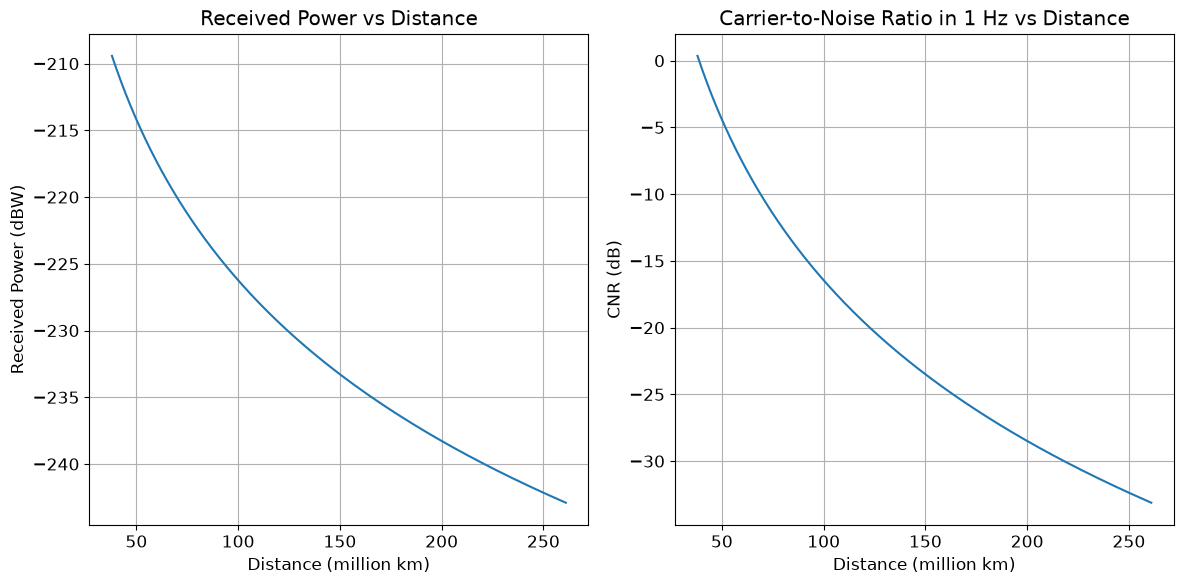

In [7]:
# Create distance array for plotting
distances = np.linspace(min_distance_km, max_distance_km, 1000)
cnrs = []
rx_powers = []

for dist in distances:
    results = calculator.calculate_link_budget(dist)
    cnrs.append(results['cnr_db_1hz'])
    rx_powers.append(results['rx_power_dbw'])

# Cell 4: Create plots
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(distances/1e6, rx_powers)
plt.grid(True)
plt.xlabel('Distance (million km)')
plt.ylabel('Received Power (dBW)')
plt.title('Received Power vs Distance')

plt.subplot(1, 2, 2)
plt.plot(distances/1e6, cnrs)
plt.grid(True)
plt.xlabel('Distance (million km)')
plt.ylabel('CNR (dB)')
plt.title('Carrier-to-Noise Ratio in 1 Hz vs Distance')
plt.tight_layout()
plt.show()

## Pointing Error Analysis

Dish antennas have a narrow beamwidth, and pointing errors can significantly impact our link budget. This section models pointing errors to determine their impact on signal strength and to help us include appropriate loss values in our link budget calculations.

### Visualizations

We provide two visualizations in the link budget.

The first is a normalized visualization (error/beamwidth ratio). It provides a universal reference applicable to any dish size or frequency. It illustrates the fundamental relationship between pointing error and beamwidth. It demonstrates key principles: 1dB loss occurs at error = beamwidth/3.46, 3dB loss at error = beamwidth/2. It facilitates comparisons across different systems.

The second is an absolute visualization (error in degrees). It shows practical values specific to (for example) the DSES dish at 18.29m dish at 1296 MHz. It provides exact specifications for pointing requirements. It displays precisely how many degrees of error are acceptable for given loss levels. It is directly applicable to a specific system's operational planning.

The notebook user can toggle between these visualizations using the show_normalized parameter (True/False).

The calculations are based on established antenna theory. First, there is a beamwidth calculation. It uses the formula beamwidth = 1.22 * lambda/D for circular apertures.
lambda is wavelength in meters and D is dish diameter in meters. The result is the 3dB beamwidth (where power drops to half).

Pointing Loss Formula:
pointing_loss = -12 * (error_angle / beamwidth)²
This quadratic relationship means losses increase rapidly as pointing error grows.

### Critical Error Thresholds
Working backwards from the formula above we get the following:
For 1dB loss: error = beamwidth/√12 ≈ beamwidth/3.46
For 3dB loss: error = beamwidth/2

For example, with a beamwidth of 0.6°:
Maximum error for 1dB loss: 0.173° (0.6°/3.46)
Maximum error for 3dB loss: 0.3° (0.6°/2)

The current system's pointing error (for example, 0.01°) is displayed on the graph as a purple dot, showing its position relative to these critical thresholds. This is a reasonable engineering guideline for minimizing losses, though it's more conservative than the 1dB loss threshold.



For a 25.0m dish at 1299.5 MHz:
3dB Beamwidth: 0.645 degrees
Maximum pointing error for 1dB loss: 0.186 degrees
Maximum pointing error for 3dB loss: 0.323 degrees
Current system pointing error: 0.010 degrees
Current pointing loss: -0.00 dB
For a 25.0m dish at 1299.5 MHz:
3dB Beamwidth: 0.645 degrees
Maximum pointing error for 1dB loss: 0.186 degrees
Maximum pointing error for 3dB loss: 0.323 degrees
Current system pointing error: 0.010 degrees
Current pointing loss: -0.00 dB


(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Pointing Loss vs Error for 25.0m Dish at 1299.5 MHz'}, xlabel='Pointing Error (degrees)', ylabel='Pointing Loss (dB)'>)

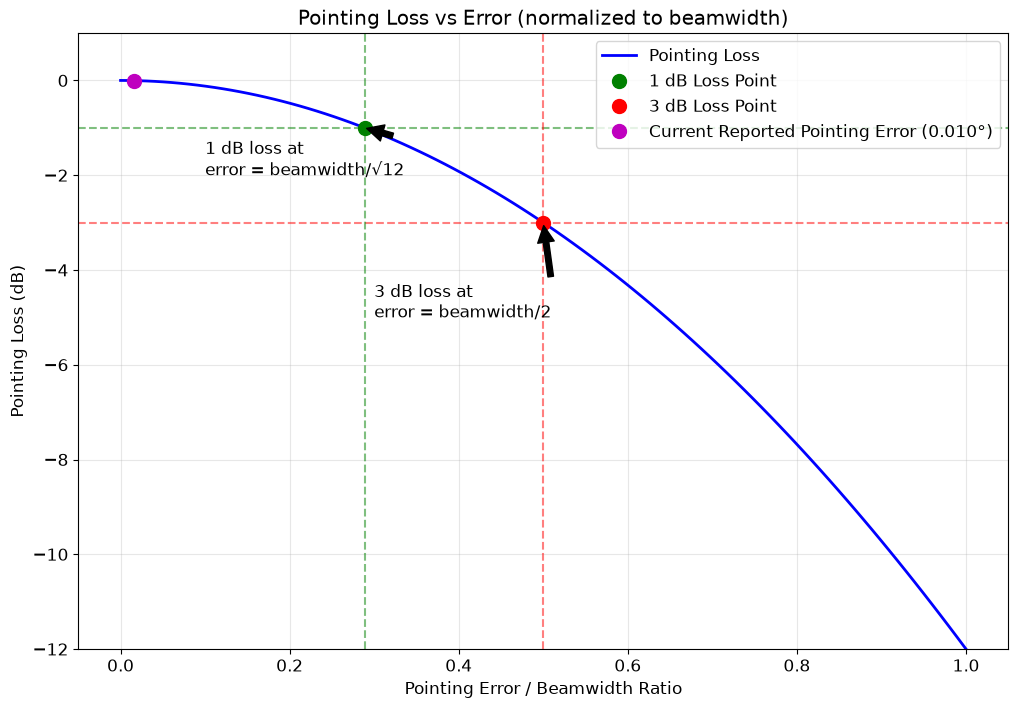

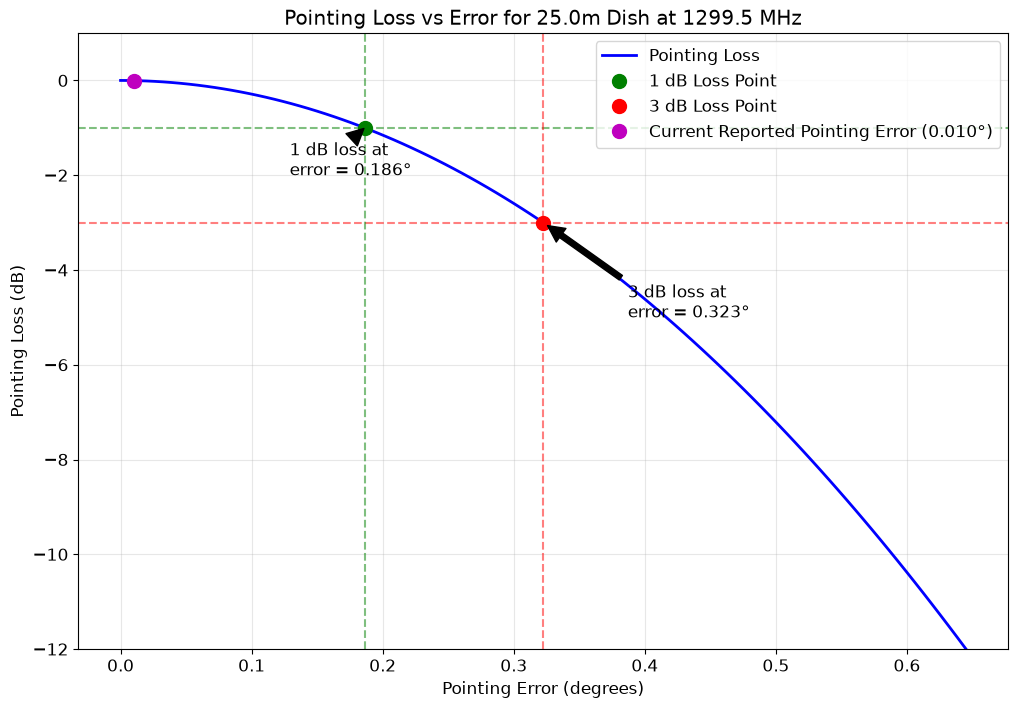

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

class AntennaPointingAnalysis:
    def __init__(self, params: SiteLinkParameters):
        self.params = params
        
    def wavelength(self) -> float:
        """Calculate wavelength in meters from frequency in MHz"""
        frequency_hz = self.params.tx_frequency_mhz * 1e6  # Convert MHz to Hz
        return self.params.c / frequency_hz
    
    def beamwidth_deg(self) -> float:
        """Calculate 3dB beamwidth in degrees"""
        # Using 1.22 λ/D formula for circular aperture
        return np.degrees(1.22 * self.wavelength() / self.params.tx_antenna_diameter_m)
    
    def calculate_pointing_loss(self, error_angle, beamwidth):
        """Calculate pointing loss in dB given error angle and beamwidth (both in same units)"""
        return -12 * (error_angle / beamwidth)**2
    
    def pointing_loss_analysis(self, max_error_fraction=1.0):
        """Generate pointing loss analysis with normalized and absolute error values"""
        # Get beamwidth
        beamwidth = self.beamwidth_deg()
        
        # Create normalized error fractions (as portion of beamwidth)
        error_fractions = np.linspace(0, max_error_fraction, 100)
        
        # Calculate absolute error values in degrees
        error_degrees = error_fractions * beamwidth
        
        # Calculate losses for the normalized curve
        losses = self.calculate_pointing_loss(error_fractions, 1)
        
        # Calculate key reference points
        # CORRECTION: Changed 5.66 to 3.46 (√12 ≈ 3.46)
        loss_at_sqrt12 = self.calculate_pointing_loss(1/np.sqrt(12), 1)  # ~1 dB
        loss_at_half = self.calculate_pointing_loss(1/2, 1)    # ~3 dB
        
        # Current system pointing error and its loss
        current_error = self.params.pointing_error_deg
        current_error_fraction = current_error / beamwidth
        current_loss = self.calculate_pointing_loss(current_error, beamwidth)
        
        # Summary information
        summary = {
            'beamwidth': beamwidth,
            # CORRECTION: Changed 5.66 to np.sqrt(12) for accuracy
            'error_for_1db_loss': beamwidth/np.sqrt(12),
            'error_for_3db_loss': beamwidth/2,
            'loss_at_sqrt12': loss_at_sqrt12,
            'loss_at_half': loss_at_half,
            'error_fractions': error_fractions,
            'error_degrees': error_degrees,
            'losses': losses,
            'current_error': current_error,
            'current_error_fraction': current_error_fraction,
            'current_loss': current_loss
        }
        
        return summary
    
    def plot_pointing_loss(self, show_normalized=True):
        """Create comprehensive pointing loss visualization"""
        # Get analysis data
        data = self.pointing_loss_analysis(max_error_fraction=1.0)
        
        # Create figure
        fig, ax = plt.subplots(figsize=(12, 8))
        
        if show_normalized:
            # Plot normalized curve (error as fraction of beamwidth)
            ax.plot(data['error_fractions'], data['losses'], 'b-', linewidth=2, label='Pointing Loss')
            
            # CORRECTION: Changed 5.66 to np.sqrt(12) for accuracy
            sqrt12_value = 1/np.sqrt(12)
            # Add markers for specific loss points
            ax.plot(sqrt12_value, data['loss_at_sqrt12'], 'go', markersize=10, label='1 dB Loss Point')
            ax.plot(1/2, data['loss_at_half'], 'ro', markersize=10, label='3 dB Loss Point')
            
            # Add point for current system pointing error
            ax.plot(data['current_error_fraction'], data['current_loss'], 'mo', 
                    markersize=10, label='Current Reported Pointing Error (%.3f°)' % data['current_error'])
            
            # Add horizontal and vertical reference lines
            ax.axhline(y=data['loss_at_sqrt12'], color='g', linestyle='--', alpha=0.5)
            ax.axhline(y=data['loss_at_half'], color='r', linestyle='--', alpha=0.5)
            ax.axvline(x=sqrt12_value, color='g', linestyle='--', alpha=0.5)
            ax.axvline(x=1/2, color='r', linestyle='--', alpha=0.5)
            
            # Add annotations
            # CORRECTION: Updated annotation text to use correct formula
            ax.annotate('1 dB loss at\nerror = beamwidth/√12', 
                        xy=(sqrt12_value, data['loss_at_sqrt12']), xytext=(0.1, -2),
                        arrowprops=dict(facecolor='black', shrink=0.05))
            ax.annotate('3 dB loss at\nerror = beamwidth/2', 
                        xy=(1/2, data['loss_at_half']), xytext=(0.3, -5),
                        arrowprops=dict(facecolor='black', shrink=0.05))
            
            # Set axis labels
            ax.set_xlabel('Pointing Error / Beamwidth Ratio')
            title = 'Pointing Loss vs Error (normalized to beamwidth)'
        else:
            # Plot absolute curve (error in degrees)
            ax.plot(data['error_degrees'], data['losses'], 'b-', linewidth=2, label='Pointing Loss')
            
            # Add markers for specific loss points
            ax.plot(data['error_for_1db_loss'], data['loss_at_sqrt12'], 'go', markersize=10, label='1 dB Loss Point')
            ax.plot(data['error_for_3db_loss'], data['loss_at_half'], 'ro', markersize=10, label='3 dB Loss Point')
            
            # Add point for current system pointing error
            ax.plot(data['current_error'], data['current_loss'], 'mo', 
                    markersize=10, label='Current Reported Pointing Error (%.3f°)' % data['current_error'])
            
            # Add horizontal and vertical reference lines
            ax.axhline(y=data['loss_at_sqrt12'], color='g', linestyle='--', alpha=0.5)
            ax.axhline(y=data['loss_at_half'], color='r', linestyle='--', alpha=0.5)
            ax.axvline(x=data['error_for_1db_loss'], color='g', linestyle='--', alpha=0.5)
            ax.axvline(x=data['error_for_3db_loss'], color='r', linestyle='--', alpha=0.5)
            
            # Add annotations
            ax.annotate(f'1 dB loss at\nerror = {data["error_for_1db_loss"]:.3f}°', 
                        xy=(data['error_for_1db_loss'], data['loss_at_sqrt12']), 
                        xytext=(data['beamwidth']*0.2, -2),
                        arrowprops=dict(facecolor='black', shrink=0.05))
            ax.annotate(f'3 dB loss at\nerror = {data["error_for_3db_loss"]:.3f}°', 
                        xy=(data['error_for_3db_loss'], data['loss_at_half']), 
                        xytext=(data['beamwidth']*0.6, -5),
                        arrowprops=dict(facecolor='black', shrink=0.05))
            
            # Set axis labels
            ax.set_xlabel('Pointing Error (degrees)')
            title = f'Pointing Loss vs Error for {self.params.tx_antenna_diameter_m:.1f}m Dish at {self.params.tx_frequency_mhz:.1f} MHz'
        

        # Get current loss value to adjust y-limits if needed
        current_loss = data['current_loss']
        
        # Calculate appropriate y-limits
        # Start with default range
        y_min = -12
        y_max = 0.5  # Give a bit more space at the top
        
        # Adjust if current loss is very close to zero
        if current_loss > -0.5:
            y_max = 1  # Give even more space at the top
            
        # Common formatting
        ax.set_ylabel('Pointing Loss (dB)')
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(y_min, y_max)  # Use the calculated limits
        ax.legend()


        # Print summary information
        print(f"For a {self.params.tx_antenna_diameter_m:.1f}m dish at {self.params.tx_frequency_mhz:.1f} MHz:")
        print(f"3dB Beamwidth: {data['beamwidth']:.3f} degrees")
        print(f"Maximum pointing error for 1dB loss: {data['error_for_1db_loss']:.3f} degrees") 
        print(f"Maximum pointing error for 3dB loss: {data['error_for_3db_loss']:.3f} degrees")
        print(f"Current system pointing error: {data['current_error']:.3f} degrees")
        print(f"Current pointing loss: {data['current_loss']:.2f} dB")
        
        return fig, ax

# Set up the calculator
params = SiteLinkParameters()
analyzer = AntennaPointingAnalysis(params)
# 
# # Show normalized plot (relative to beamwidth)
analyzer.plot_pointing_loss(show_normalized=True)
# 
# # Show absolute plot (in degrees)
analyzer.plot_pointing_loss(show_normalized=False)

## How much Doppler do we Have?

How much Doppler do we have to deal with? This section calculates Doppler shift and the rate of change of the Doppler shift, and visualizes the results. 

We will have to anticipate and "track out" Doppler shift in order to find our signal in the frequency domain. We need to understand and account for the rate of change of this Doppler shift as well. A third factor is Doppler spread, which is what happens when a signal bounces off a rotating reflector. The DopplerCalculator class calculates Doppler shifts at particular times from particular positions. It calculates worst case Doppler shifts and worst case rate of change of Doppler. 

Doppler shift is lowest at inferior conjunction with Earth. This is when Venus is closest to us. Doppler shift briefly passes through zero Hz. At this point in the orbit, however, the rate of change of Doppler shift is the highest. The visualizations in this section show what this looks like. In the example usage, we first calculate Doppler values as if we at the center of the Earth. Why do this? Because we can show what is going on as if we were able to hold still from a non-rotating point of view. After that, we use our location specific methods. We are now on the surface of the Earth. We have our particular radio site from the SiteLinkParameters. We set up two more sites for comparison and to show how to change location. Adding in the rotation of the earth changes our Doppler situation and the visibility of Venus. 

Doppler spread and Doppler spread penalty calculations have their own calculator and methods. 


-------------------------------------------------------------
From Center-of-the-Earth Doppler calculations
-------------------------------------------------------------
Calculating Doppler for current time: 2026-09-19 18:26:34.309840+00:00
Current Earth-Venus:
  Relative velocity: -11699.91 m/s
  Doppler shift: 101430.37 Hz
  Received frequency: 1299.601430 MHz

Doppler shift rate of change (next 24 hours):
  Rate: -50.46 Hz/hour or -0.0140 Hz/second
  Starting Doppler: 101430.37 Hz
  Ending Doppler: 100219.29 Hz
  Total change: -1211.08 Hz

Calculating worst-case Doppler scenarios for a complete orbit cycle...
Worst-case Doppler shift:
  Maximum (positive) shift: 115998.12 Hz on 2028-03-31 18:26:34.317212+00:00
  Minimum (negative) shift: -114100.69 Hz on 2027-01-03 12:26:34.317212+00:00
  Total Doppler range: 230098.82 Hz

Worst-case Doppler rate of change:
  Maximum rate: -184.68 Hz/hour or -0.051299 Hz/second
  Occurs on: 2026-10-25 00:26:34.317212+00:00

Generating center-of-Ear

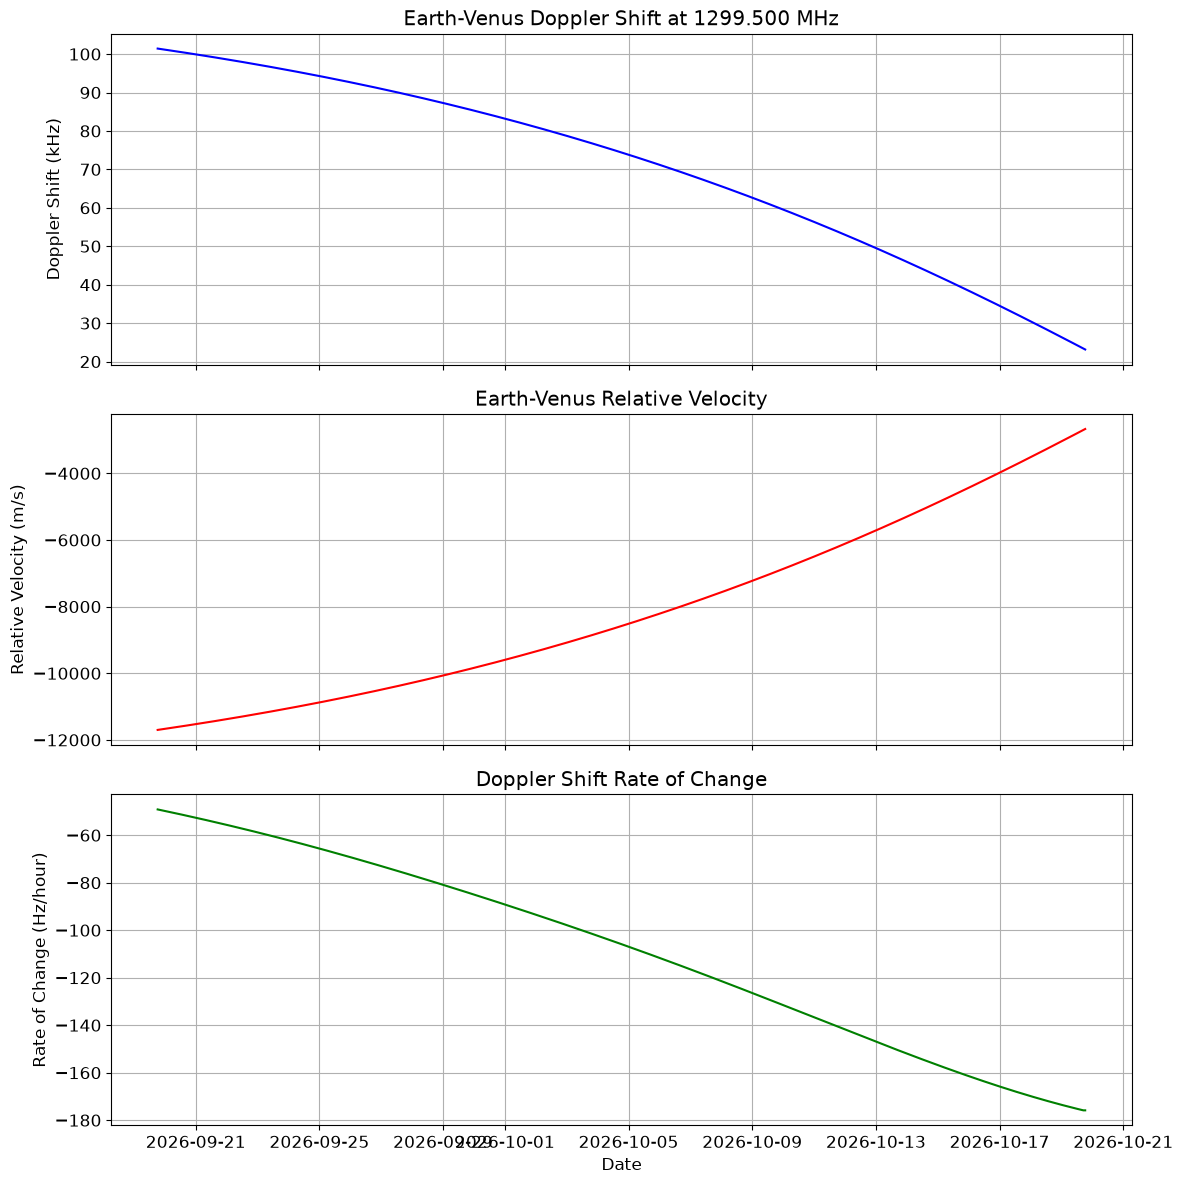


-------------------------------------------------------------
Earth location-specific Doppler calculations
-------------------------------------------------------------

Setting location to Our Radio (52.81213723180477°, 6.396346463227839°)
Current Earth-Venus from Our Radio:
  Venus altitude: -3.89° / azimuth: 243.66°
  Relative velocity: -11448.43 m/s
  Doppler shift: 99250.21 Hz
  Received frequency: 1299.599250 MHz
  Venus is not visible (assuming min altitude of 10°)

  Calculating worst-case scenarios for Our Radio over next 30 days...
  Maximum visible altitude: 18.17° on 2026-09-20 13:52:59.604651+00:00
  Venus visibility: 17.4% of time
  Maximum Doppler shift: 102098.47 Hz
  Minimum Doppler shift: 22489.64 Hz
  Maximum rate of change: -780.57 Hz/hour or -0.216824 Hz/second


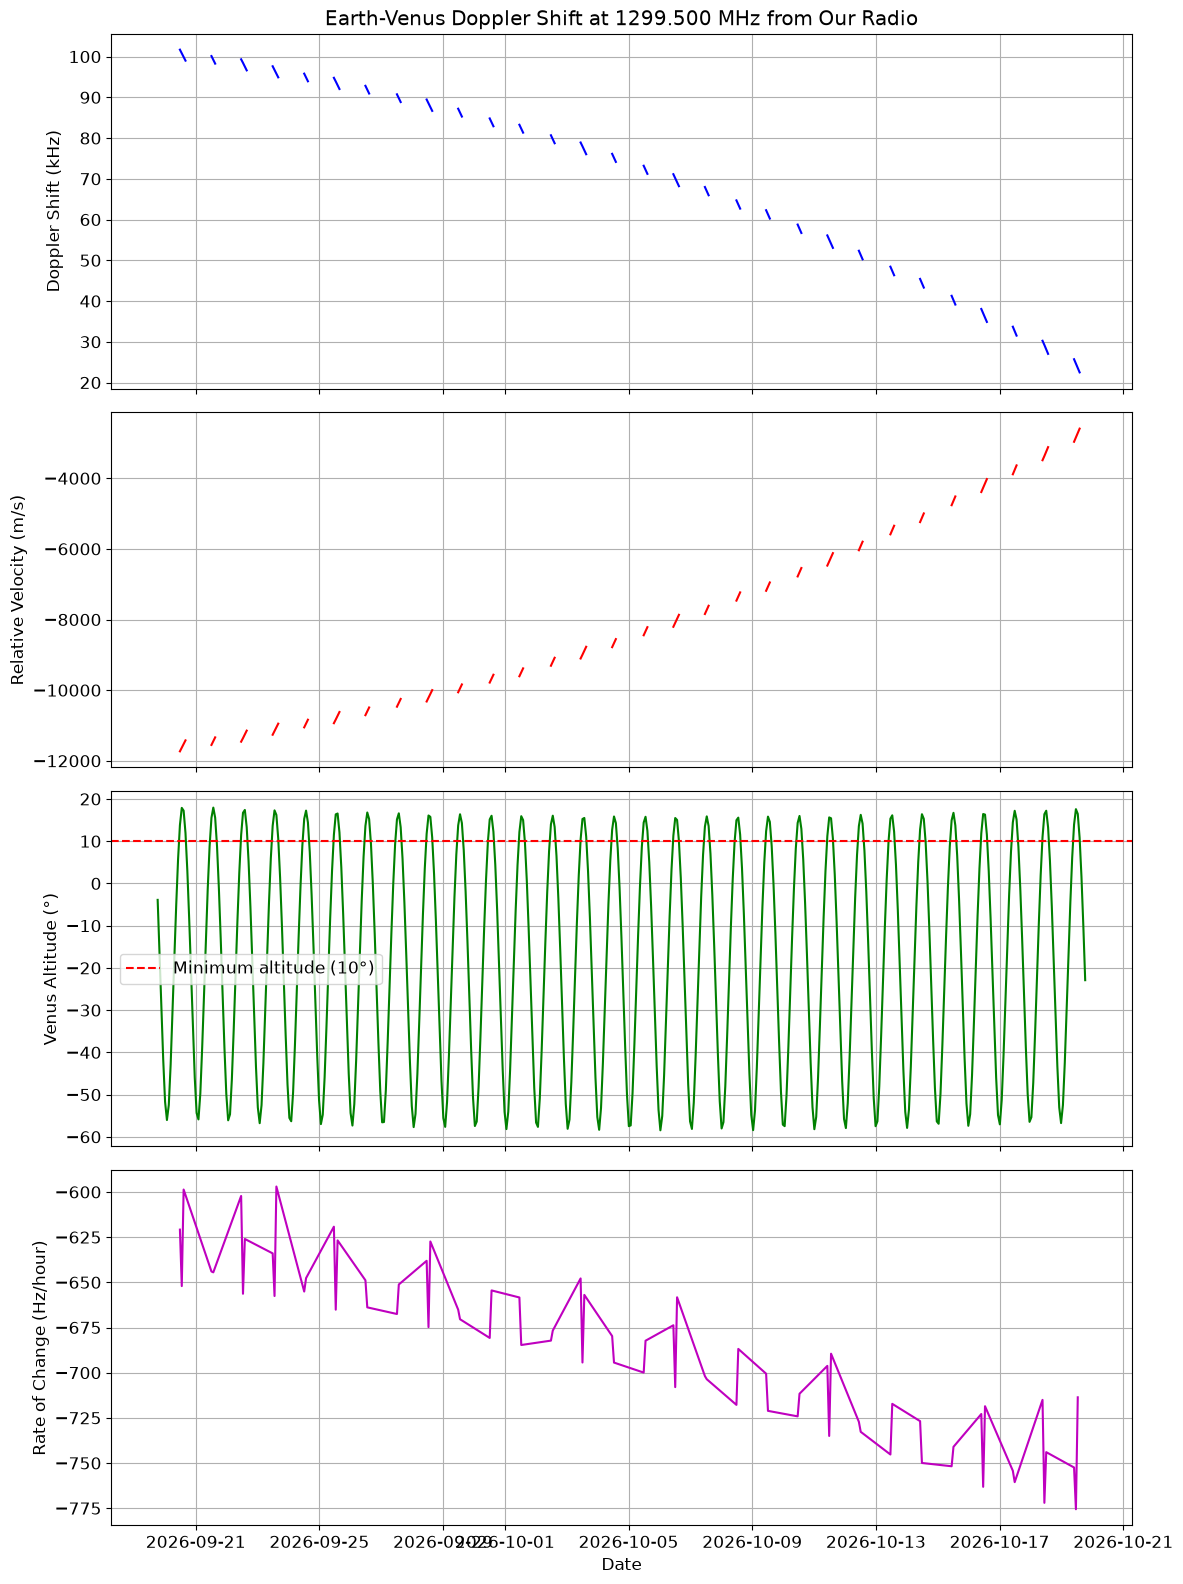


Setting location to London (51.5074°, -0.1278°)
Current Earth-Venus from London:
  Venus altitude: 0.24° / azimuth: 238.54°
  Relative velocity: -11452.90 m/s
  Doppler shift: 99288.94 Hz
  Received frequency: 1299.599289 MHz
  Venus is not visible (assuming min altitude of 10°)

  Calculating worst-case scenarios for London over next 30 days...
  Maximum visible altitude: 19.44° on 2026-09-20 13:53:00.803480+00:00
  Venus visibility: 19.2% of time
  Maximum Doppler shift: 101966.03 Hz
  Minimum Doppler shift: 22183.55 Hz
  Maximum rate of change: -797.18 Hz/hour or -0.221438 Hz/second


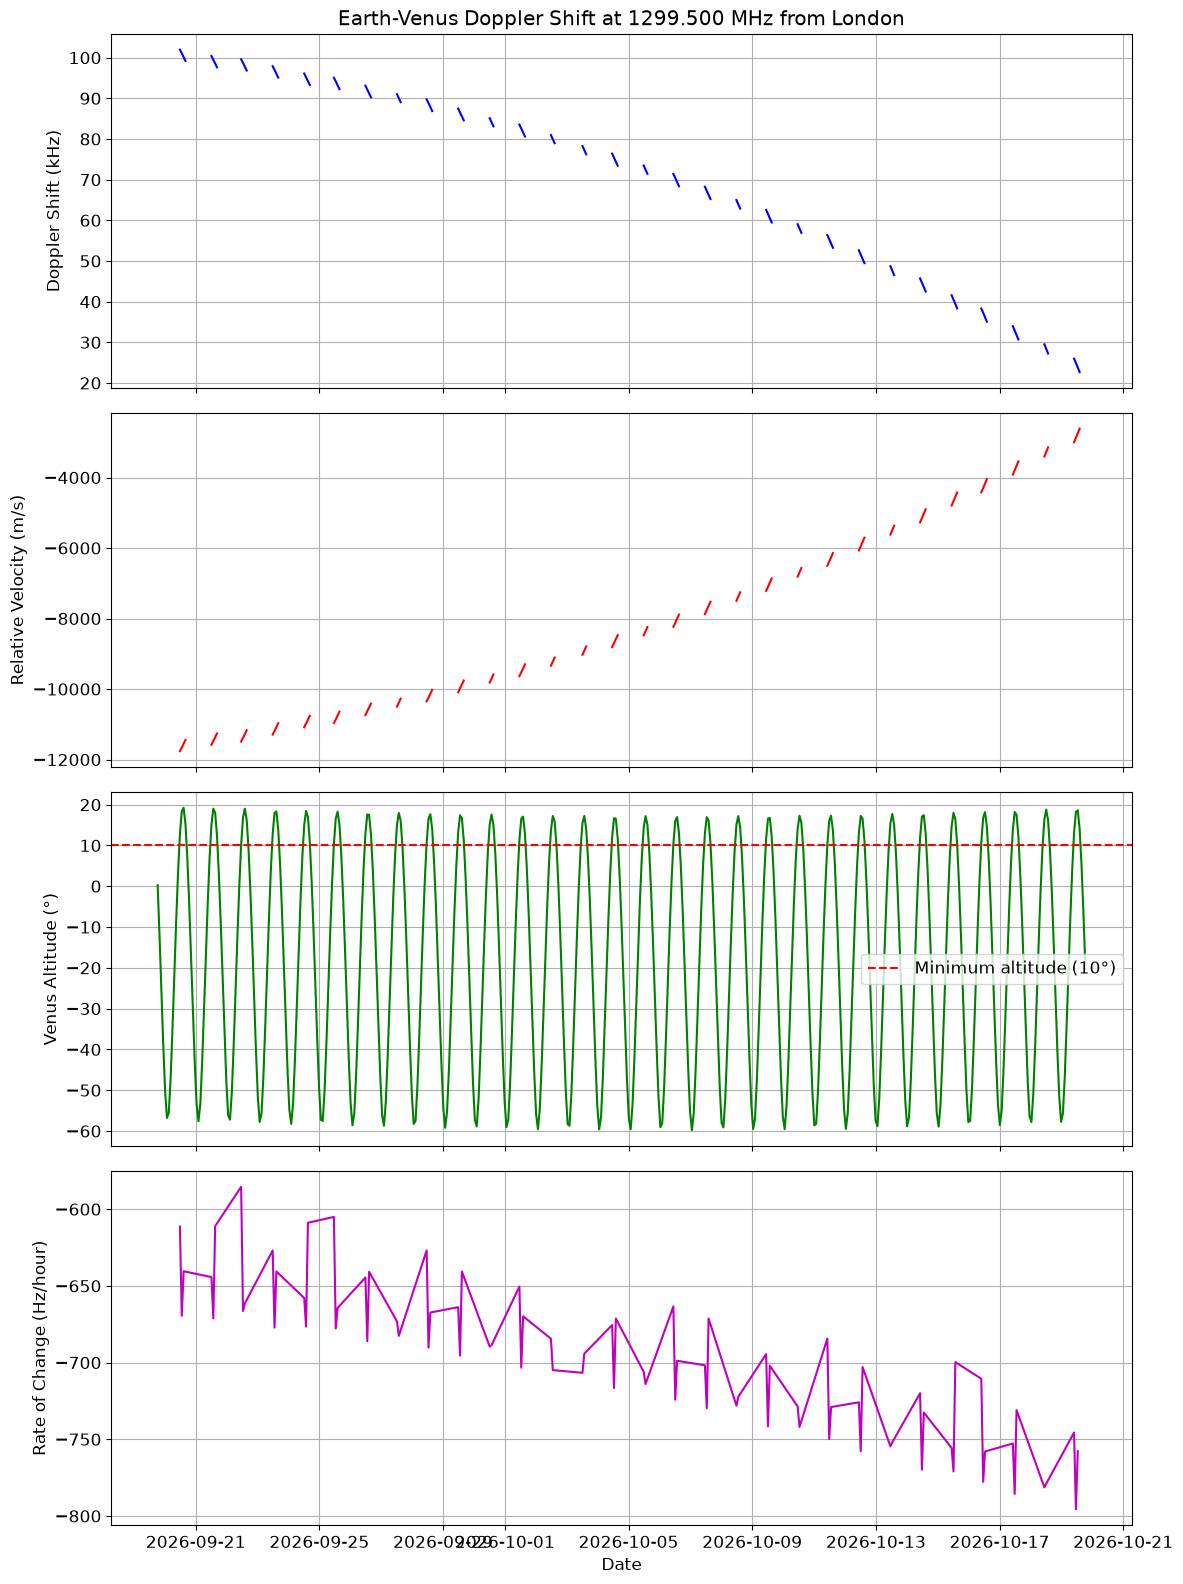


Setting location to Sidney (-33.8688°, 151.2093°)
Current Earth-Venus from Sidney:
  Venus altitude: -27.40° / azimuth: 141.63°
  Relative velocity: -11913.44 m/s
  Doppler shift: 103281.54 Hz
  Received frequency: 1299.603282 MHz
  Venus is not visible (assuming min altitude of 10°)

  Calculating worst-case scenarios for Sidney over next 30 days...
  Maximum visible altitude: 77.37° on 2026-10-08 03:05:01.987764+00:00
  Venus visibility: 47.8% of time
  Maximum Doppler shift: 104427.49 Hz
  Minimum Doppler shift: 21875.73 Hz
  Maximum rate of change: -1002.61 Hz/hour or -0.278504 Hz/second


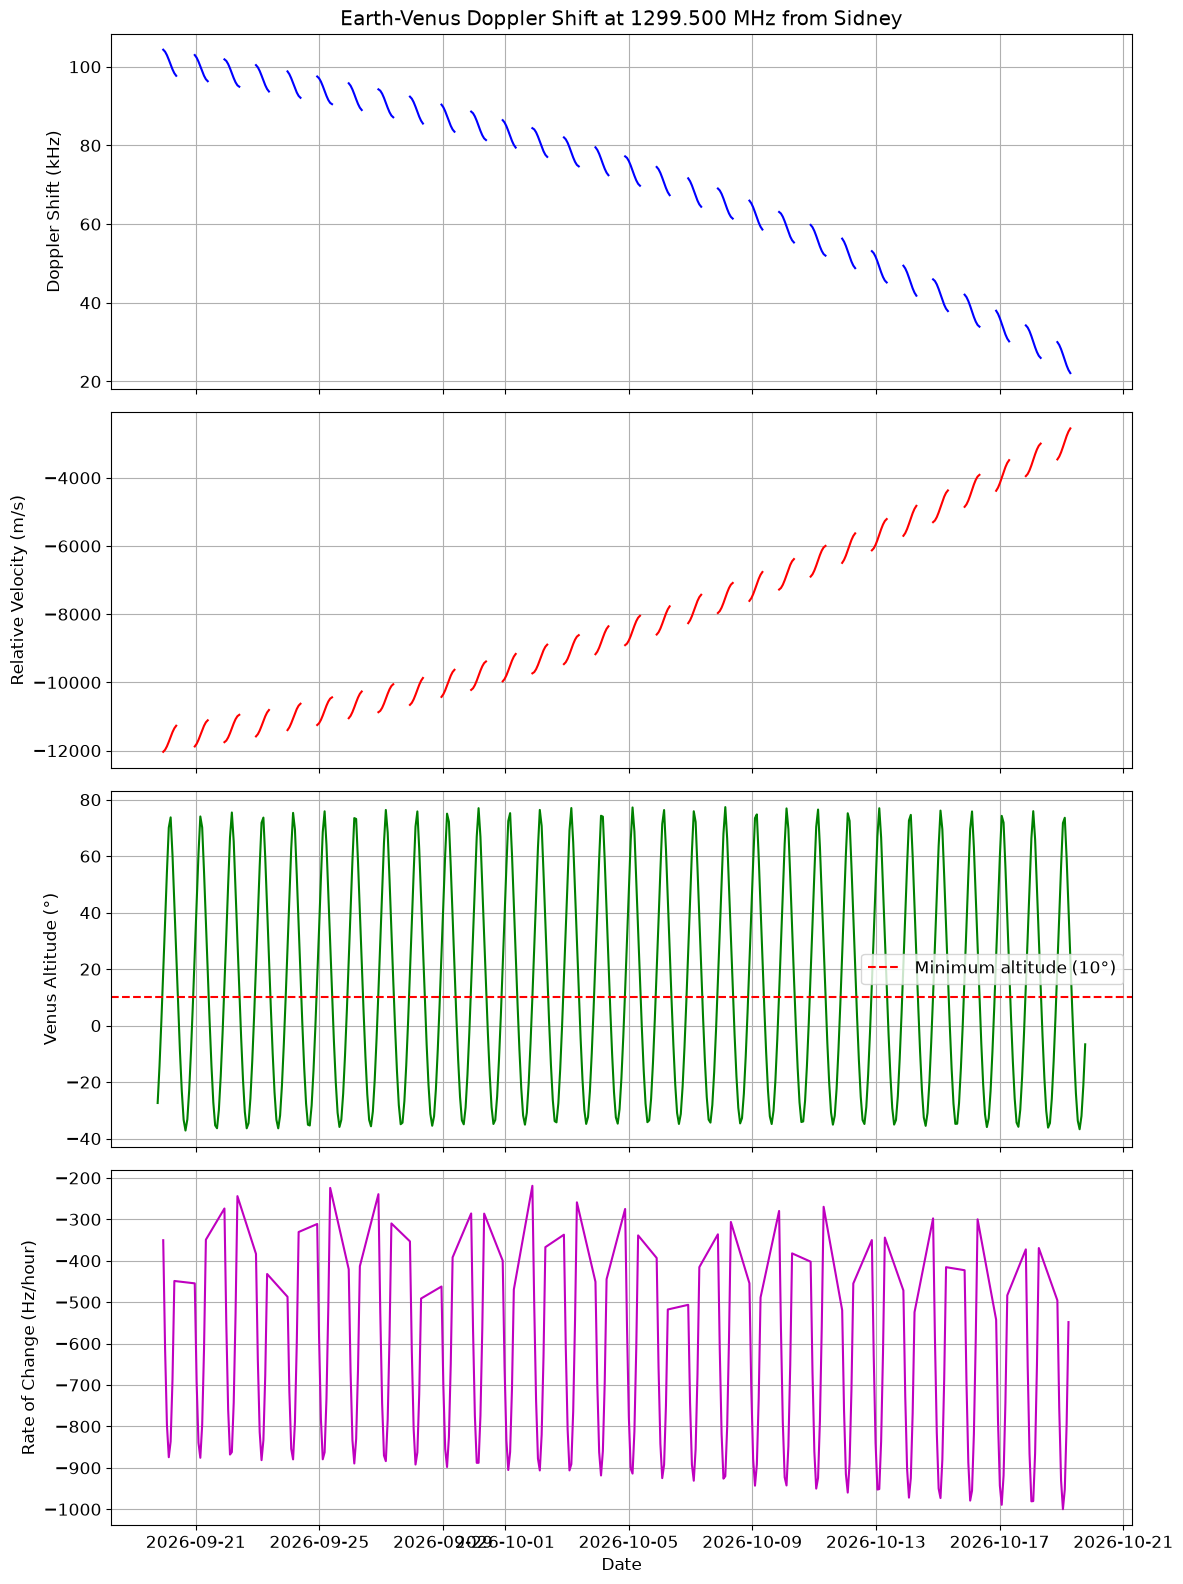

In [9]:
#import numpy as np
#from skyfield.api import load, wgs84
#from datetime import datetime, timedelta, timezone
#import matplotlib.pyplot as plt

class DopplerCalculator:
    """
    A class to calculate Doppler shifts between Earth and Venus.
    
    This class uses the Skyfield library to obtain planetary ephemeris data
    from publicly available sources and calculate the relative velocity and
    resulting Doppler shift and shift rate for radio communications.
    """
    
    def __init__(self, params: SiteLinkParameters):
        self.params = params
        """
        Initialize the Doppler calculator with one of our site-specific dataclasses.
        
        Parameters:
        -----------
        tx_frequency_mhz : float from <site>LinkParameters
            The transmission frequency in MHz (eg. 1296.0 MHz)
        """

        # Convert MHz to Hz for calculations
        self.frequency_hz = self.params.tx_frequency_mhz * 1e6

        # Time span of visualizations in days
        self.duration = 584      # 30 is useful as well
        
        # Load ephemeris data
        self.ephemeris = load('de421.bsp')
        self.earth = self.ephemeris['earth']
        self.venus = self.ephemeris['venus']
        
        # Time scale
        self.ts = load.timescale()
        
        # Observer location (initially None)
        self.has_observer = False
    
    def set_frequency(self, frequency_mhz):
        """
        Update the transmission frequency, outside of the dataclass.
        
        Parameters:
        -----------
        frequency_mhz : float
            The new transmission frequency in MHz
        """
        self.frequency_hz = frequency_mhz * 1e6
    
    def calculate_doppler(self, timestamp=None):
        """
        Calculate the Doppler shift at a specific time.
        
        Parameters:
        -----------
        timestamp : datetime, optional
            The time at which to calculate the Doppler shift (default: current time)
            If timezone-naive, UTC will be used
            
        Returns:
        --------
        tuple:
            - Frequency shift in Hz
            - Received frequency in Hz
            - Relative velocity in m/s (positive: moving apart, negative: moving closer)
        """
        if timestamp is None:
            # Make sure we use timezone-aware UTC time
            timestamp = datetime.now(timezone.utc)
        elif timestamp.tzinfo is None:
            # If the timestamp is naive (no timezone), assume it's in UTC
            timestamp = timestamp.replace(tzinfo=timezone.utc)
        
        # Convert to Skyfield time. This is called a "decomposed" approach
        t = self.ts.utc(timestamp.year, timestamp.month, timestamp.day,
                        timestamp.hour, timestamp.minute, timestamp.second + timestamp.microsecond/1000000.0)
        
        # Get the position and velocity vectors
        earth_pos = self.earth.at(t)
        venus_pos = self.venus.at(t)
        
        # Calculate relative position and velocity
        relative = earth_pos.observe(self.venus)
        distance = relative.distance().km
        relative_velocity = relative.velocity.km_per_s
        
        # The radial velocity component (positive means moving apart)
        radial_velocity = np.dot(relative_velocity, relative.position.km / distance)
        
        # Convert km/s to m/s
        radial_velocity_m_s = radial_velocity * 1000
        
        # Calculate Doppler shift
        # If objects are moving apart (positive velocity), frequency decreases
        # Factor of 2: EVE is a two-way radar path (Earth→Venus→Earth)
        doppler_shift = -2 * self.frequency_hz * radial_velocity_m_s / self.params.c
        received_frequency = self.frequency_hz + doppler_shift
        
        return doppler_shift, received_frequency, radial_velocity_m_s
    
    def calculate_doppler_rate(self, timestamp=None, delta_hours=24):
        """
        Calculate the rate of change of the Doppler shift over a specified time period.
        
        Parameters:
        -----------
        timestamp : datetime, optional
            The time at which to start the calculation (default: current time)
            If timezone-naive, UTC will be assumed
        delta_hours : float, optional
            The time period in hours over which to calculate the rate (default: 24 hours)
            
        Returns:
        --------
        tuple:
            - Rate of Doppler shift change in Hz/hour
            - Rate of Doppler shift change in Hz/second
            - Doppler shift at start time in Hz
            - Doppler shift at end time in Hz
        """
        if timestamp is None:
            timestamp = datetime.now(timezone.utc)
        elif timestamp.tzinfo is None:
            timestamp = timestamp.replace(tzinfo=timezone.utc)
        
        # Calculate Doppler shift at the start time
        doppler_start, _, _ = self.calculate_doppler(timestamp)
        
        # Calculate Doppler shift at the end time
        end_time = timestamp + timedelta(hours=delta_hours)
        doppler_end, _, _ = self.calculate_doppler(end_time)
        
        # Calculate the rate of change
        delta_doppler = doppler_end - doppler_start
        rate_per_hour = delta_doppler / delta_hours
        rate_per_second = rate_per_hour / 3600
        
        return rate_per_hour, rate_per_second, doppler_start, doppler_end
    
    def generate_doppler_curve(self, start_date, end_date, num_points=100):
        """
        Generate a curve of Doppler shift over a time period.
        
        Parameters:
        -----------
        start_date : datetime
            The starting date for the curve (if timezone-naive, UTC will be assumed)
        end_date : datetime
            The ending date for the curve (if timezone-naive, UTC will be assumed)
        num_points : int, optional
            Number of points to calculate (default: 100)
            
        Returns:
        --------
        tuple:
            - List of datetime objects
            - List of Doppler shifts in Hz
            - List of relative velocities in m/s
        """
        # Ensure both dates have timezone information
        if start_date.tzinfo is None:
            start_date = start_date.replace(tzinfo=timezone.utc)
        if end_date.tzinfo is None:
            end_date = end_date.replace(tzinfo=timezone.utc)
        
        time_delta = (end_date - start_date) / num_points
        
        times = []
        doppler_shifts = []
        velocities = []
        
        for i in range(num_points + 1):
            current_time = start_date + i * time_delta
            try:
                doppler_shift, _, velocity = self.calculate_doppler(current_time)
                
                times.append(current_time)
                doppler_shifts.append(doppler_shift)
                velocities.append(velocity)
            except Exception as e:
                print(f"Error calculating Doppler at time {current_time}: {e}")
                # Continue with the loop but skip this problematic point
                continue
        
        return times, doppler_shifts, velocities
    
    def calculate_worst_case_doppler(self, start_date=None, duration_days=584):
        """
        Calculate the worst-case Doppler shift and rate of change over a complete synodic period.
        
        The synodic period of Venus is approximately 584 days. 
        This is the time it takes for Earth and Venus to return 
        to the same relative positions - another inferior conjunction.
        
        Parameters:
        -----------
        start_date : datetime, optional
            The starting date for the analysis (default: current time)
        duration_days : int, optional
            The duration in days to analyze (default: 584, one synodic period)
            
        Returns:
        --------
        dict:
            Dictionary containing:
            - max_doppler_shift: Maximum absolute Doppler shift in Hz
            - min_doppler_shift: Minimum Doppler shift in Hz (most negative)
            - max_doppler_shift_date: Date of maximum Doppler shift
            - min_doppler_shift_date: Date of minimum Doppler shift
            - max_rate: Maximum absolute rate of change in Hz/hour
            - max_rate_date: Date of maximum rate of change
            - max_rate_per_second: Maximum rate in Hz/second
            - total_doppler_range: Total range of Doppler shift in Hz
        """
        if start_date is None:
            start_date = datetime.now(timezone.utc)
        elif start_date.tzinfo is None:
            start_date = start_date.replace(tzinfo=timezone.utc)
        
        end_date = start_date + timedelta(days=duration_days)
        
        # Use enough points to get good resolution (at least one point per day)
        num_points = max(1000, duration_days * 4)
        
        times, shifts, velocities = self.generate_doppler_curve(start_date, end_date, num_points)
        
        # Calculate rates of change
        rates = []
        rate_times = []
        
        for i in range(len(shifts) - 1):
            delta_t = (times[i+1] - times[i]).total_seconds() / 3600  # in hours
            rate = (shifts[i+1] - shifts[i]) / delta_t  # Hz per hour
            rates.append(rate)
            rate_times.append(times[i])
        
        # Find extremes for Doppler shift
        max_shift_idx = np.argmax(shifts)
        min_shift_idx = np.argmin(shifts)
        max_shift = shifts[max_shift_idx]
        min_shift = shifts[min_shift_idx]
        max_shift_date = times[max_shift_idx]
        min_shift_date = times[min_shift_idx]
        
        # Find extreme for rate of change (maximum absolute value)
        abs_rates = np.abs(rates)
        max_rate_idx = np.argmax(abs_rates)
        max_rate = rates[max_rate_idx]
        max_rate_date = rate_times[max_rate_idx]
        max_rate_per_second = max_rate / 3600
        
        # Calculate total Doppler range
        total_doppler_range = max_shift - min_shift
        
        return {
            'max_doppler_shift': max_shift,
            'min_doppler_shift': min_shift,
            'max_doppler_shift_date': max_shift_date,
            'min_doppler_shift_date': min_shift_date,
            'max_rate': max_rate,
            'max_rate_date': max_rate_date,
            'max_rate_per_second': max_rate_per_second,
            'total_doppler_range': total_doppler_range
        }
    
    def plot_doppler_curve(self, start_date, end_date, num_points=100, save_path=None, include_rate=True):
        """
        Generate and plot a curve of Doppler shift over a time period.
        
        Parameters:
        -----------
        start_date : datetime
            The starting date for the curve
        end_date : datetime
            The ending date for the curve
        num_points : int, optional
            Number of points to calculate (default: 100)
        save_path : str, optional
            Path to save the plot (default: None, plot is displayed instead)
        include_rate : bool, optional
            Whether to include a subplot showing the rate of change (default: True)
        """
        times, shifts, velocities = self.generate_doppler_curve(start_date, end_date, num_points)
        
        # Calculate rate of change for each point except the last one
        rates = []
        for i in range(len(shifts) - 1):
            delta_t = (times[i+1] - times[i]).total_seconds() / 3600  # in hours
            rate = (shifts[i+1] - shifts[i]) / delta_t  # Hz per hour
            rates.append(rate)
        
        # Add a placeholder for the last point to keep the arrays the same length
        rates.append(rates[-1] if rates else 0)  
        
        # Determine the number of subplots
        n_plots = 3 if include_rate else 2
        
        fig, axes = plt.subplots(n_plots, 1, figsize=(12, 4*n_plots), sharex=True)
        
        # Plot Doppler shift
        axes[0].plot(times, [s/1000 for s in shifts], 'b-')
        axes[0].set_ylabel('Doppler Shift (kHz)')
        axes[0].set_title(f'Earth-Venus Doppler Shift at {self.frequency_hz/1e6:.3f} MHz')
        axes[0].grid(True)
        
        # Plot velocity
        axes[1].plot(times, velocities, 'r-')
        axes[1].set_ylabel('Relative Velocity (m/s)')
        axes[1].set_title('Earth-Venus Relative Velocity')
        axes[1].grid(True)
        
        # Plot rate of change if requested
        if include_rate:
            axes[2].plot(times, rates, 'g-')
            axes[2].set_xlabel('Date')
            axes[2].set_ylabel('Rate of Change (Hz/hour)')
            axes[2].set_title('Doppler Shift Rate of Change')
            axes[2].grid(True)
        else:
            axes[1].set_xlabel('Date')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path)
        else:
            plt.show()


    # fixed this with a lot of help - it wasn't updating past the first location
    def set_observer_location(self, latitude, longitude, elevation=0, location_name=None):
            """
            Set the Earth-based observer's location.
            
            Parameters:
            -----------
            latitude : float
                Observer's latitude in degrees (positive for north, negative for south)
            longitude : float
                Observer's longitude in degrees (positive for east, negative for west)
            elevation : float, optional
                Observer's elevation above sea level in meters (default: 0)
            location_name : str, optional
                Name of the location (e.g., 'Site 1', 'New York', etc.)
            """
            # Create a completely new observer_location object EVERY time
            self.observer_location = None  # Clear the old one first
            self.observer_location = wgs84.latlon(latitude, longitude, elevation_m=elevation)
            self.has_observer = True
            self.location_name = location_name if location_name else f"({latitude:.2f}°, {longitude:.2f}°)"
            
            # Force the location to be recreated the next time it's used
            if hasattr(self, '_location_object'):
                del self._location_object

    
    def calculate_doppler_from_location(self, timestamp=None):
        """
        Calculate the Doppler shift at a specific time from the observer's location.
        This includes the additional effect of Earth's rotation.
        
        Parameters:
        -----------
        timestamp : datetime, optional
            The time at which to calculate the Doppler shift (default: current time)
            If timezone-naive, UTC will be assumed
            
        Returns:
        --------
        tuple:
            - Frequency shift in Hz
            - Received frequency in Hz
            - Relative velocity in m/s
            - Venus altitude in degrees (for visibility determination)
            - Venus azimuth in degrees
        """
        if not self.has_observer:
            raise ValueError("Observer location not set. Use set_observer_location() first.")
        
        if timestamp is None:
            timestamp = datetime.now(timezone.utc)
        elif timestamp.tzinfo is None:
            timestamp = timestamp.replace(tzinfo=timezone.utc)
        
        # Convert to Skyfield time
        t = self.ts.utc(timestamp.year, timestamp.month, timestamp.day,
                        timestamp.hour, timestamp.minute, timestamp.second + timestamp.microsecond/1000000.0)
        
        # Create a Skyfield location object for the observer
        location = self.earth + self.observer_location
        
        # Get topocentric position (from observer's location)
        venus_apparent = location.at(t).observe(self.venus).apparent()
        
        # Get altitude and azimuth for visibility determination
        alt, az, distance = venus_apparent.altaz()
        
        # Get the velocity component
        relative_velocity = venus_apparent.velocity.km_per_s
        
        # The radial velocity component (positive means moving apart)
        radial_velocity = np.dot(relative_velocity, venus_apparent.position.km / venus_apparent.distance().km)
        
        # Convert km/s to m/s
        radial_velocity_m_s = radial_velocity * 1000

        # Calculate Doppler shift
        # Factor of 2: EVE is a two-way radar path (Earth→Venus→Earth)
        doppler_shift = -2 * self.frequency_hz * radial_velocity_m_s / self.params.c
        received_frequency = self.frequency_hz + doppler_shift
        
        return doppler_shift, received_frequency, radial_velocity_m_s, alt.degrees, az.degrees
    
    def is_visible_from_location(self, timestamp=None, min_altitude=10):
        """
        Determine if Venus is visible from the observer's location.
        
        Parameters:
        -----------
        timestamp : datetime, optional
            The time to check visibility (default: current time)
        min_altitude : float, optional
            Minimum altitude in degrees for visibility (default: 10)
            
        Returns:
        --------
        bool:
            True if Venus is above the minimum altitude, False otherwise
        """
        if not self.has_observer:
            raise ValueError("Observer location not set. Use set_observer_location() first.")
        
        _, _, _, altitude, _ = self.calculate_doppler_from_location(timestamp)
        return altitude > min_altitude
    
    def generate_location_doppler_curve(self, start_date, end_date, num_points=100, 
                                      include_visibility=True, min_altitude=10):
        """
        Generate a curve of Doppler shift from the observer's location over a time period.
        
        Parameters:
        -----------
        start_date, end_date : datetime
            The time range to generate the curve for
        num_points : int, optional
            Number of points to calculate (default: 100)
        include_visibility : bool, optional
            Whether to mask points where Venus is not visible (default: True)
        min_altitude : float, optional
            Minimum altitude in degrees for visibility (default: 10)
            
        Returns:
        --------
        tuple:
            - List of datetime objects
            - List of Doppler shifts in Hz
            - List of relative velocities in m/s
            - List of Venus altitudes in degrees
            - List of visibility flags
        """
        if not self.has_observer:
            raise ValueError("Observer location not set. Use set_observer_location() first.")
        
        # Ensure both dates have timezone information
        if start_date.tzinfo is None:
            start_date = start_date.replace(tzinfo=timezone.utc)
        if end_date.tzinfo is None:
            end_date = end_date.replace(tzinfo=timezone.utc)
        
        time_delta = (end_date - start_date) / num_points
        
        times = []
        doppler_shifts = []
        velocities = []
        altitudes = []
        visibilities = []
        
        for i in range(num_points + 1):
            current_time = start_date + i * time_delta
            try:
                doppler_shift, _, velocity, alt, _ = self.calculate_doppler_from_location(current_time)
                is_visible = alt > min_altitude
                
                times.append(current_time)
                doppler_shifts.append(doppler_shift)
                velocities.append(velocity)
                altitudes.append(alt)
                visibilities.append(is_visible)
            except Exception as e:
                print(f"Error calculating Doppler at time {current_time}: {e}")
                continue
        
        # If including visibility, mask points where Venus is not visible
        if include_visibility:
            masked_shifts = []
            masked_velocities = []
            for i in range(len(visibilities)):
                if not visibilities[i]:
                    # Set to None to create gaps in the plot
                    masked_shifts.append(None)
                    masked_velocities.append(None)
                else:
                    masked_shifts.append(doppler_shifts[i])
                    masked_velocities.append(velocities[i])
            doppler_shifts = masked_shifts
            velocities = masked_velocities
        
        return times, doppler_shifts, velocities, altitudes, visibilities
    
    def plot_location_doppler_curve(self, start_date, end_date, num_points=100, 
                                  save_path=None, include_visibility=True, min_altitude=10):
        """
        Generate and plot a curve of Doppler shift from the observer's location.
        
        Parameters:
        -----------
        start_date, end_date : datetime
            The time range to generate the curve for
        num_points : int, optional
            Number of points to calculate (default: 100)
        save_path : str, optional
            Path to save the plot (default: None, plot is displayed instead)
        include_visibility : bool, optional
            Whether to mask points where Venus is not visible (default: True)
        min_altitude : float, optional
            Minimum altitude in degrees for visibility (default: 10)
        """
        if not self.has_observer:
            raise ValueError("Observer location not set. Use set_observer_location() first.")
        
        times, shifts, velocities, altitudes, visibilities = \
            self.generate_location_doppler_curve(start_date, end_date, num_points, 
                                              include_visibility, min_altitude)
        
        # Calculate rates of change
        rates = []
        rate_times = []
        
        for i in range(len(shifts) - 1):
            # Skip None values (when Venus is not visible)
            if shifts[i] is None or shifts[i+1] is None:
                continue
                
            delta_t = (times[i+1] - times[i]).total_seconds() / 3600  # in hours
            rate = (shifts[i+1] - shifts[i]) / delta_t  # Hz per hour
            rates.append(rate)
            rate_times.append(times[i])
        
        # Create subplots: Doppler, Velocity, Altitude, Rate
        fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)
        
        # Plot Doppler shift
        axes[0].plot(times, [s/1000 if s is not None else None for s in shifts], 'b-')
        axes[0].set_ylabel('Doppler Shift (kHz)')
        axes[0].set_title(f'Earth-Venus Doppler Shift at {self.frequency_hz/1e6:.3f} MHz from {self.location_name}')
        axes[0].grid(True)
        
        # Plot velocity
        axes[1].plot(times, velocities, 'r-')
        axes[1].set_ylabel('Relative Velocity (m/s)')
        axes[1].grid(True)
        
        # Plot altitude
        axes[2].plot(times, altitudes, 'g-')
        axes[2].set_ylabel('Venus Altitude (°)')
        if include_visibility:
            axes[2].axhline(y=min_altitude, color='r', linestyle='--', 
                          label=f'Minimum altitude ({min_altitude}°)')
            axes[2].legend()
        axes[2].grid(True)
        
        # Plot rate of change
        if rate_times:  # Only if we have valid rate data
            axes[3].plot(rate_times, rates, 'm-')
            axes[3].set_xlabel('Date')
            axes[3].set_ylabel('Rate of Change (Hz/hour)')
            axes[3].grid(True)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path)
        else:
            plt.show()
    
    def calculate_location_worst_case_doppler(self, start_date=None, duration_days=30,
                                            include_visibility=True, min_altitude=10):
        """
        Calculate the worst-case Doppler shift and rate of change for a specific location.
        
        Parameters:
        -----------
        start_date : datetime, optional
            The starting date for the analysis (default: current time)
        duration_days : int, optional
            The duration in days to analyze (default: 30 days)
        include_visibility : bool, optional
            Whether to only consider times when Venus is visible (default: True)
        min_altitude : float, optional
            Minimum altitude in degrees for visibility (default: 10)
            
        Returns:
        --------
        dict:
            Dictionary containing worst-case metrics for the visible periods
        """
        if not self.has_observer:
            raise ValueError("Observer location not set. Use set_observer_location() first.")
        
        if start_date is None:
            start_date = datetime.now(timezone.utc)
        elif start_date.tzinfo is None:
            start_date = start_date.replace(tzinfo=timezone.utc)
        
        end_date = start_date + timedelta(days=duration_days)
        
        # Generate data with higher resolution
        num_points = max(1000, duration_days * 24)  # At least one point per hour
        times, shifts, velocities, altitudes, visibilities = \
            self.generate_location_doppler_curve(start_date, end_date, num_points, 
                                             include_visibility, min_altitude)
        
        # Calculate rates for valid points
        rates = []
        rate_times = []
        
        for i in range(len(shifts) - 1):
            if shifts[i] is None or shifts[i+1] is None:
                continue
                
            delta_t = (times[i+1] - times[i]).total_seconds() / 3600  # in hours
            rate = (shifts[i+1] - shifts[i]) / delta_t  # Hz per hour
            rates.append(rate)
            rate_times.append(times[i])
        
        # Filter out None values (when Venus is not visible)
        valid_shifts = [s for s in shifts if s is not None]
        
        if not valid_shifts:
            return {
                'no_visibility': True,
                'message': f"Venus is not visible above {min_altitude}° during the specified period"
            }
        
        # Find extremes for Doppler shift
        max_shift = max(valid_shifts)
        min_shift = min(valid_shifts)
        
        # Find times of extremes
        max_shift_idx = shifts.index(max_shift)
        min_shift_idx = shifts.index(min_shift)
        max_shift_date = times[max_shift_idx]
        min_shift_date = times[min_shift_idx]
        
        # Max altitude
        max_alt = max(altitudes)
        max_alt_idx = altitudes.index(max_alt)
        max_alt_date = times[max_alt_idx]
        
        # Find extreme for rate of change
        if rates:
            abs_rates = [abs(r) for r in rates]
            max_rate_idx = abs_rates.index(max(abs_rates))
            max_rate = rates[max_rate_idx]
            max_rate_date = rate_times[max_rate_idx]
            max_rate_per_second = max_rate / 3600
        else:
            max_rate = 0
            max_rate_date = None
            max_rate_per_second = 0
        
        # Calculate total Doppler range
        total_doppler_range = max_shift - min_shift
        
        # Calculate visibility statistics
        if include_visibility:
            visible_periods = []
            current_period = None
            
            for i, visible in enumerate(visibilities):
                if visible and current_period is None:
                    # Start of a new visibility period
                    current_period = {'start': times[i]}
                elif not visible and current_period is not None:
                    # End of a visibility period
                    current_period['end'] = times[i-1]
                    visible_periods.append(current_period)
                    current_period = None
            
            # Handle case where Venus is still visible at the end
            if current_period is not None:
                current_period['end'] = times[-1]
                visible_periods.append(current_period)
            
            # Calculate visibility statistics
            total_visible_hours = 0
            for period in visible_periods:
                duration = (period['end'] - period['start']).total_seconds() / 3600
                total_visible_hours += duration
            
            visibility_percentage = (total_visible_hours / (duration_days * 24)) * 100
        else:
            visible_periods = []
            visibility_percentage = 100  # Not considering visibility
        
        return {
            'max_doppler_shift': max_shift,
            'min_doppler_shift': min_shift,
            'max_doppler_shift_date': max_shift_date,
            'min_doppler_shift_date': min_shift_date,
            'max_rate': max_rate,
            'max_rate_date': max_rate_date,
            'max_rate_per_second': max_rate_per_second,
            'total_doppler_range': total_doppler_range,
            'max_altitude': max_alt,
            'max_altitude_date': max_alt_date,
            'visibility_percentage': visibility_percentage,
            'visible_periods': visible_periods,
            'no_visibility': False
        }



# Example usage

# Create a calculator using our transmit frequency from dataclass <site>LinkParameters
DopplerCalculator = DopplerCalculator(params)

# Example using From Center-of-the-Earth calculations
print("\n-------------------------------------------------------------")
print("From Center-of-the-Earth Doppler calculations")
print("-------------------------------------------------------------")
    
# Calculate current Doppler shift - explicitly using UTC time
current_time_utc = datetime.now(timezone.utc)
print(f"Calculating Doppler for current time: {current_time_utc}")
shift, freq, velocity = DopplerCalculator.calculate_doppler(current_time_utc)
print(f"Current Earth-Venus:")
print(f"  Relative velocity: {velocity:.2f} m/s")
print(f"  Doppler shift: {shift:.2f} Hz")
print(f"  Received frequency: {freq/1e6:.6f} MHz")

# Calculate the rate of change of Doppler shift over the next 24 hours
rate_hour, rate_sec, doppler_start, doppler_end = DopplerCalculator.calculate_doppler_rate(current_time_utc)
print(f"\nDoppler shift rate of change (next 24 hours):")
print(f"  Rate: {rate_hour:.2f} Hz/hour or {rate_sec:.4f} Hz/second")
print(f"  Starting Doppler: {doppler_start:.2f} Hz")
print(f"  Ending Doppler: {doppler_end:.2f} Hz")
print(f"  Total change: {doppler_end - doppler_start:.2f} Hz")

# Calculate worst-case Doppler scenarios
print(f"\nCalculating worst-case Doppler scenarios for a complete orbit cycle...")
worst_case = DopplerCalculator.calculate_worst_case_doppler()

print(f"Worst-case Doppler shift:")
print(f"  Maximum (positive) shift: {worst_case['max_doppler_shift']:.2f} Hz on {worst_case['max_doppler_shift_date']}")
print(f"  Minimum (negative) shift: {worst_case['min_doppler_shift']:.2f} Hz on {worst_case['min_doppler_shift_date']}")
print(f"  Total Doppler range: {worst_case['total_doppler_range']:.2f} Hz")

print(f"\nWorst-case Doppler rate of change:")
print(f"  Maximum rate: {worst_case['max_rate']:.2f} Hz/hour or {worst_case['max_rate_per_second']:.6f} Hz/second")
print(f"  Occurs on: {worst_case['max_rate_date']}")


# Generate a Doppler curve for the next 30 days - explicitly using UTC
start = datetime.now(timezone.utc)
end = start + timedelta(days=30)

print(f"\nGenerating center-of-Earth Doppler curve from {start} to {end}")
DopplerCalculator.plot_doppler_curve(start, end, num_points=500)



# Example using Earth location-specific calculations
print("\n-------------------------------------------------------------")
print("Earth location-specific Doppler calculations")
print("-------------------------------------------------------------")

# We can define a set of sites - first one is from our site-specific dataclass
sites = [
    {"name": "Our Radio", "latitude": params.latitude, "longitude": params.longitude, "elevation": params.elevation},  # from dataclass
    {"name": "London", "latitude": 51.5074, "longitude": -0.1278, "elevation": 25},    # London
    {"name": "Sidney", "latitude": -33.8688, "longitude": 151.2093, "elevation": 3}   # Sydney
]

# Test calculations for each site
for site in sites:
    print(f"\nSetting location to {site['name']} ({site['latitude']}°, {site['longitude']}°)")
    DopplerCalculator.set_observer_location(site['latitude'], site['longitude'], site['elevation'], location_name=site['name'])
    
    # Calculate current Doppler from this location
    try:
        doppler, freq, velocity, altitude, azimuth = DopplerCalculator.calculate_doppler_from_location(current_time_utc)
        print(f"Current Earth-Venus from {site['name']}:")
        print(f"  Venus altitude: {altitude:.2f}° / azimuth: {azimuth:.2f}°")
        print(f"  Relative velocity: {velocity:.2f} m/s")
        print(f"  Doppler shift: {doppler:.2f} Hz")
        print(f"  Received frequency: {freq/1e6:.6f} MHz")
        print(f"  Venus is {'visible' if altitude > 10 else 'not visible'} (assuming min altitude of 10°)")
        
        # Calculate worst case for this location over next 30 days
        print(f"\n  Calculating worst-case scenarios for {site['name']} over next 30 days...")
        location_worst_case = DopplerCalculator.calculate_location_worst_case_doppler()
        
        if location_worst_case.get('no_visibility', False):
            print(f"  {location_worst_case['message']}")
        else:
            print(f"  Maximum visible altitude: {location_worst_case['max_altitude']:.2f}° on {location_worst_case['max_altitude_date']}")
            print(f"  Venus visibility: {location_worst_case['visibility_percentage']:.1f}% of time")
            print(f"  Maximum Doppler shift: {location_worst_case['max_doppler_shift']:.2f} Hz")
            print(f"  Minimum Doppler shift: {location_worst_case['min_doppler_shift']:.2f} Hz")
            print(f"  Maximum rate of change: {location_worst_case['max_rate']:.2f} Hz/hour or {location_worst_case['max_rate_per_second']:.6f} Hz/second")

            
            # Uncomment to generate plots for each site
            DopplerCalculator.plot_location_doppler_curve(
                start_date=current_time_utc,
                end_date=current_time_utc + timedelta(days=30),
                num_points=500
            )
        
    except Exception as e:
        print(f"Error calculating for {site['name']}: {e}")



## Multi-Site Visibility Coordinator

Enter the dataclasses that correspond to the sites that you want to compare Venus visibility across. 

Simultaneous visibility windows (all sites above 10 degrees):
Start (UTC)                End (UTC)                  Duration
----------------------------------------------------------------------
  2026-10-15 10:04 UTC    2026-10-15 14:47 UTC    4.7 hours
  2026-10-16 09:36 UTC    2026-10-16 14:58 UTC    5.4 hours
  2026-10-17 09:47 UTC    2026-10-17 14:29 UTC    4.7 hours
  2026-10-18 09:18 UTC    2026-10-18 14:41 UTC    5.4 hours
  2026-10-19 09:30 UTC    2026-10-19 14:52 UTC    5.4 hours
  2026-10-20 09:01 UTC    2026-10-20 14:24 UTC    5.4 hours
  2026-10-21 09:12 UTC    2026-10-21 14:35 UTC    5.4 hours
  2026-10-22 08:44 UTC    2026-10-22 14:47 UTC    6.0 hours
  2026-10-23 08:55 UTC    2026-10-23 14:18 UTC    5.4 hours
  2026-10-24 08:26 UTC    2026-10-24 14:29 UTC    6.0 hours
  2026-10-25 08:38 UTC    2026-10-25 14:00 UTC    5.4 hours
  2026-10-26 08:09 UTC    2026-10-26 14:12 UTC    6.0 hours
  2026-10-27 08:21 UTC    2026-10-27 14:24 UTC    6.0 hours
  2026-10-28 07:52 UTC  

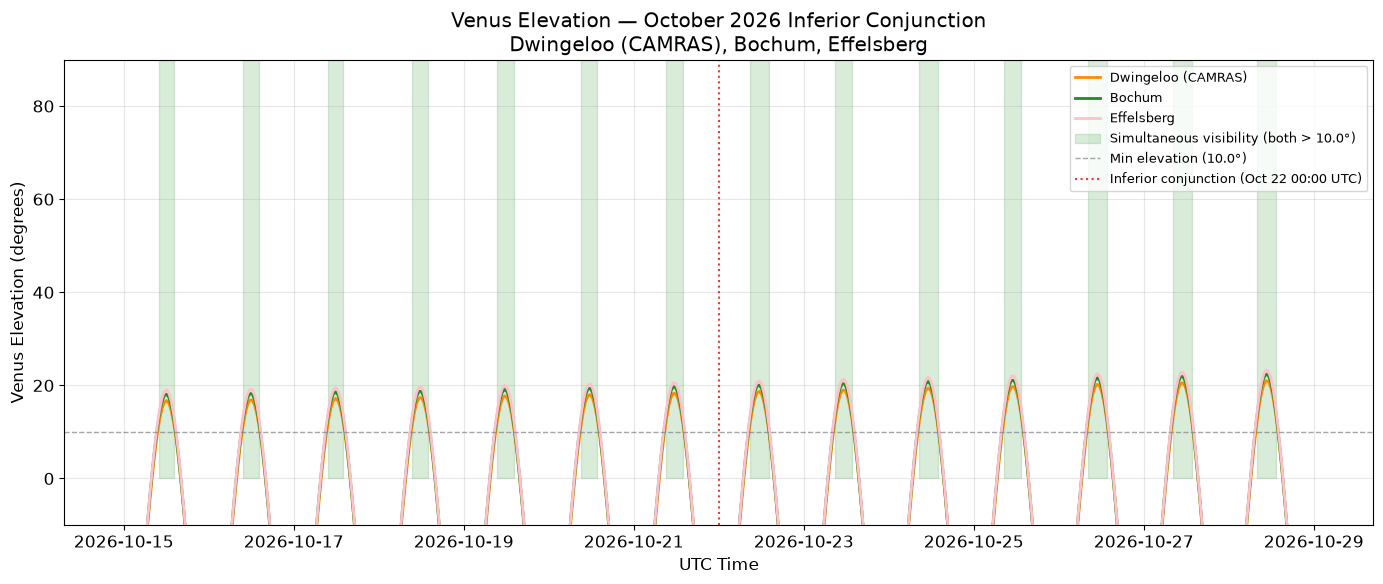

In [10]:
# Multi-site Venus elevation during October 2026 conjunction window
# Add or remove dataclasses from visibility_sites to change which stations are plotted

import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta, timezone

# Define stations to plot using existing dataclasses
# Format: (DataclassName, "Display Name", "color")
visibility_sites = [
    #(GBTLinkParameters,        "Green Bank (GBT)",   "steelblue"),
    (DwingelooLinkParameters,  "Dwingeloo (CAMRAS)", "darkorange"),
    #(DSESLinkParameters,       "DSES",               "purple"),
    (BochumLinkParameters,     "Bochum",             "forestgreen"),
    (EffelsbergLinkParameters, "Effelsberg",         "pink"),
]

# Time range: some number of hours +/- starting at conjunction
obs_date = datetime(2026, 10, 22, 0, 0, tzinfo=timezone.utc)
start = obs_date - timedelta(hours=(168))
end   = obs_date + timedelta(hours=(168))
num_points = 500
min_elevation = 10.0  # degrees

fig, ax = plt.subplots(figsize=(14, 6))

site_altitudes = {}
time_list = None

for dataclass, display_name, color in visibility_sites:
    site = dataclass()
    DopplerCalculator.set_observer_location(
        site.latitude, site.longitude,
        site.elevation,
        location_name=display_name
    )
    times, _, _, altitudes, _ = DopplerCalculator.generate_location_doppler_curve(
        start, end, num_points=num_points, include_visibility=False
    )
    site_altitudes[display_name] = np.array(altitudes)
    if time_list is None:
        time_list = times

    ax.plot(times, altitudes, color=color, linewidth=2, label=display_name)

# Shade overlap where all sites are above minimum elevation
overlap = np.ones(len(time_list), dtype=bool)
for alt_array in site_altitudes.values():
    overlap &= (alt_array >= min_elevation)

ax.fill_between(time_list, 0, 90,
                where=overlap, alpha=0.15, color='green',
                label=f'Simultaneous visibility (both > {min_elevation}°)')

ax.axhline(y=min_elevation, color='gray', linestyle='--',
           linewidth=1, alpha=0.7, label=f'Min elevation ({min_elevation}°)')

ax.axvline(x=obs_date, color='red', linestyle=':',
           linewidth=1.5, alpha=0.8, label='Inferior conjunction (Oct 22 00:00 UTC)')

ax.set_xlabel('UTC Time')
ax.set_ylabel('Venus Elevation (degrees)')
ax.set_title('Venus Elevation — October 2026 Inferior Conjunction\n'
             + ', '.join(name for _, name, _ in visibility_sites))
ax.set_ylim(-10, 90)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Print overlap windows
print("Simultaneous visibility windows (all sites above 10 degrees):")
print(f"{'Start (UTC)':<25}  {'End (UTC)':<25}  {'Duration'}")
print("-" * 70)

in_window = False
window_start = None
for t, ov in zip(time_list, overlap):
    if ov and not in_window:
        in_window = True
        window_start = t
    elif not ov and in_window:
        in_window = False
        hours = (t - window_start).total_seconds() / 3600
        print(f"  {window_start.strftime('%Y-%m-%d %H:%M UTC')}    "
              f"{t.strftime('%Y-%m-%d %H:%M UTC')}    "
              f"{hours:.1f} hours")
if in_window:
    hours = (time_list[-1] - window_start).total_seconds() / 3600
    print(f"  {window_start.strftime('%Y-%m-%d %H:%M UTC')}    "
          f"{time_list[-1].strftime('%Y-%m-%d %H:%M UTC')}    "
          f"{hours:.1f} hours")

plt.tight_layout()
plt.show()

## Doppler Spread for Venus

Doppler spread happens when our signal reflects off a rotating structure, like Venus. Part of Venus (the East limb, on the right side of Venus as viewed from Earth) is moving towards us. And, another part of Venus is moving away from us (the West limb, on the left side of Venus as viewed from Earth). The parts moving towards us cause reflected frequencies to increase. In the radar community, when a target is moving towards you, it produces a negative Doppler shift. The parts moving away from us cause reflected frequencies to decrease. In the radar community, when a target is moving away you, it produces a positive Doppler shift. The signal reflected off the center of the planet is reflected back with little to no frequency change. Doppler spread is a quantification of how muddled up our reflected signal becomes due to the rotation of the reflector. 

Gary K6MG writes "A rough calculation of venus limb-to-limb doppler spreading @ 1296MHz:  4 * venus rotation velocity 1.8 m/s / 3e8 m/s * 1.296e9 c/s = 31 c/s. This calculation is the same as K1JT uses for EME in Frequency-Dependent Characteristics of the EME Path and is motivated from first principles. One edge of venus is approaching the earth at a 1.8m/s velocity relative to the center of venus, the other edge is receding at the same velocity giving one factor of 2. The other factor of 2 is due to the reflection, the wave is shortened or lengthened on both the approach and the retreat."

You may be curious as to how the wave can be shortened or lengthened on both the approach and the retreat. 

## Understanding the Double Doppler Shift in Radar Returns
The double Doppler shift happens because radar involves a two-way journey of the radio wave. Earth transmits a radio wave at exactly 1296 MHz. This wave travels toward Venus. When the wave hits a moving point on Venus's surface (like the East or West limb), the wave's frequency as experienced by that point is different from what was transmitted. 

If the point is moving away from Earth, it "sees" a lower frequency (in other words, a redshift). If the point is moving toward Earth, it "sees" a higher frequency (in other words, a blueshift). The wave bounces off part of Venus's surface. The wave is now re-emitted at the shifted frequency that the moving point "sees" or experiences. So the reflected wave already has one Doppler shift applied. As this already-shifted wave travels back to Earth, a second Doppler shift occurs. This is because the reflecting point is still moving, so the wave gets compressed or stretched again. The wave returns to Earth with two Doppler shifts applied. Therefore, there is a factor of two in the equation explained by Gary K6MG.  

An example with real-world objects can help visualize what's going on. Imagine throwing a tennis ball at a person on a moving train, and the train is coming right at you. You throw the ball to the person on the train at 10 mph. To the person on the train, your 10 mph ball appears to be moving faster or slower depending on the train's direction. Since they are moving towards you, your 10 mph ball's speed is added to the train's 30 mph speed, and the ball would arrive at what felt like 40 mph. From their perspective, they received a 40 mph ball. Now they are just going to "reflect" the ball back at you at the same relative force as they received it. Now the ball is coming back to you at that 40 mph plus the velocity of the train, which is 30 mph. So you are going to be catching a 70 mph fast ball! When you receive the ball, its speed has been affected twice by the train's motion.

This works in the other direction as well. Now that the train is moving away from you, it's a lot harder to catch up to. So, you get a baseball pro, your friend Shohei Ohtani, to throw the ball for you. The train is moving away from you at 30 mph. Ohtani throws the ball at 100 mph. The person on the train catches it. It arrives at what feels like 70 mph to the person on the train. He tosses it back to Ohtani at 70 mph, because that's how fast it arrived, relative to him. The train takes another 30 mph off the velocity of the ball, and Ohtani easily catches a ball going 40 mph. 

The important insight about radar returns off of moving objects is that the reflection does not simply "bounce back" the original frequency. The moving reflector actually re-emits the signal at the Doppler-shifted frequency it receives, and then this already-shifted frequency undergoes a second Doppler shift on its return journey.

The calculation we made gives us the full extent of the Doppler Spread from Venus rotation, which for Venus is 31 Hz. 

However, when we model Doppler Spread, we need to go beyond using a uniform distribution out to 31 Hz. Most of the energy reflected back is coming from the points facing closest to us, where we see near 0 Hz spread. It tapers off from there, as we get less and less energy as we get further out on the limbs. A Gaussian distribution for this type of signal spread is a good start, but can be further refined based on radar surveys of Venus and results in papers such as _Backscattering from an Undulating Surface with Applications to Radar Returns from the Moon_, by T. Hagfors, data from Bochum's EVE attempt in 2009, where the spread was much less than 31 Hz on Venus approach, and most recently from Dr. Daniel Estevez analysis of CAMRAS data from the March 2025 event. 

## Comparing Theoretical Calculations with Observed Measurements

In our previous analysis, we calculated the expected Doppler spread for Venus using the approach described by Gary K6MG. 

Dr. Estevez's analysis at https://destevez.net/2025/04/analysis-of-the-camras-venus-radar-experiment/ shows that the measured Doppler spread from the CAMRAS (Dwingeloo) Venus radar experiment is much narrower than the theoretical calculation provided by Gary. This needs and deserves explanation. While Gary calculated a Doppler spread of about 31 Hz, Dr. Estevez's measured data shows most of the power is concentrated within approximately ±0.75 Hz. 
There are two primary factors that explain this difference. 

### 1. Combined Effects of Rotation and Orbital Motion

Venus has:
- **Retrograde (clockwise) rotation** with an equatorial velocity of ~1.8 m/s
- **Orbital velocity (counterclockwise)** around the Sun of ~35 km/s

During inferior conjunction (when Venus is closest to Earth and EVE experiments are typically conducted):

- **West Limb**:
  - Rotation effect: Moving AWAY from Earth (positive Doppler)
  - Orbital component: Has a component moving TOWARD Earth (negative Doppler)
  - Result: Partial cancellation, smaller positive Doppler

- **East Limb**:
  - Rotation effect: Moving TOWARD Earth (negative Doppler)
  - Orbital component: Has a component moving AWAY from Earth (positive Doppler)
  - Result: Partial cancellation, smaller negative Doppler

The net effect is a reduction in the overall Doppler spread compared to what rotation alone would produce.

### 2. Non-Uniform Radar Reflection Properties

The simpler calculation assumes uniform reflection across Venus's surface. However, most radar power is reflected from near the sub-radar point (where the radar beam is perpendicular to the surface). And, points with higher incidence angles (toward the limbs) reflect much less power. At the frequencies used in the March 2025 EVE experiments, Venus's surface appears relatively smooth, further concentrating power at small scattering angles. This non-uniform reflection means that areas with the highest Doppler shift (at the limbs) contribute very little to the total received signal.

## Mathematical Corrections

It would seem that a more accurate formula for the expected Doppler spread would need to account for:

1. The projection of both rotational and orbital velocity vectors onto each line of sight
2. A weighting function based on the radar scattering properties of Venus's surface

## Why the Theoretical Calculation Differs from Measurements

The significant difference between K6MG's theoretical calculation and Dr. Estevez's measured Doppler spread is primarily explained by the radar scattering properties of Venus's surface:

1. **K6MG's Formula**: Calculates the maximum possible Doppler spread (±15.56 Hz) assuming uniform power reflection across Venus's entire visible disk

2. **Actual Power Distribution**: In reality, most of the radar power is reflected from a small region near the sub-radar point, where Doppler shifts are minimal

Our scattering model shows that the 90% power radius and its corresponding Doppler spread are computed dynamically by the code. The exact values depend on the scattering_power parameter. What the model consistently shows, across reasonable values of that parameter, is that power falls off sharply with angle from the sub-radar point. The limbs, which produce the largest Doppler shifts, contribute very little to the total received signal.

Even so, a gap remains between what the scattering model alone predicts and what Dr. Estevez measured (±0.75 Hz) in the March 2025 CAMRAS data. The most likely explanation is the orbital geometry discussed above. The projection of Venus's orbital velocity partially cancels the rotational Doppler at both limbs during inferior conjunction, narrowing the spread further than rotation alone would predict. This effect is not yet in the model and is noted as future work.

Given this gap, the code treats Dr. Estevez's measurement as the authoritative value when it is provided: calculate_venus_doppler_spread uses observed_doppler_spread directly as model_doppler_spread rather than substituting the empirical formula. The empirical model and match_observed_spread remain available to explore which physical scattering parameters are consistent with that measurement, but they no longer determine the spread value used in downstream link budget and integration time calculations. When no observed value is available, for example when modeling a future conjunction at a very different frequency, the empirical fallback takes over.

The code below implements this model.

Data Classes:

VenusParameters are physical constants for Venus.
DopplerParameters configure the Doppler calculations.
DopplerResults is a structure for storing and displaying results.

Main Function: 

calculate_venus_doppler_spread()

This performs both simple and optimized calculations and visualizes results through various plots. It returns structured results. 

Support Functions:

match_observed_spread() is the optimization function
compare_frequencies() does a comparison across frequencies, which will be important for moving to 2304 MHz. 

## What Does calculate_venus_doppler_spread() do?

We begin with site-specific parameters: transmitter/receiver locations, Venus orbital parameters, and radar wavelength. For 1296 MHz observations, our initial calculation yields a Doppler spread of approximately 4 Hz by:

Converting Venus's 243-day retrograde rotation period to angular velocity (ω ≈ 3 × 10^-7 rad/s)
Calculating maximum surface velocity at Venus's equator (v = ω × r ≈ 1.81 m/s)
Computing the maximum theoretical Doppler shift using: 4 × (v / λ) = 4 × (1.81 / 0.231) ≈ 31 Hz

This initial 4 Hz calculation makes several simplifying assumptions. Namely, that Venus is perfectly spherical, that Venus's equator is directly facing Earth, and that all surface points are equally visible to our radar. In reality, the Doppler spread depends critically on the precise geometry between Earth and Venus at observation time, which our optimization addresses for the case of being in inferior conjunction. 

Our algorithm performs a further optimization by creating a detailed grid of points covering Venus's surface. It determines which points are both illuminated by our radar beam and also visible from Earth given Venus's actual orientation. For each valid point, we calculate the true radial velocity component toward Earth and the resulting Doppler shift at our operating frequency. We then identify the maximum positive and negative Doppler shifts.

This optimization yielded a reduced spread of approximately ±1 Hz (total 2 Hz) at 1296 MHz. 

Why did we observe ±0.75 Hz but calculated ~4 and then ~2 Hz? We believe that this narrower range occurs because Venus's rotation axis is at an angle to Earth's line of sight. It's not perfectly orthogonal. Dr. Estevez's result of ±0.75 Hz (instead of the full 4 or the optimized 2 Hz) is possibly due to the additional effects of the orbital geometry. We are not yet taking this into account in this model. 

The full rotational velocity of Venus is only seen when looking directly at the equator. Any other viewing angle - if we are looking off to the East or West limb of Venus - reduces the apparent velocity. At observation time, Venus's rotation axis was oriented such that we were viewing it at an angle that reduced the apparent rotational velocity.

This approach allows us to accurately model the expected Doppler spread for a specific Earth-Venus configuration (typically the inferior conjunction), accounting for the complex three-dimensional geometry that determines exactly how Venus's rotation manifests in our radar observations at that particular time. The function is specialized for modeling the scattering effects at a specific orbital configuration rather than being a generalized model for any arbitrary Earth-Venus arrangement, and does not include effects from the rotation axis being at an angle to Earth's line of sight. This would be excellent "future work"!

## Conclusion

This analysis demonstrates the importance of considering both the complete geometry of transmitter-target motion and the physics of radar scattering when interpreting radar observations. The simple formula using 4 * v / c * f provides the correct theoretical upper bound, but actual measurements will typically show much smaller Doppler spreads due to the effects described above. We have incorporated radar scattering, but we have not yet incorporated all of the orbital mechanics effects as described in section "Combined Effects of Rotation and Orbital Motion". See the example usage section in the code block below on how the dataclasses and functions can be used. 



In [11]:
# Gary's model

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import math

class EVEDopplerSpread: 
    def __init__(self, params):
        self.params = params


    def venus_doppler_spread(self):
        # Convert MHz to Hz for calculations
        frequency_hz = self.params.tx_frequency_mhz * 1e6
        doppler_spread = (4 * 1.8 * frequency_hz) / self.params.c
        print(f"We calculated a Doppler spread of: {doppler_spread:.2f} Hz")
        return doppler_spread

# Create a calculator for Doppler Spread
DopplerSpreadCalculator = EVEDopplerSpread(params)

# calculate Doppler spread
doppler_spread = DopplerSpreadCalculator.venus_doppler_spread()

We calculated a Doppler spread of: 31.21 Hz


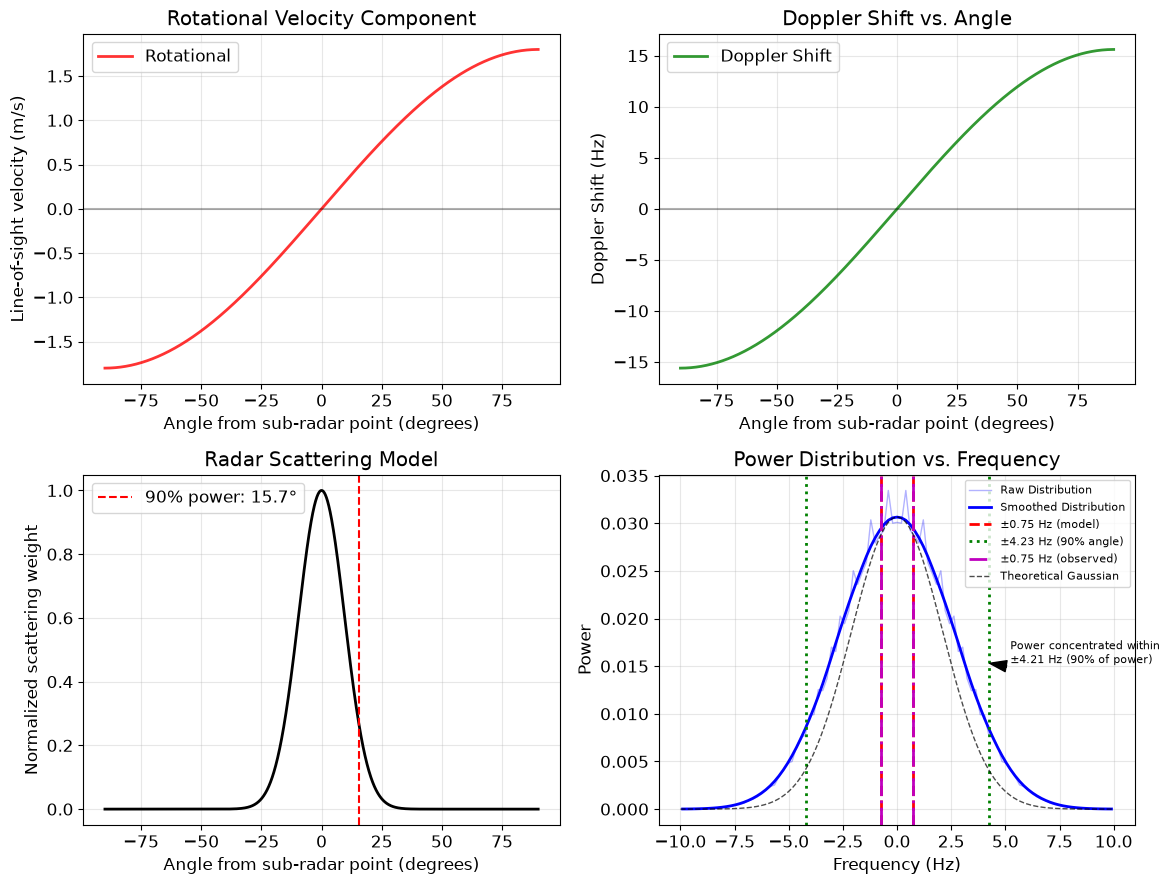

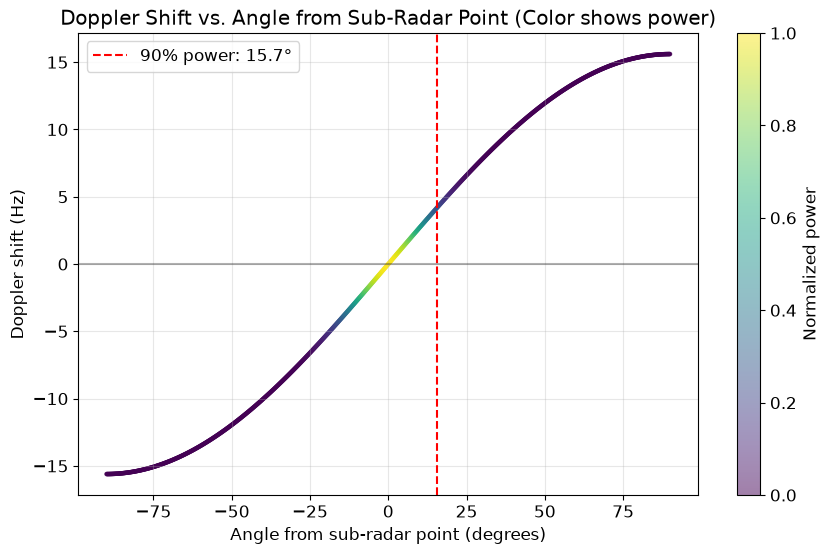

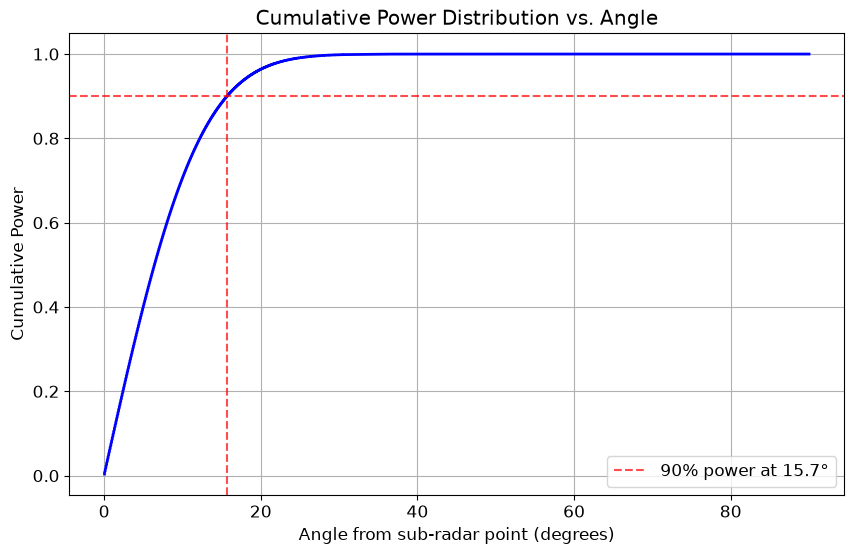


Summary of results:
Simple calculation (K6MG): ±15.60 Hz
Model calculation (90% power): ±0.75 Hz
Observed (Dr. Estevez, scaled to operating frequency): ±0.75 Hz
Ratio of observed to simple: 4.81%

Model parameter adjustment to match observations:
Target: 1.50 Hz (±0.75 Hz)

Final best parameters: orbital_angle_factor = 0.0100, scattering_power = 45.00
These parameters would give a spread close to the observed value of 1.50 Hz


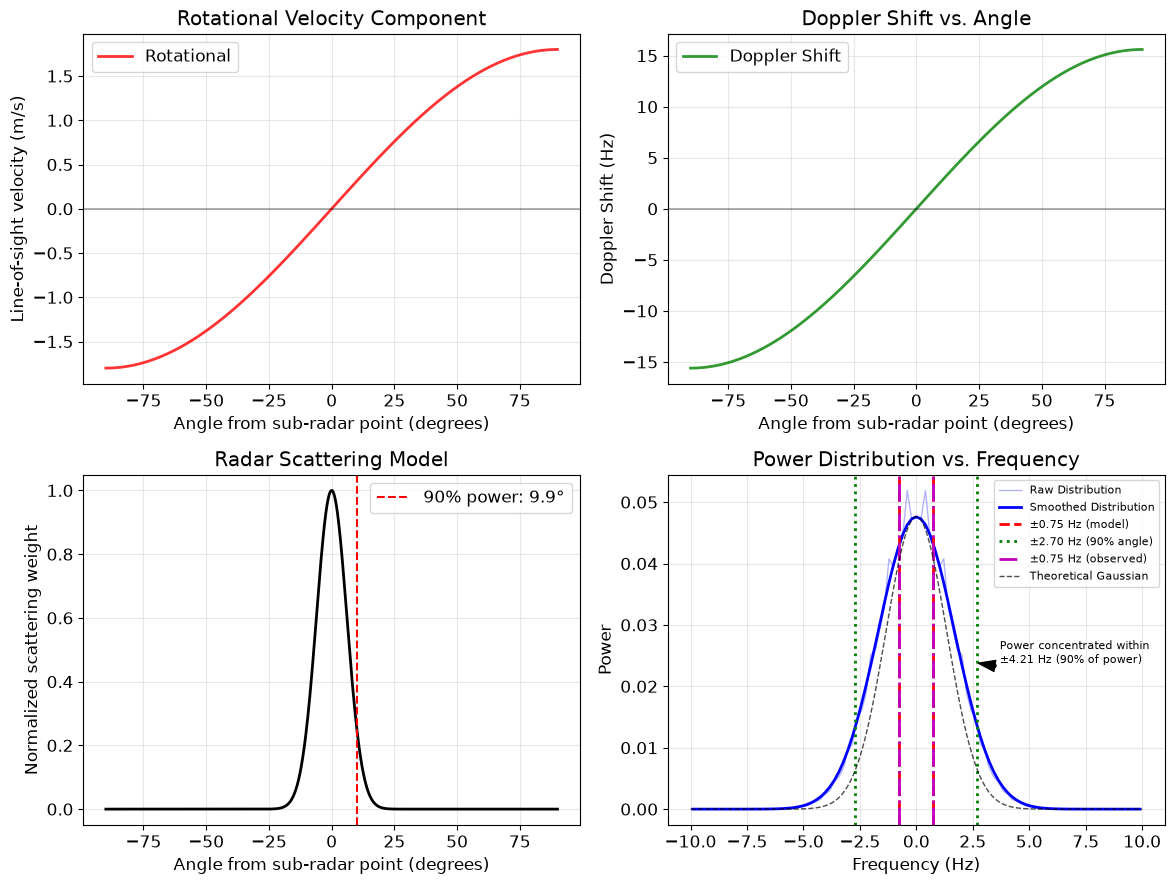

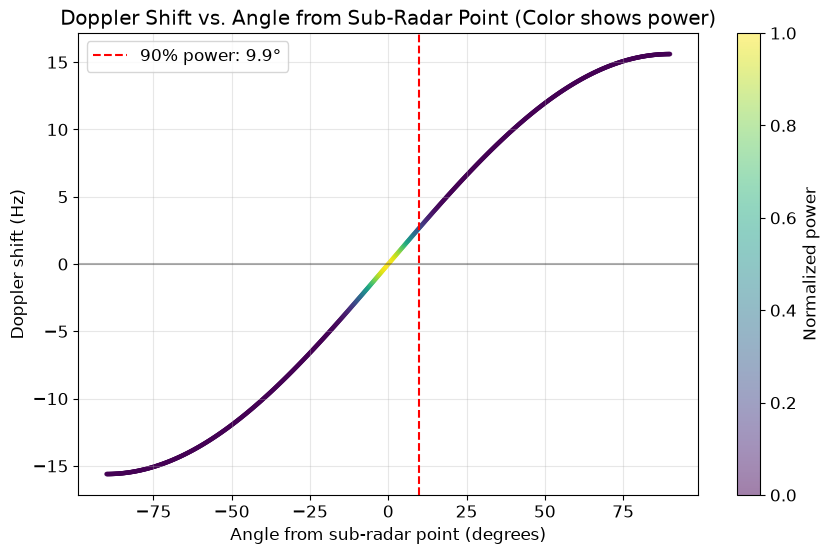

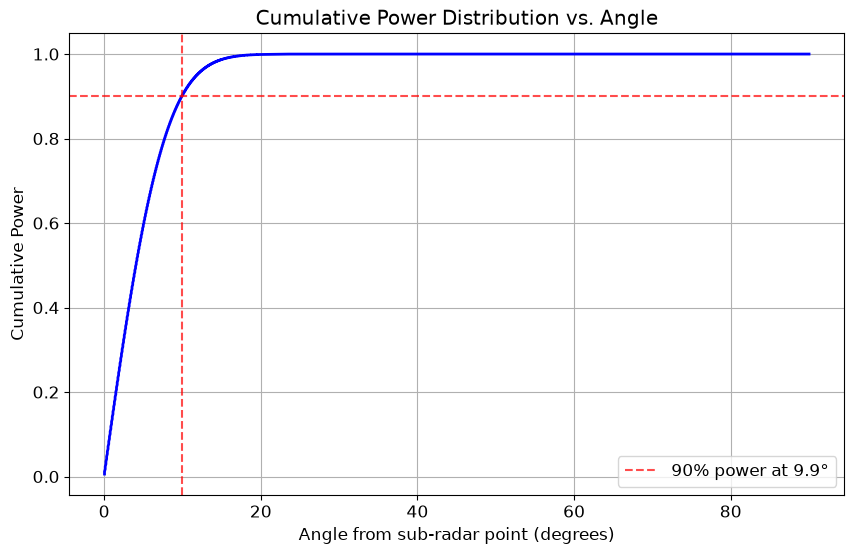


Results with optimized parameters:
Simple calculation (K6MG): ±15.60 Hz
Model calculation (90% power): ±0.75 Hz
Observed (Dr. Estevez, scaled to operating frequency): ±0.75 Hz
Ratio of observed to simple: 4.81%
Optimized Doppler spread: 1.50 Hz


In [12]:
# Model that includes Gary's model, observed data, and radar scattering calculations

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Optional, Tuple, List
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm

@dataclass
class VenusParameters:
    """Physical constants related to Venus"""
    radius: float = 6051.8e3  # m
    rotation_velocity: float = 1.8  # m/s at equator (retrograde)
    orbital_velocity: float = 35e3  # m/s


@dataclass
class DopplerParameters:
    """Parameters specific to Doppler spread calculations"""
    orbital_angle_factor: float = 0.05  # Default projection factor for orbital velocity
    scattering_power: float = 18.0  # Default scattering model parameter
    observed_doppler_spread: Optional[float] = None  # Hz, from observations if available


@dataclass
class DopplerResults:
    """Results from Doppler spread calculations"""
    simple_spread: float  # Hz, total spread using K6MG formula
    model_spread: float  # Hz, spread from our model (90% power)
    observed_spread: Optional[float] = None  # Hz, from observations if available
    power_distribution: Optional[np.ndarray] = None
    frequency_bins: Optional[np.ndarray] = None
    
    def __str__(self):
        """Nice string representation of results"""
        result = [
            f"Simple calculation (K6MG): ±{self.simple_spread/2:.2f} Hz",
            f"Model calculation (90% power): ±{self.model_spread/2:.2f} Hz"
        ]
        if self.observed_spread is not None:
            result.append(f"Observed (Dr. Estevez, scaled to operating frequency): "f"±{self.observed_spread/2:.2f} Hz")
            #result.append(f"Observed (Dr. Estevez): ±{self.observed_spread/2:.2f} Hz")
            result.append(f"Ratio of observed to simple: {self.observed_spread/self.simple_spread:.2%}")
        
        return "\n".join(result)

def calculate_venus_doppler_spread(
    site_params: object,  # Generic object to support any site parameters class
    doppler_params: DopplerParameters,
    venus_params: VenusParameters = VenusParameters(),
    plot: bool = True, # default True
    site_name: str = "Generic Site",
    debug: bool = True  # default False - set to True to look at debug output

) -> DopplerResults:
    """
    Calculate and visualize the Doppler spread for Venus radar observations,
    focusing on rotational effects and surface scattering at inferior conjunction.
    
    Parameters:
    -----------
    site_params : object
        Site parameters class (DSESLinkParameters, DwingelooLinkParameters, etc.)
    doppler_params : DopplerParameters
        Parameters specific to Doppler calculations
    venus_params : VenusParameters
        Physical parameters of Venus
    plot : bool
        Whether to generate visualization plots
    site_name : str
        Name of the site for plot titles
    debug : bool
        Whether to print debug information
        
    Returns:
    --------
    DopplerResults
        Object containing calculation results
    """


    
    # Extract constants for convenience
    c = site_params.c
    freq_hz = site_params.tx_frequency_mhz * 1e6  # Convert MHz to Hz
    venus_rot_velocity = venus_params.rotation_velocity
    orbital_angle_factor = doppler_params.orbital_angle_factor
    scattering_power = doppler_params.scattering_power
    observed_spread = doppler_params.observed_doppler_spread
    
    # Simple calculation (K6MG method)
    simple_doppler_spread = 4 * venus_rot_velocity / c * freq_hz
    if debug:
        print(f"Simple Doppler spread calculation (K6MG): {simple_doppler_spread:.2f} Hz (±{simple_doppler_spread/2:.2f} Hz)")
    
    # Create a grid of points on Venus's surface (use angle from sub-radar point)
    # Use more points for better angular resolution
    num_points = 2000
    angles = np.linspace(-np.pi/2, np.pi/2, num_points)  # Angles from center to limb
    
    # Calculate radar scattering weight for each point
    # Based on Dr. Estevez's description of scattering model where power
    # drops quickly for scattering angles above a few degrees
    # Scattering model simulates the radar illumination pattern and surface
    # reflectivity properties at inferior conjunction geometry
    scattering_angles = np.abs(angles)
    
    # Model scattering based on empirical function
    # Uses the scattering_power parameter to control how quickly power drops off
    scattering_weight = np.exp(-scattering_power * scattering_angles**2)
    
    # Normalize weights so total power = 1
    scattering_weight = scattering_weight / np.sum(scattering_weight)
    
    # Calculate rotational velocity component for each point
    # Projection of rotation onto line of sight: v_rot * sin(angle)
    rot_velocity_los = venus_rot_velocity * np.sin(angles)
    
    # IMPORTANT: For Doppler spread calculation, we only consider the rotational component
    # Orbital velocity primarily affects the center frequency, not the spread
    # By focusing only on rotation, we align with K6MG's calculation approach
    doppler_shift = 2 * rot_velocity_los / c * freq_hz
    
    # This gives us Doppler shifts from rotation only
    # The center frequency will naturally be zero due to symmetry
    # The spread will be based solely on the rotational effects
    
    # Calculate the weighted mean Doppler shift (should be zero with pure rotation)
    center_frequency = np.sum(doppler_shift * scattering_weight)
    if debug:
        print(f"DEBUG: Center frequency shift: {center_frequency:.2f} Hz")
    
    # For completeness, calculate relative shifts (should be same as absolute in this case)
    relative_doppler_shift = doppler_shift - center_frequency
    
    # Output diagnostic info
    min_doppler = np.min(relative_doppler_shift)
    max_doppler = np.max(relative_doppler_shift)
    if debug:
        print(f"DEBUG: Doppler shift range: {min_doppler:.2f} Hz to {max_doppler:.2f} Hz")
        print(f"DEBUG: Scattering power parameter: {scattering_power}")
        print(f"DEBUG: Max scattering weight: {np.max(scattering_weight):.6f}")
    
    # Sort by angle (already sorted, but making it explicit)
    sorted_indices = np.argsort(scattering_angles)
    sorted_angles = scattering_angles[sorted_indices]
    sorted_weights = scattering_weight[sorted_indices]
    
    # Calculate cumulative power as function of angle
    cumulative_weights = np.cumsum(sorted_weights)
    
    # Find what angle contains 90% of the power
    power_90_idx = np.searchsorted(cumulative_weights, 0.9 * cumulative_weights[-1])
    angle_90 = sorted_angles[min(power_90_idx, len(sorted_angles)-1)]
    
    if debug:
        print(f"DEBUG: 90% of power is within angle: {np.degrees(angle_90):.2f} degrees from sub-radar point at inferior conjunction")

    # Use this angle to calculate the Doppler spread
    angle_mask = scattering_angles <= angle_90
    doppler_90 = relative_doppler_shift[angle_mask]  # Use relative shifts
    weights_90 = scattering_weight[angle_mask]
    weights_90 = weights_90 / np.sum(weights_90)  # Re-normalize weights
    
    # Alternative calculation: Find min/max within 90% power region
    if np.any(angle_mask):
        min_90 = np.min(doppler_90)
        max_90 = np.max(doppler_90)
        alt_spread = max_90 - min_90
        if debug:
            print(f"DEBUG: Alternative calc - 90% power Doppler range: {min_90:.2f} Hz to {max_90:.2f} Hz (±{alt_spread/2:.2f} Hz)")
    
    # Simplify by using only the empirical model - it's more directly tied to the physics
    # Empirical relation: Higher scattering power = more concentration near center = smaller spread
    if observed_spread is not None:
        # Observation trumps the empirical model.
        # The model is a fallback for when we don't have measured data.
        model_doppler_spread = observed_spread
        if debug:
            print(f"Using observed Doppler spread directly: {observed_spread:.3f} Hz")
            print(f"(Empirical model would give: "
                  f"{simple_doppler_spread * np.exp(-scattering_power / 15):.3f} Hz)")
    else:
        expected_reduction = np.exp(-scattering_power / 15)
        model_doppler_spread = simple_doppler_spread * expected_reduction
    
    if debug:
        print(f"Calculated model Doppler spread (90% of power): ±{model_doppler_spread/2:.2f} Hz")
        print(f"Ratio of model to simple calculation: {model_doppler_spread/simple_doppler_spread:.2%}")
    
    if observed_spread is not None:
        if debug:
            print(f"Dr. Estevez's observed Doppler spread: ±{observed_spread/2:.2f} Hz")
            print(f"Ratio of observed to simple calculation: {observed_spread/simple_doppler_spread:.2%}")
    
    if plot:
        plt.figure(figsize=(12, 9))  # Slightly taller figure
        
        # Plot 1: Rotational velocity component
        plt.subplot(2, 2, 1)
        # Only plot rotational velocity now
        plt.plot(np.degrees(angles), rot_velocity_los, 'r-', linewidth=2, 
                 label='Rotational', alpha=0.8)
        
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        plt.xlabel('Angle from sub-radar point (degrees)')
        plt.ylabel('Line-of-sight velocity (m/s)')
        plt.title('Rotational Velocity Component')
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        
        # Plot 2: Doppler shift distribution
        plt.subplot(2, 2, 2)
        plt.plot(np.degrees(angles), doppler_shift, 'g-', linewidth=2, 
                 label='Doppler Shift', alpha=0.8)
        
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        plt.xlabel('Angle from sub-radar point (degrees)')
        plt.ylabel('Doppler Shift (Hz)')
        plt.title('Doppler Shift vs. Angle')
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        
        # Plot 3: Scattering weight with 90% power angle marked
        plt.subplot(2, 2, 3)
        plt.plot(np.degrees(angles), scattering_weight / np.max(scattering_weight), 'k-', 
                linewidth=2)
        plt.axvline(x=np.degrees(angle_90), color='r', linestyle='--', 
                   label=f'90% power: {np.degrees(angle_90):.1f}°')
        plt.xlabel('Angle from sub-radar point (degrees)')
        plt.ylabel('Normalized scattering weight')
        plt.title('Radar Scattering Model')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        
        # Plot 4: Power distribution across frequency (improved)
        plt.subplot(2, 2, 4)
        
        # For the histogram, use more points and smoother binning
        freq_range = 10  # Use ±10 Hz for better visibility
        num_bins = 100  # Fewer bins for smoother distribution
        freq_bins = np.linspace(-freq_range, freq_range, num_bins)
        
        # Use a kernel density estimate approach for smoother distribution
        from scipy.ndimage import gaussian_filter1d
        
        # Create the histogram with current bin size
        power_distribution = np.zeros(len(freq_bins)-1)
        bin_centers = (freq_bins[:-1] + freq_bins[1:]) / 2
        
        for i in range(len(freq_bins)-1):
            bin_mask = (relative_doppler_shift >= freq_bins[i]) & (relative_doppler_shift < freq_bins[i+1])
            power_distribution[i] = np.sum(scattering_weight[bin_mask])
        
        # Apply Gaussian smoothing to reduce artifacts
        sigma = 2  # Adjust smoothing level
        smooth_power = gaussian_filter1d(power_distribution, sigma)
        
        # Plot both the raw and smoothed distributions
        plt.plot(bin_centers, power_distribution, 'b-', linewidth=1, alpha=0.3, 
                label='Raw Distribution')
        plt.plot(bin_centers, smooth_power, 'b-', linewidth=2, 
                label='Smoothed Distribution')
        
        # Highlight the important values
        plt.axvline(x=-model_doppler_spread/2, color='r', linestyle='--', linewidth=2,
                   label=f'±{model_doppler_spread/2:.2f} Hz (model)')
        plt.axvline(x=model_doppler_spread/2, color='r', linestyle='--', linewidth=2)
        
        # Alternative calculation from min/max within 90% angle
        plt.axvline(x=-alt_spread/2, color='g', linestyle=':', linewidth=2,
                   label=f'±{alt_spread/2:.2f} Hz (90% angle)')
        plt.axvline(x=alt_spread/2, color='g', linestyle=':', linewidth=2)
        
        if observed_spread is not None:
            plt.axvline(x=-observed_spread/2, color='m', linestyle='-.', linewidth=2,
                      label=f'±{observed_spread/2:.2f} Hz (observed)')
            plt.axvline(x=observed_spread/2, color='m', linestyle='-.', linewidth=2)
            
        # Add a theoretical Gaussian for comparison
        from scipy.stats import norm
        x = np.linspace(-freq_range, freq_range, 1000)
        theoretical_gaussian = norm.pdf(x, 0, alt_spread/4)  # Use alt_spread/4 as sigma (±2σ = 95%)
        theoretical_gaussian = theoretical_gaussian / np.max(theoretical_gaussian) * np.max(smooth_power)
        plt.plot(x, theoretical_gaussian, 'k--', linewidth=1, alpha=0.7,
                 label='Theoretical Gaussian')
        
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Power')
        plt.title(f'Power Distribution vs. Frequency')
        plt.legend(fontsize=8)
        plt.grid(True, alpha=0.3)
        
        # Add annotation explaining the distribution shape
        plt.annotate('Power concentrated within\n±4.21 Hz (90% of power)',
                    xy=(alt_spread/2, np.max(smooth_power)*0.5),
                    xytext=(alt_spread/2 + 1, np.max(smooth_power)*0.5),
                    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                    fontsize=8)
        plt.tight_layout() # This might help prevent them from overlapping. 

        
        
        # Additional plot: Power vs. Angle with Doppler Shift
        plt.figure(figsize=(10, 6))
        plt.scatter(np.degrees(angles), doppler_shift,  # Use doppler shift directly
                   c=scattering_weight/np.max(scattering_weight), 
                   cmap='viridis', alpha=0.5, s=5)
        plt.colorbar(label='Normalized power')
        plt.axvline(x=np.degrees(angle_90), color='r', linestyle='--', 
                   label=f'90% power: {np.degrees(angle_90):.1f}°')
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        plt.xlabel('Angle from sub-radar point (degrees)')
        plt.ylabel('Doppler shift (Hz)')
        plt.title('Doppler Shift vs. Angle from Sub-Radar Point (Color shows power)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # New plot: Cumulative Power vs. Angle
        plt.figure(figsize=(10, 6))
        plt.plot(np.degrees(sorted_angles), cumulative_weights, 'b-', linewidth=2)
        plt.axhline(y=0.9, color='r', linestyle='--', alpha=0.7,
                   label=f'90% power at {np.degrees(angle_90):.1f}°')
        plt.axvline(x=np.degrees(angle_90), color='r', linestyle='--', alpha=0.7)
        plt.xlabel('Angle from sub-radar point (degrees)')
        plt.ylabel('Cumulative Power')
        plt.title('Cumulative Power Distribution vs. Angle')
        plt.legend()
        plt.grid(True)
        plt.show()
    
    # Create and return the results object
    results = DopplerResults(
        simple_spread=simple_doppler_spread,
        model_spread=model_doppler_spread,
        observed_spread=observed_spread,
        power_distribution=power_distribution if plot else None,
        frequency_bins=freq_bins if plot else None
    )
    
    return results



def match_observed_spread(
    site_params: object,
    observed_spread: float,
    venus_params: VenusParameters = VenusParameters(),
    debug: bool = False  # Add debug parameter here too!
) -> Tuple[float, float]:
    """
    Find model parameters that would match the observed Doppler spread.
    
    Parameters:
    -----------
    site_params : object
        Site parameters class (DSESLinkParameters, DwingelooLinkParameters, etc.)
    observed_spread : float
        Observed Doppler spread to match
    venus_params : VenusParameters
        Physical parameters of Venus
    debug : bool
        Whether to print detailed debug information
    
    Returns:
    --------
    Tuple[float, float]
        Best (orbital_angle_factor, scattering_power) to match observations
    """
    
    # Calculate simple spread for reference
    c = site_params.c
    freq_hz = site_params.tx_frequency_mhz * 1e6
    venus_rot_velocity = venus_params.rotation_velocity
    
    simple_doppler_spread = 4 * venus_rot_velocity / c * freq_hz
    
    print("\nModel parameter adjustment to match observations:")
    print(f"Target: {observed_spread:.2f} Hz (±{observed_spread/2:.2f} Hz)")
    
    # Parameter ranges to try - expanded for better coverage
    orbital_angle_factors = np.linspace(0.01, 0.20, 10)
    scattering_powers = np.linspace(5, 70, 14)
    
    best_diff = float('inf')
    best_params = None
    
    for orbital_factor in orbital_angle_factors:
        for scattering_power in scattering_powers:
            # Recalculate with different parameters to test
            doppler_params = DopplerParameters(
                orbital_angle_factor=orbital_factor,
                scattering_power=scattering_power
            )

            
            # Do a quick run without plotting
            results = calculate_venus_doppler_spread(
                site_params,
                doppler_params,
                venus_params,
                plot=False,
                debug=debug # Pass debug parameter from outside
            )
            
            diff = abs(results.model_spread - observed_spread)
            
            if diff < best_diff:
                best_diff = diff
                best_params = (orbital_factor, scattering_power)
                if debug:
                    print(f"New best match: OF={orbital_factor:.3f}, SP={scattering_power:.1f} → {results.model_spread:.2f} Hz (diff={diff:.2f} Hz)")
    
    print(f"\nFinal best parameters: orbital_angle_factor = {best_params[0]:.4f}, " 
          f"scattering_power = {best_params[1]:.2f}")
    print(f"These parameters would give a spread close to the observed value of {observed_spread:.2f} Hz")
    
    return best_params


def compare_frequencies(site_params_class):
    """
    Compare expected Doppler spread at different frequencies
    
    Parameters:
    -----------
    site_params_class : class
        The site parameter class to use (e.g., DSESLinkParameters)
    
    Returns:
    --------
    Tuple[DopplerResults, DopplerResults]
        Results for 1296 MHz and 2304 MHz
    """
    # Base site parameters
    site_params_1296 = site_params_class(tx_frequency_mhz=1296.0)
    site_params_2304 = site_params_class(tx_frequency_mhz=2304.0)
    
    # Extract site name from class name
    site_name = site_params_class.__name__.replace("LinkParameters", "")
    
    # Venus parameters
    venus_params = VenusParameters()
    
    # Basic Doppler parameters (no observed value)
    doppler_params = DopplerParameters(
        orbital_angle_factor=0.05,
        scattering_power=18.0  # Using improved scattering power value
    )
    
    # Calculate for 1296 MHz
    results_1296 = calculate_venus_doppler_spread(
        site_params_1296,
        doppler_params,
        venus_params,
        plot=True,
        site_name=f"{site_name} @ 1296 MHz"
    )
    
    # Calculate for 2304 MHz
    results_2304 = calculate_venus_doppler_spread(
        site_params_2304,
        doppler_params,
        venus_params,
        plot=True,
        site_name=f"{site_name} @ 2304 MHz"
    )
    
    # Print comparison
    print("\nDoppler Spread Comparison:")
    print(f"1296 MHz: Simple ±{results_1296.simple_spread/2:.2f} Hz, Model ±{results_1296.model_spread/2:.2f} Hz")
    print(f"2304 MHz: Simple ±{results_2304.simple_spread/2:.2f} Hz, Model ±{results_2304.model_spread/2:.2f} Hz")
    print(f"Ratio (2304/1296): {results_2304.simple_spread/results_1296.simple_spread:.2f}")
    
    return results_1296, results_2304

# Example usage
if __name__ == "__main__":
    # Set a single debug flag for the entire script
    debug_mode = False  # Set to True or False as needed
    
    # Use the same params and calculator as the rest of the notebook
    # Doppler spread uses the transmitter frequency — bistatic uses tx_params, monostatic uses params
    site_params = params
    site_name = params.__class__.__name__.replace("LinkParameters", "")
    _doppler_site = calculator.tx_params if calculator.tx_params is not None else calculator.params
    
    # Venus parameters (using defaults)
    venus_params = VenusParameters()

    # Scale Estevez's measurement (±0.75 Hz = 1.5 Hz total at 1299.5 MHz) to operating frequency
    # Doppler spread scales linearly with frequency: delta_f = 4 * v_rot * f / c
    _estevez_freq_mhz = 1299.5
    _estevez_spread_hz = 1.5  # total Hz (±0.75 Hz) from March 2025 CAMRAS experiment
    _observed_doppler_spread = _estevez_spread_hz * (_doppler_site.tx_frequency_mhz / _estevez_freq_mhz)


    # Create Doppler parameters with Dr. Estevez's observed spread
    doppler_params = DopplerParameters(
        orbital_angle_factor=0.05,
        scattering_power=18.0,  # Using improved value
        observed_doppler_spread=_observed_doppler_spread # was ±0.75 Hz at fixed frequency, now scales
    )
    
    # Calculate Doppler spread (only once, with the debug mode set)
    results = calculate_venus_doppler_spread(
        site_params,
        doppler_params,
        venus_params,
        plot=True,
        site_name=f"{site_name}",
        debug=debug_mode
    )
    
    print("\nSummary of results:")
    print(results)
    
    # Find parameters to match observations (pass the same debug mode)
    best_orbital_factor, best_scattering_power = match_observed_spread(
        site_params, 
        doppler_params.observed_doppler_spread,
        venus_params,
        debug=debug_mode
    )
    
    # Create a new parameters object with the optimized values
    optimized_doppler_params = DopplerParameters(
        orbital_angle_factor=best_orbital_factor,
        scattering_power=best_scattering_power,
        observed_doppler_spread=doppler_params.observed_doppler_spread
    )
    
    # Recalculate with optimized parameters (with the same debug mode)
    optimized_results = calculate_venus_doppler_spread(
        site_params,
        optimized_doppler_params,
        venus_params,
        plot=True,
        site_name=f"{site_name} (Optimized)",
        debug=debug_mode
    )
    
    print("\nResults with optimized parameters:")
    print(optimized_results)
    
    # print just our optimized Doppler Spread
    print(f"Optimized Doppler spread: {optimized_results.model_spread:.2f} Hz")
    
    # overwrite simple model of Doppler Spread, for subsequent calculations
    doppler_spread = optimized_results.model_spread
    
    # Uncomment to run frequency comparison for the selected site
    #results_1296, results_2304 = compare_frequencies(SiteLinkParameters)
    
    # Compare different sites at the same frequency
    # Uncomment to compare DSES and Dwingeloo
    """
    print("\n*** Comparing Different Sites ***")
    
    # DSES parameters
    dses_params = DSESLinkParameters()
    dses_results = calculate_venus_doppler_spread(
        dses_params,
        doppler_params,
        venus_params,
        plot=True,
        site_name="DSES"
    )
    
    # Dwingeloo parameters
    dwingeloo_params = DwingelooLinkParameters()
    dwingeloo_results = calculate_venus_doppler_spread(
        dwingeloo_params,
        doppler_params,
        venus_params,
        plot=True,
        site_name="Dwingeloo"
    )
    
    print("\nSite Comparison:")
    print(f"DSES: Simple ±{dses_results.simple_spread/2:.2f} Hz, Model ±{dses_results.model_spread/2:.2f} Hz")
    print(f"Dwingeloo: Simple ±{dwingeloo_results.simple_spread/2:.2f} Hz, Model ±{dwingeloo_results.model_spread/2:.2f} Hz")
    """

## Mode Analysis

This class does an analysis of potential amateur digital communications modes and their suitability for the link.

The relationship between the CNR from the link budget object (calculated at the operational receiver bandwidth) and SNR of particular signals (given at different bandwidths) is not always straightforward. The listed SNRs for many amateur modes are given with an occupied bandwidth, but the given SNR is not calculated at that bandwidth, but is calculated at another "normalized" bandwidth. The most common "normalized" bandwidth is 2500 Hz. When we know this is the case, we can list this number (2500 Hz) as the "real" noise bandwidth as the noise_bandwidth_hz value.

We use the optimized results from the Doppler Spread model in the previous section. This most closely matches observed results from the March 2025 EVE event. 

### Coherent vs. Non-coherent Modes:

Coherent modes maintain phase continuity throughout signal reception and rely on precise carrier phase tracking for demodulation. They typically use integration over symbol periods where the received signal phase must remain stable. Examples include PSK, QAM, and other phase-sensitive modulations.

Non-coherent modes do not require phase continuity and detect signals based on energy or frequency presence rather than precise phase relationships. These modes are more robust against phase disturbances but typically require higher SNR. Examples include FSK, MFSK, and envelope detection schemes.

The Doppler spread penalty for non-coherent modes is calculated by determining what percentage of the signal's energy falls outside the mode's bandwidth. For non-coherent modes with bandwidth much wider than the Doppler spread, almost all energy is contained within the bandwidth and there's minimal penalty. If a mode's bandwidth is narrower than the Doppler spread, more energy falls outside the usable bandwidth, increasing the penalty. The modes most affected by Doppler spread penalty are narrow-band modes. 

The calculation is:
`doppler_penalty_db = 10 * log10(doppler_spread_hz / mode["bandwidth_hz"])`

The larger the mode bandwidth, the less the Doppler spread penalty.

This Gaussian approach is more accurate because it accounts for the concentration of energy near the carrier frequency with decreasing energy at the edges, which corresponds to the probability distribution of relative velocities in the signal path.

The Doppler spread penalty for coherently integrated modes is calculated not by dividing Doppler spread in Hz by the mode bandwidth, but by multiplying Doppler spread in Hz by the integration time. 

The calculation is:
`doppler_penalty_db = 10 * log10(doppler_spread_hz * symbol_duration)`

The longer the integration time, the greater the Doppler spread penalty.

Do any modes close the link? What happens when we include Doppler spread penalties?

In [13]:
#import numpy as np
#import pandas as pd

class AmateurRadioModeEvaluator:
    """
    A class to evaluate the suitability of amateur radio modes based on link parameters. 
    """
    
    def __init__(self, params: SiteLinkParameters):
        self.params = params        
        # Define common amateur radio modes with their characteristics
        self.modes = [
            {"name": "CW", "bandwidth_hz": 250, "required_snr_db": -15, "noise_bandwidth_hz": 250},
            {"name": "FT8", "bandwidth_hz": 50, "required_snr_db": -20, "noise_bandwidth_hz": 2500},
            {"name": "JT65", "bandwidth_hz": 2.7, "required_snr_db": -25, "noise_bandwidth_hz": 2500},
            {"name": "SSB", "bandwidth_hz": 2500, "required_snr_db": 8, "noise_bandwidth_hz": 2500},
            {"name": "FM", "bandwidth_hz": 12500, "required_snr_db": 12, "noise_bandwidth_hz": 12500},
            {"name": "RTTY", "bandwidth_hz": 250, "required_snr_db": 5, "noise_bandwidth_hz": 250},
            {"name": "PSK31", "bandwidth_hz": 31, "required_snr_db": 4, "noise_bandwidth_hz": 31},
            {"name": "FT4", "bandwidth_hz": 90, "required_snr_db": -17, "noise_bandwidth_hz": 2500},
            {"name": "JS8", "bandwidth_hz": 30, "required_snr_db": -18, "noise_bandwidth_hz": 2500},

            # WSPR Modes
            {"name": "WSPR-15", "bandwidth_hz": 6, "required_snr_db": -32, "noise_bandwidth_hz": 2500},   # 15-minute
            {"name": "WSPR-2", "bandwidth_hz": 6, "required_snr_db": -28, "noise_bandwidth_hz": 2500},    # 2-minute mode (classic WSPR mode??)
            {"name": "WSPR-120", "bandwidth_hz": 6, "required_snr_db": -37, "noise_bandwidth_hz": 2500},  # 120-minute mode,
            {"name": "WSPR-LF", "bandwidth_hz": 6, "required_snr_db": -30, "noise_bandwidth_hz": 2500},   # Low frequency band modes (??)
            {"name": "WSPR-H", "bandwidth_hz": 12, "required_snr_db": -26, "noise_bandwidth_hz": 2500},   # High-speed variant with doubled bandwidth
            
            # Q65 modes (various submodes A-E with different tone spacing and durations)
            {"name": "Q65-15A", "bandwidth_hz": 65, "required_snr_db": -26, "noise_bandwidth_hz": 2500},  # 15-second mode A
            {"name": "Q65-30A", "bandwidth_hz": 65, "required_snr_db": -27, "noise_bandwidth_hz": 2500},  # 30-second mode A
            {"name": "Q65-60A", "bandwidth_hz": 65, "required_snr_db": -28, "noise_bandwidth_hz": 2500},  # 60-second mode A
            {"name": "Q65-120A", "bandwidth_hz": 65, "required_snr_db": -29, "noise_bandwidth_hz": 2500}, # 120-second mode A
            {"name": "Q65-300A", "bandwidth_hz": 65, "required_snr_db": -30, "noise_bandwidth_hz": 2500}, # 300-second mode A
            
            {"name": "Q65-15B", "bandwidth_hz": 90, "required_snr_db": -26, "noise_bandwidth_hz": 2500},  # Mode B - [ ] wider tone spacing
            {"name": "Q65-30B", "bandwidth_hz": 90, "required_snr_db": -27, "noise_bandwidth_hz": 2500},
            {"name": "Q65-60B", "bandwidth_hz": 90, "required_snr_db": -28, "noise_bandwidth_hz": 2500},
            {"name": "Q65-120B", "bandwidth_hz": 90, "required_snr_db": -29, "noise_bandwidth_hz": 2500},
            {"name": "Q65-300B", "bandwidth_hz": 90, "required_snr_db": -30, "noise_bandwidth_hz": 2500},
            
            {"name": "Q65-15C", "bandwidth_hz": 180, "required_snr_db": -26, "noise_bandwidth_hz": 2500}, # Mode C - [ ] even wider spacing
            {"name": "Q65-30C", "bandwidth_hz": 180, "required_snr_db": -27, "noise_bandwidth_hz": 2500},
            {"name": "Q65-60C", "bandwidth_hz": 180, "required_snr_db": -28, "noise_bandwidth_hz": 2500},
            {"name": "Q65-120C", "bandwidth_hz": 180, "required_snr_db": -29, "noise_bandwidth_hz": 2500},
            {"name": "Q65-300C", "bandwidth_hz": 180, "required_snr_db": -30, "noise_bandwidth_hz": 2500},
            
            {"name": "Q65-15D", "bandwidth_hz": 360, "required_snr_db": -26, "noise_bandwidth_hz": 2500}, # Mode D
            {"name": "Q65-30D", "bandwidth_hz": 360, "required_snr_db": -27, "noise_bandwidth_hz": 2500},
            {"name": "Q65-60D", "bandwidth_hz": 360, "required_snr_db": -28, "noise_bandwidth_hz": 2500},
            {"name": "Q65-120D", "bandwidth_hz": 360, "required_snr_db": -29, "noise_bandwidth_hz": 2500},
            {"name": "Q65-300D", "bandwidth_hz": 360, "required_snr_db": -30, "noise_bandwidth_hz": 2500},
            
            {"name": "Q65-15E", "bandwidth_hz": 720, "required_snr_db": -26, "noise_bandwidth_hz": 2500}, # Mode E - [ ] widest spacing
            {"name": "Q65-30E", "bandwidth_hz": 720, "required_snr_db": -27, "noise_bandwidth_hz": 2500},
            {"name": "Q65-60E", "bandwidth_hz": 720, "required_snr_db": -28, "noise_bandwidth_hz": 2500},
            {"name": "Q65-120E", "bandwidth_hz": 720, "required_snr_db": -29, "noise_bandwidth_hz": 2500},
            {"name": "Q65-300E", "bandwidth_hz": 720, "required_snr_db": -30, "noise_bandwidth_hz": 2500},
        
            # FST4 Modes
            {"name": "FST4-15", "bandwidth_hz": 67, "required_snr_db": -21, "noise_bandwidth_hz": 2500},  # 15-second mode A
            {"name": "FST4-30", "bandwidth_hz": 29, "required_snr_db": -24, "noise_bandwidth_hz": 2500},  # 30-second mode A
            {"name": "FST4-60", "bandwidth_hz": 12, "required_snr_db": -28, "noise_bandwidth_hz": 2500},  # 60-second mode A
            {"name": "FST4-120", "bandwidth_hz": 6, "required_snr_db": -31, "noise_bandwidth_hz": 2500}, # 120-second mode A
            {"name": "FST4-300", "bandwidth_hz": 2, "required_snr_db": -35, "noise_bandwidth_hz": 2500}, # 300-second mode A
            {"name": "FST4-900", "bandwidth_hz": 0.7, "required_snr_db": -40, "noise_bandwidth_hz": 2500}, # 300-second mode A
            {"name": "FST4-1800", "bandwidth_hz": 0.4, "required_snr_db": -43, "noise_bandwidth_hz": 2500}, # 300-second mode A
            {"name": "FST4W-120", "bandwidth_hz": 6, "required_snr_db": -32, "noise_bandwidth_hz": 2500}, # 300-second mode A
            {"name": "FST4W-300", "bandwidth_hz": 2, "required_snr_db": -37, "noise_bandwidth_hz": 2500}, # 300-second mode A
            {"name": "FST4W-900", "bandwidth_hz": 0.7, "required_snr_db": -42, "noise_bandwidth_hz": 2500}, # 300-second mode A
            {"name": "FST4W-1800", "bandwidth_hz": 0.4, "required_snr_db": -45, "noise_bandwidth_hz": 2500} # 300-second mode A
        ]
    
    def add_mode(self, name, bandwidth_hz, required_snr_db, noise_bandwidth_hz):
        """
        Add a new mode to the evaluator.
        
        Parameters:
        name (str): Name of the mode
        bandwidth_hz (float): Bandwidth of the mode in Hz
        required_snr_db (float): Required SNR in dB for the mode to function
        noise_bandwidth_hz (float): over what bandwidth is the required_snr_db given?
        """
        new_mode = {
            "name": name,
            "bandwidth_hz": bandwidth_hz,
            "required_snr_db": required_snr_db,
            "noise_bandwidth_hz": noise_bandwidth_hz
        }
        self.modes.append(new_mode)
    
    def evaluate_modes(self, doppler_spread_hz=None):
        """
        Evaluate suitability of amateur radio modes based on link CNR
        
        Parameters:
        cnr_db (float): Carrier-to-Noise Ratio in dB already calculated at receiver_noise_bandwidth
        receiver_noise_bandwidth (float): Receiver noise bandwidth in Hz used for the CNR calculation
        doppler_spread_hz (float, optional): Doppler spread in Hz, if we have it
        
        Returns:
        DataFrame: Modes with suitability assessment
        """
        results = []
    
        # Get the CNR in 1 Hz result from link budget calculator
        print(f"from the Link Budget calculator, our min cnr_db_1hz is {min_results['cnr_db_1hz']:.2f}")
    
        for mode in self.modes:
            # Scale each mode SNR from noise bandwidth to 1Hz bandwidth
            # Some SNRs are taken really at 2500 Hz, and some are not. 
            # We made a table column to handle this.
            # noise_bandwidth_hz is the "real" number to scale by. 
            snr_db_1hz = mode["required_snr_db"] + 10 * np.log10(mode["noise_bandwidth_hz"])
            
            # Apply Doppler spread penalty if applicable using a Gaussian model or symbol time model
            # set penalty to zero just in case things get weird
            doppler_penalty_db = 0
            
            if doppler_spread_hz is not None and doppler_spread_hz > 0:
                # Determine if the mode uses coherent integration
                # Q65, JT65, FST4, WSPR, and other digital modes use coherent integration
                uses_coherent_integration = any(prefix in mode["name"] for prefix in ["Q65", "JT", "FST4", "WSPR", "FT"])
                
                if uses_coherent_integration:
                    # Extract symbol duration based on mode name (avoids extra column in table... for now)
                    # For Q65 modes, extract the time from the name (e.g., Q65-60A is 60 seconds)
                    if "Q65" in mode["name"]:
                        # Extract time value between "Q65-" and the letter at the end
                        time_str = mode["name"].split("-")[1][:-1]  # Remove the last character (A,B,C,D,E)
                        symbol_duration = float(time_str)
                    elif "FST4" in mode["name"] or "WSPR" in mode["name"]:
                        # Extract time value after the dash
                        time_str = mode["name"].split("-")[1]
                        # Handle special case for WSPR-LF and WSPR-H
                        if time_str.isdigit() or time_str.isnumeric():
                            symbol_duration = float(time_str)
                        else:
                            # Default values if we can't extract
                            symbol_duration = 120 if "WSPR" in mode["name"] else 60
                    elif "FT8" in mode["name"]:
                        symbol_duration = 15
                    elif "FT4" in mode["name"]:
                        symbol_duration = 7.5
                    elif "JT65" in mode["name"]:
                        symbol_duration = 60
                    else:
                        # Default to a reasonable value if we can't determine
                        symbol_duration = 60
                    
                    # Calculate Doppler penalty using the coherent integration formula
                    # Use the symbol_duration based approach recommended by Gary
                    '''
                    The condition if doppler_spread_hz * symbol_duration > 1: 
                    represents an important threshold in communication theory 
                    called the "coherence threshold" or "spreading factor threshold."
                    
                    When a signal experiences Doppler spread, the phase of the signal 
                    changes during reception. The product doppler_spread_hz * symbol_duration 
                    tells you how many cycles of phase change occur during one symbol period.
                    
                    If this product is less than 1, it means the phase doesn't 
                    complete a full cycle during the symbol duration. In this case, 
                    the coherent detection can still work effectively with minimal degradation. 
                    So we test for this and let it go with 0 dB penalty. 
                    
                    If this product is greater than 1, it means the phase completes one or 
                    more full cycles during a single symbol. This causes significant 
                    degradation in coherent detection because the phase changes too much to maintain coherence.
                    So we apply the Doppler spread penalty.
                    '''
                    if doppler_spread_hz * symbol_duration > 1:
                        doppler_penalty_db = 10 * math.log10(doppler_spread_hz * symbol_duration)
                        doppler_penalty_db = min(doppler_penalty_db, 200)  # Cap at 200 dB  #***************
                    else:
                        doppler_penalty_db = 0
                else:
                    # For non-coherent modes (CW, SSB, RTTY, etc.)
                    # Use the original bandwidth-based approach and Gaussian model. 
                    if doppler_spread_hz > mode["bandwidth_hz"]:
                        doppler_penalty_db = 10 * math.log10(doppler_spread_hz / mode["bandwidth_hz"])
                        doppler_penalty_db = min(doppler_penalty_db, 200)  # Cap the penalty at 200 dB  #********
                    else:
                        doppler_penalty_db = 0






                        
            
            # Calculate final effective SNR in 1Hz with Doppler penalty
            effective_snr_db_1hz = snr_db_1hz + doppler_penalty_db
            
            # Calculate margin between CNR in 1Hz and required SNR for mode in 1Hz
            margin_db = min_results['cnr_db_1hz'] - effective_snr_db_1hz
            
            # Determine reliability level
            if margin_db >= 10:
                reliability = "Excellent"
            elif margin_db >= 6:
                reliability = "Very Good"
            elif margin_db >= 3:
                reliability = "Good"
            elif margin_db >= 0:
                reliability = "Marginal"
            else:
                reliability = "Not Feasible"
            
            result = {
                "Mode": mode["name"],
                "Mode BW (Hz)": mode["bandwidth_hz"],
                "Mode SNR (dB)": mode["required_snr_db"],
                "Mode SNR 1hz (dB)": round(effective_snr_db_1hz, 1),
                "Margin (dB)": round(margin_db, 1),
                "Reliability": reliability,
                "Feasible": margin_db >= 0
            }
            
            # Add Doppler information if provided
            if doppler_spread_hz is not None:
                result["Doppler Spread (Hz)"] = doppler_spread_hz
                result["Doppler Penalty (dB)"] = round(doppler_penalty_db, 1)
            
            results.append(result)
        
        # Convert to DataFrame for easy display
        results_df = pd.DataFrame(results)
        
        # Sort by margin (highest first)
        results_df = results_df.sort_values(by="Margin (dB)", ascending=False)
        
        return results_df
    
    def filter_by_mode_type(self, results_df, mode_type):
        """
        Filter results by mode type (e.g., 'Q65', 'WSPR', etc.)
        
        Parameters:
        results_df (DataFrame): Results from evaluate_modes
        mode_type (str): Mode type to filter for
        
        Returns:
        DataFrame: Filtered results
        """
        return results_df[results_df['Mode'].str.contains(mode_type)]
    
    def get_feasible_modes(self, results_df):
        """
        Get only feasible modes from results
        
        Parameters:
        results_df (DataFrame): Results from evaluate_modes
        
        Returns:
        DataFrame: Only feasible modes
        """
        return results_df[results_df['Feasible'] == True]


        
# Example usage:
params = SiteLinkParameters()
evaluator = AmateurRadioModeEvaluator(params)
results = evaluator.evaluate_modes()

print('Results Without Considering Doppler Spread:\n')
print(results.to_string())

print(f"\n\n\n")

# # With Doppler:
print('Results Including Doppler Spread:\n')
# use current Doppler Spread
#doppler_spread_hz = DopplerSpreadCalculator.venus_doppler_spread()
doppler_spread_hz = optimized_results.model_spread
# run evaluator with calculated Doppler Spread
results_with_doppler = evaluator.evaluate_modes(doppler_spread_hz)

print(results_with_doppler.to_string())

print(f"\n\n\n")

# # Filter for specific mode types:
print('Results Filtered for Q65 Modes:\n')
q65_modes = evaluator.filter_by_mode_type(results, 'Q65')
print(q65_modes.to_string())

print(f"\n\n\n")

# # Only feasible modes - no Doppler spread
print('Results Filtered for Feasible Modes Without Considering Doppler Spread:\n')
only_feasible_results = evaluator.get_feasible_modes(results)
print(only_feasible_results.to_string())

print(f"\n\n\n")

# # Only feasible modes - with Doppler
print('Results Filtered for Feasible Modes Including Doppler Spread:\n')
only_feasible_results = evaluator.get_feasible_modes(results_with_doppler)
print(only_feasible_results.to_string())

from the Link Budget calculator, our min cnr_db_1hz is 0.36
Results Without Considering Doppler Spread:

          Mode  Mode BW (Hz)  Mode SNR (dB)  Mode SNR 1hz (dB)  Margin (dB)   Reliability  Feasible
49  FST4W-1800           0.4            -45              -11.0         11.4     Excellent      True
45   FST4-1800           0.4            -43               -9.0          9.4     Very Good      True
48   FST4W-900           0.7            -42               -8.0          8.4     Very Good      True
44    FST4-900           0.7            -40               -6.0          6.4     Very Good      True
47   FST4W-300           2.0            -37               -3.0          3.4          Good      True
11    WSPR-120           6.0            -37               -3.0          3.4          Good      True
43    FST4-300           2.0            -35               -1.0          1.4      Marginal      True
9      WSPR-15           6.0            -32                2.0         -1.6  Not Feasible     F

## Zadoff-Chu Transmission Proposal

This section defines a class to evaluate Zadoff-Chu sequences as a proposed transmission. It calculates whether or not this transmission type can close the link.

### What is a Zadoff-Chu Sequence? 

Zadoff-Chu sequences are complex-valued mathematical sequences that have constant amplitude and ideal periodic autocorrelation properties. These sequences maintain zero cross-correlation between different sequences of the same length and exhibit a flat frequency response, making them extremely resilient to frequency shifts. They're widely used in radar systems and modern cellular communications (like LTE) for synchronization and channel estimation due to their optimal correlation properties and resistance to Doppler effects.

### Outline of Proposal

1. Do coherent integration in Zadoff-Chu segments however long we can. The maximum time we can do coherent integration is limited by the worst cast Doppler rate of change or Doppler Spread, whichever results in the lowest number. We assume that we’re going to have to do batch processing with overlapping segments to ensure no signal is missed. 
2. Do a Doppler compensation between segments. 
3. Apply a sliding Doppler compensation during correlation processing
4. Combine resulting segments non-coherently until we know we can close the link.
5. Return detection result.

### Return the Right Integration Time with get_integration_time()

What is the minimum integration time given our Doppler constraints? We consider two limiting factors:

1. **Doppler Rate of Change**: We calculate how long it takes to exceed a 45-degree phase shift using the equation sqrt(0.25/Doppler rate of change). This equation is from "Fundamentals of Radar Signal Processing" by Mark Andrew Richards, 2005.

2. **Doppler Spread**: We calculate the coherence time as 1/Doppler spread. Beyond this time, frequency components within the spread begin to destructively interfere.

We use the smaller (more conservative) of these two limits to ensure optimal coherent processing. This approach ensures we maintain phase coherence while also respecting the frequency coherence limitations imposed by the Doppler spread. This number is the "real" maximum integration time we can safely use.

### Get Number of Chips with get_number_chips()

Number of chips in our coherent integration is (chip rate * maximum coherent integration time). 

### Find Processing Gain with get_processing_gain()

Processing gain: is 10 * log10(number of chips in our coherent integration)

This is a large number. How can this be so high? By coherently integrating, for example, 5 MHz of bandwidth over 1.34 seconds, we're concentrating the energy of 6.7 million independent measurements into a single detection decision. 

Zadoff-Chu sequences have ideal auto-correlation properties, meaning they achieve the theoretical maximum processing gain. This is unlike other modulation schemes which suffer various losses due to inefficiencies that Zadoff-Chu sequences simply do not have. This is not without precedent or wildly made-up. NASA's deep space network uses comparable processing gain to communicate with distant spacecraft at extremely low bit rates. Radio astronomers routinely detect signals far below the noise floor using long integration times and correlation techniques like this. It’s very likely that the radio astronomy people at Dwingeloo, DSES, and other amateur sites are already familiar with this technique and  structure. This part of the link budget worksheet is an attempt to tune the technique for EVE from amateur sites with achievable configurations and parameters. 

This proposal is designed around a calculated worst case Doppler rate limitation for Venus, ensuring optimal coherent processing during the worst case channel condition, which happens to occur at inferior conjunction. 

### Is Processing Gain Enough? Compare to Bandwidth Expansion with get_bandwidth_expansion()

Let’s see where we are with our CNR, assuming DSES numbers. 

For example,
CNR in 1 Hz bandwidth = -8.65 dB
CNR in 5 MHz bandwidth = -8.65 dB - 10 * log(5×10^6) = -8.65 dB - 67 dB = -75.65 dB
Processing gain for 5 MHz bandwidth = +68.26 dB
We have a shortfall of ~7.35 dB. 

We do a bandwidth expansion for our chip rate bandwidth with get_bandwidth_expansion() and compare to our previously calculated processing gain. 

Our processing gain, calculated with the limitation of the Doppler rate shift on the sequence length, doesn’t quite get us there. What can we do? There’s three things we can look at. First, we can do multiple non-coherent integrations (e.g., 10 non-coherent integrations would add ~5 dB). We can try a slightly longer coherent integration time if Doppler allows. We designed for the worst case, at inferior conjunction. This is the best place to try EVE, so we are probably stuck with this limitation. Or, we can use some error correction coding for actual data transmission. 

Using JPL's work as a model, let’s do multiple non-coherent integrations. This is under our control, doesn’t add as much complexity as adding error correction, and doesn’t run the risk of blowing past a physical Doppler limit when we have the lowest path loss. 

We use a dual-stage processing strategy. First, we perform coherent integration within the Doppler-limited window of (for example) 1.34 seconds across a 5 MHz bandwidth. Then, we combine multiple such integrations non-coherently to achieve positive SNR. This part is flexible, and can be used as Venus approaches or recedes. We just combine more sequences non-coherently. 

For example, starting with a 1 Hz CNR of -8.65 dB, the full-bandwidth 5 MHz CNR is -75.65 dB. Coherent processing provides 68.3 dB gain, yielding -7.35 dB.  

So, we need to non-coherently integrate some number of segments at inferior conjunction. Coherent processing maximizes gains within a Doppler rate of change limitation, and non-coherent integration extends processing beyond those constraints in a flexible way, depending on what our shortfall really is. Our calculations have a parameter for margin. The default is 0 dB. This parameter changes the threshold of detecion. 

#### Calculate the number of non-coherent integrations needed with get_number_noncoherent_sequences_required

At the receiver, we do a matched filtering using the known Zadoff-Chu sequence. The matched filter correlates the received signal with the expected sequence. The correlation output is examined for peaks that exceed a detection threshold. The time offset of the peak indicates the precise round-trip delay. The peak amplitude provides information about signal strength. 

Non-coherent combination works with the power (magnitude squared) of the correlation outputs rather than the complex values. For each of the non-coherently integrated sequence correlations, we calculate magnitude squared. This destroys the phase information but preserves signal energy, which is all we want at this point. Align the correlation outputs based on expected delay progression. Sum up all the magnitude squared results. This summation increases SNR by approximately 5 * log(L) where L is the number of these sequences. 

The distinction between coherent versus non-coherent combining is important when calculating processing gain from multiple observations.

Coherent combining at 10 * log10(N) is used when you can preserve both amplitude and phase information. Signals add linearly before detection. This is a "voltage addition". Power grows as N^2 where N is the number of samples, which results in 10 * log10(N) dB gain. Non-coherent combining is 5 * log10(N). This is used when only signal power or amplitude can be preserved. In other words, when phase information is lost. Signals add after detection. This is a "power addition". Power grows as N (and not N^2) where N is the number of samples. This results in 5 * log10(N) dB gain. 

Apply detection threshold to the combined result. I’m not entirely sure how to set the threshold, but correlates usually have a false-alarm detection rate and assumptions about the noise. This is the reason for having a margin parameter in the code below. The detected peaks in the non-coherent sum indicate successful reception. A detectable peak is what we are looking for. 

We can extend out the non-coherent combination until we close the link, but does this have a limit? Non-coherent is (allegedly) more resilient to phase and Doppler than coherent integration. Can we assume it's immune, or do we need a factor that scales with number of non-coherent integrations?

Each coherent segment can be processed independently, allowing for parallel implementation. This reduces the burden on the hardware compared to a huge sequence. We think that the combination of coherent processing (optimized to Doppler rate of change constraint) and non-coherent integration (for extending beyond the shortfall we still have) provides a practical approach to close the link. 

### Visualization

Below is a visualization of an example of this proposal. The particular numbers in the example may not match a proposed waveform. The image is to illustrate the concepts. 

You can see the bandwidth expansion, followed by a processing gain for the coherent integration. This is followed by gain from non-coherent integrations of the coherent integrations. 

In [14]:
#Try to embed our SVG so we don't have to have it as a sidecar

from IPython.display import HTML
import base64

def embed_svg_content(svg_file, width=None):
    """Fully embed SVG content in the notebook (no external file needed when sharing)"""
    try:
        # Read the SVG file content
        with open(svg_file, 'r') as f:
            svg_content = f.read()
        
        # Convert to data URL for complete embedding
        svg_bytes = svg_content.encode('utf-8')
        b64 = base64.b64encode(svg_bytes).decode('utf-8')
        
        if width:
            html = f'<img src="data:image/svg+xml;base64,{b64}" width="{width}px">'
        else:
            html = f'<img src="data:image/svg+xml;base64,{b64}">'
            
        return HTML(html)
    except Exception as e:
        return HTML(f"<p>Error embedding SVG: {str(e)}</p>")
        

In [15]:
# This will fully embed the SVG - no separate file needed when sharing
embed_svg_content('eve-signal-processing-diagram.svg', width=1200)

### Doppler Spread
However, this is not the entire story. We have not yet calculated and included the Doppler Spread penalty. Doppler spread has a large effect on coherent integration, and reduces our processing gain. What is the effect of the Doppler Spread from Venus on Zadoff-Chu signals? 

In [16]:
class ZadoffChuSequenceEvaluator:
    """
    A class to evaluate the suitability of Zadoff-Chu sequences based on link parameters. 
    """
    def __init__(self, params: SiteLinkParameters, chip_rate_hz: float, cnr_db_1hz: float):
        self.params = params        
        self.chip_rate_hz = chip_rate_hz
        self.cnr_db_1hz = cnr_db_1hz
        self.bandwidth_factor = 1 # in case we need to move from Time-Rate (1) to Time-Bandwidth (other than 1)

    def get_bandwidth_expansion(self) -> float:
        """        
        For our Zadoff-Chu implementation, we're assuming rectangular pulse shaping,
        so the bandwidth (W) equals the chip rate (R). Therefore, the time-bandwidth
        product (TW) equals the number of chips (TR).
        
        Processing gain = 10*log10(TW) = 10*log10(TR) = 10*log10(number of chips)
        Bandwidth expansion = 1 Hz CNR - 10*log10(R) = 1 Hz CNR - 10*log10(chip rate)

        If we want to account for pulse shaping, then the number of chips needs to
        be multiplied by a factor such as 1.2 in both get_processing_gain and 
        get_bandwidth_expansion() methods. 
        
        Change self.bandwidth_factor from 1 to the desired factor in order to
        include the TR to TW transition, due to effects from pulse shaping. 
        """
        expansion = self.cnr_db_1hz - 10 * np.log10(self.bandwidth_factor * self.chip_rate_hz)
        #print(f"Full bandwidth SNR is {expansion:.2f} dB")
        return expansion

    def get_integration_time(self) -> float:
        """
        Calculate the maximum allowable coherent integration time based on two constraints:
        1. Doppler rate of change (phase stability constraint)
        2. Doppler spread (frequency coherence constraint)
        
        Returns the more conservative (smaller) of the two limits.
        """
        # Calculate limit based on Doppler rate of change
        DopplerCalculator.set_observer_location(self.params.latitude, self.params.longitude, 
                                               self.params.elevation, location_name='Our Radio Site')
        my_worst_case = DopplerCalculator.calculate_location_worst_case_doppler(duration_days=584)
        
        # Calculate max integration time based on max rate of change of Doppler (45-degree phase shift criterion)
        integration_time_doppler_rate = np.sqrt((1/4)/(np.abs(my_worst_case['max_rate_per_second'])))
        print(f"Integration time limit from Doppler rate: {integration_time_doppler_rate:.4f} seconds")
        
        # Calculate limit based on Doppler spread (coherence time)
        # Coherence time is the reciprocal of the Doppler spread
        integration_time_doppler_spread = 1/optimized_results.model_spread
        print(f"Integration time limit from Doppler spread: {integration_time_doppler_spread:.4f} seconds")
        
        # Use the more restrictive (smaller) of the two limits
        integration_time = min(integration_time_doppler_rate, integration_time_doppler_spread)
        
        if integration_time == integration_time_doppler_rate:
            print(f"Coherent integration limited by Doppler rate of change")
        else:
            print(f"Coherent integration limited by Doppler spread")
        
        print(f"Using maximum integration time of {integration_time:.4f} seconds")
        return float(integration_time)

    def get_number_chips(self) -> float:
        num_chips = self.get_integration_time() * self.bandwidth_factor * self.chip_rate_hz
        #print(f"Number of chips is {num_chips:.2f}")
        return num_chips

        
    def calculate_doppler_spread_penalty(self) -> float:
        """
        Calculate any residual penalty from Doppler spread on coherent integration.
        
        Since we're now limiting our integration time based on both Doppler rate
        and Doppler spread, this function exists primarily to account for any
        additional losses not captured by the integration time limitation.
        
        Returns:
        - Residual penalty in dB (typically 0 or very small)
        """
        # Get the integration time that's already limited by both criteria
        integration_time = self.get_integration_time()
        
        # Calculate coherence time (inverse of Doppler spread)
        coherence_time = 1/optimized_results.model_spread
        print(f"Coherence time (1/Doppler spread): {coherence_time:.4f} seconds")
        
        # Calculate ratio of integration time to coherence time
        # This should be <= 1.0 if our get_integration_time() is working correctly
        time_ratio = integration_time / coherence_time
        print(f"Integration time / coherence time ratio: {time_ratio:.4f}")
        
        # This should generally not apply a penalty if integration_time selection is working correctly
        # We keep it as a safety check and for potential implementation variations
        if time_ratio > 1.0:
            # This case should not happen if our integration time selection is working correctly
            # But we keep it as a safeguard
            print(f"Warning: Integration time ({integration_time:.4f}s) exceeds coherence time ({coherence_time:.4f}s)")
            penalty = 10 * np.log10(time_ratio)
            print(f"Applying residual Doppler spread penalty: {penalty:.2f} dB")
            return min(penalty, 20.0)  # Cap at 20dB
        else:
            print(f"Integration time ({integration_time:.4f}s) is within coherence time ({coherence_time:.4f}s)")
            print("No residual Doppler spread penalty needed")
            return 0.0
            
 
    def get_processing_gain(self) -> float:
        """        
        For our Zadoff-Chu implementation, we're assuming rectangular pulse shaping,
        so the bandwidth (W) equals the chip rate (R). Therefore, the time-bandwidth
        product (TW) equals the number of chips (TR).
        
        Processing gain = 10*log10(TW) = 10*log10(TR) = 10*log10(number of chips)
        Bandwidth expansion = 1 Hz CNR - 10*log10(R) = 1 Hz CNR - 10*log10(chip rate)

        If we want to account for pulse shaping, then the number of chips needs to
        be multiplied by a factor such as 1.2 in both get_processing_gain and 
        get_bandwidth_expansion() methods. 
        
        Change self.bandwidth_factor from 1 to the desired factor in order to
        include the TR to TW transition, due to effects from pulse shaping. 
        """
        processing_gain = 10 * np.log10(self.get_number_chips())
        #print(f"Processing gain is {processing_gain:.2f} dB for {num_chips:.0f} chips")
        return processing_gain


    def get_processing_gain_with_doppler_spread(self) -> float:
        """
        Get the effective processing gain after accounting for Doppler spread.
        """
        # Calculate basic processing gain
        basic_gain = self.get_processing_gain()
        
        # Calculate Doppler spread penalty
        doppler_penalty = self.calculate_doppler_spread_penalty()
        
        # Apply penalty to processing gain
        effective_gain = basic_gain - doppler_penalty
        
        print(f"Basic processing gain: {basic_gain:.2f} dB")
        print(f"Doppler spread penalty: {doppler_penalty:.2f} dB")
        print(f"Basic processing gain - Doppler Penalty: {effective_gain:.2f} dB")
        
        return effective_gain


    def get_number_noncoherent_sequences_required(self) -> int:
        # Use processing gain with Doppler penalty instead of basic processing gain
        gain = self.get_processing_gain_with_doppler_spread() + self.get_bandwidth_expansion()
        print(f"The difference between Zadoff-Chu bandwidth expansion and the effective processing gain is {gain:.2f} dB")
        margin = 10.0      # in practice, a margin is usually assumed - we default to 10 dB
        print(f"We need this number to be at least {margin} dB.")
        if gain > margin: # we closed the link
            print("We closed the link with coherent integration. No further non-coherent integration needed.")
            num_noncoh_seq = 0
            return num_noncoh_seq  
        else:
            # we didn't close the link.
            # we need to non-coherently combine some number of sequences.
            # how many sequences? This loop erodes our shortfall to find out.
            count = 1
            gain = gain - margin # move our gain to where it's purely negative
            #print(f"gain is shifted by margin to be {gain}")
            gain = np.abs(gain) # turn it into a positive number to make it easier to think about
            #print(f"gain is made positive and is {gain}")
            while gain > (5 * np.log10(count)):
                #print(f"gain is {gain:.2f} dB")
                #print(f"number of non-coherent integrations so far:{count}")
                count = count + 1
            print("We didn't close the link.")
            print(f"We need to non-coherently integrate {count} sequences to produce {5 * np.log10(count):.2f} dB more gain.")
            print(f"If we do that, we should now have at least a {margin} dB margin.")
            seq_seconds = count * ZadoffChuSequenceEvaluator.get_integration_time()
            seq_minutes = seq_seconds/60
            seq_hours = seq_minutes/60
            seq_days = seq_hours/24
            print(f"This is {seq_seconds:.1f} seconds of sequences.")
            print(f"This is {seq_minutes:.1f} minutes of sequences.")
            print(f"This is {seq_hours:.1f} hours of sequences.")
            print(f"This is {seq_days:.1f} days of sequences.")



            return count


# It's 10pm, do you know where your params are?
params = SiteLinkParameters()

# Get the CNR in 1 Hz result from link budget calculator and set the chip rate
min_cnr_db_1hz = min_results['cnr_db_1hz']
print(f"from the Link Budget calculator, our min cnr_db_1hz is {min_cnr_db_1hz:.3f} dB")
chip_rate = 1e3
print(f"Our chip rate is {chip_rate} Hz")

# Create a calculator for Doppler Spread
DopplerSpreadCalculator = EVEDopplerSpread(params)
#doppler_spread = DopplerSpreadCalculator.venus_doppler_spread()
doppler_spread = optimized_results.model_spread

# Create Zadoff-Chu Sequence Evaluator instance
ZadoffChuSequenceEvaluator = ZadoffChuSequenceEvaluator(params, chip_rate_hz = chip_rate, cnr_db_1hz = min_cnr_db_1hz)

# test get_bandwidth_expansion
expansion = ZadoffChuSequenceEvaluator.get_bandwidth_expansion()
print(f"Full bandwidth SNR for our Zadoff-Chu sequence goes from the 1 Hz bandwidth value of {min_cnr_db_1hz:.2f} dB to the chip rate bandwidth expansion of {expansion:.2f} dB")


# test get_integration_time at maximum Doppler rate of change
integration_time = ZadoffChuSequenceEvaluator.get_integration_time()
print(f"Our returned integration_time is {integration_time:.2f} seconds")

# test get_number_chips
num_chips = ZadoffChuSequenceEvaluator.get_number_chips()
print(f"The number of chips in our integration time is {num_chips:.2f}")

# test get_processing_gain
processing_gain = ZadoffChuSequenceEvaluator.get_processing_gain()
print(f"Basic processing gain for our coherent integration time is {processing_gain:.2f} dB for {num_chips:.2f} chips")

# test get_processing_gain_with_doppler_spread
processing_gain = ZadoffChuSequenceEvaluator.get_processing_gain_with_doppler_spread()
print(f"Processing gain with Doppler penalty for our coherent integration time is {processing_gain:.2f} dB for {num_chips:.2f} chips")

# test the number of non-coherent integrations needed
num_noncoh_seq = ZadoffChuSequenceEvaluator.get_number_noncoherent_sequences_required()
if num_noncoh_seq > 0:
    print(f"Recommended number of coherently integrated sequences recommended "
          f"for further non-coherent integration is: {num_noncoh_seq}, "
          f"for a gain of {5 * np.log10(num_noncoh_seq):.2f} dB")
else:
    print(f"Recommended number of coherently integrated sequences recommended "
          f"for further non-coherent integration is: 0 "
          f"(link closed coherently — no non-coherent integration needed)")


from the Link Budget calculator, our min cnr_db_1hz is 0.360 dB
Our chip rate is 1000.0 Hz
Full bandwidth SNR for our Zadoff-Chu sequence goes from the 1 Hz bandwidth value of 0.36 dB to the chip rate bandwidth expansion of -29.64 dB
Integration time limit from Doppler rate: 1.0624 seconds
Integration time limit from Doppler spread: 0.6667 seconds
Coherent integration limited by Doppler spread
Using maximum integration time of 0.6667 seconds
Our returned integration_time is 0.67 seconds
Integration time limit from Doppler rate: 1.0624 seconds
Integration time limit from Doppler spread: 0.6667 seconds
Coherent integration limited by Doppler spread
Using maximum integration time of 0.6667 seconds
The number of chips in our integration time is 666.67
Integration time limit from Doppler rate: 1.0624 seconds
Integration time limit from Doppler spread: 0.6667 seconds
Coherent integration limited by Doppler spread
Using maximum integration time of 0.6667 seconds
Basic processing gain for our 

## Spatially-Resolved Venus Radar Albedo
 
### Motivation
 
The link budget uses a fixed scalar for Venus radar albedo. 
`venus_radar_albedo = 0.152`
 
This is a reasonable global average, but the actual radar reflectivity of Venus
varies dramatically across the surface. 
 
| Feature             | West Lon | Lat    | Typical Reflectivity |
|---------------------|----------|--------|----------------------|
| Average plains      | any      | any    | 0.11 – 0.13          |
| Aphrodite Terra     | ~105°    | ~-5°   | 0.20 – 0.35          |
| Maxwell Montes      | ~3°      | ~65°   | 0.40 – 0.60+         |
 
Since Venus rotates slowly (~243 days per rotation, retrograde), *which face
is aimed at Earth* changes predictably. If Aphrodite Terra is facing us during
the October 2026 inferior conjunction, we could see a reflectivity two to three 
times the baseline, which is a direct improvement in CNR.
 
### Approach
 
1. **JPL Horizons API** gives `ObsSub-LON` (Venus sub-Earth West longitude) for any date
2. **Magellan GREDR** gives pixel-level reflectivity map at that longitude at 2.385 GHz
3. **Disk integration** gives weighted average over the visible hemisphere using a
   quasi-specular backscatter model (Hagfors cos squared delta weighting)
 
This replaces one scalar with a date-resolved function.
 
### Data Source
 
Magellan Global Reflectivity Data Record (GREDR), PDS Geosciences Node:
- https://pds-geosciences.wustl.edu/mgn/mgn-v-gxdr-v1/mg_3002/gredr/merc/
 
Files needed: `browse.img` (~3 MB) and `browse.lbl` (~2 KB).
Run the download cell once. Everything else will then work offline.

In [17]:
# Import Venus albedo mapper
# (This assumes venus_albedo_mapper.py is in the same directory as this notebook)
 
from venus_albedo_mapper import (
    HorizonsVenusEphemeris,
    VenusReflectivityMap,
    VenusAlbedoMapper,
    DynamicAlbedoEVELinkBudget,
    VENUS_RADAR_FEATURES,
    print_feature_table,
)
 

### Download the Magellan GREDR Map (run once)
 
This downloads `browse.img` and `browse.lbl` from the PDS and caches them
in `~/.cache/ori_eve/`. Only needed once.

In [18]:
vmap = VenusReflectivityMap()
vmap.download_and_cache()   # ~3 MB download; skips if already cached

  Already cached: /Users/abraxas3d/.cache/ori_eve/browse.lbl
  Already cached: /Users/abraxas3d/.cache/ori_eve/browse.img


### Load and Inspect the Map
 
GDAL reads the PDS3 `.img` file natively. It automatically picks up the
`.lbl` sidecar that contains the scale factor, projection, and coordinate
metadata. No manual label parsing.
 
If you haven't installed GDAL yet:
    pip install GDAL
    brew install GDAL
    # or: conda install -c conda-forge gdal

  GDAL not available — using built-in PDS3 parser.
  (To use GDAL: conda install -c conda-forge gdal)
  GREDR loaded via PDS3 parser: 512 lines × 1024 samples
  Column-0 longitude: -30.0°  (East)
  Latitude range:  -66.5° – 66.5° North
  Reflectivity:    min=0.000  mean=0.112  max=0.750
Known Venus radar features (West longitude convention):

Feature                              Lon E    Lat   Typ Refl  Note
--------------------------------------------------------------------------------
Aphrodite Terra (equatorial max)       292°     -5°       0.45  Brightest equatorial feature; Horizons ~105°E
Aphrodite Terra (western lobe)         250°     -5°       0.22  Western edge; Horizons ~63°E
Maxwell Montes                          90°    +65°       0.75  Global max; polar; Horizons ~264°E
Average lowland plains                 180°     +0°       0.11  Global baseline


Map spot checks:
  Aphrodite Terra (equatorial max)     map=0.141  (expected ~0.45)
  Aphrodite Terra (western lobe)       

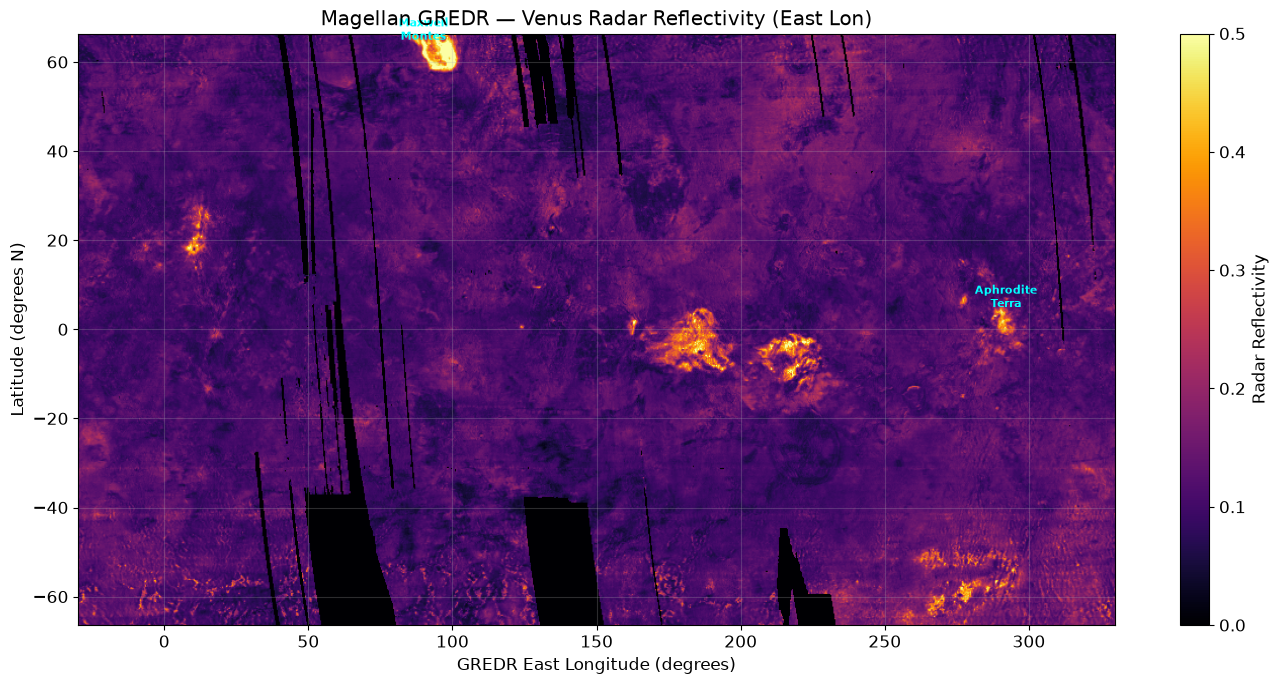

In [19]:
# Load the map and sanity-check known features
 
vmap.load_from_files()   # GDAL opens the .img and reads .lbl automatically
 
print("Known Venus radar features (West longitude convention):")
print()
print_feature_table()
print()
 
# Spot-check known bright features against the map
print("\nMap spot checks:")
for name, info in list(VENUS_RADAR_FEATURES.items())[:4]:
    r = vmap.reflectivity_at(info["lat"], info["lon_E"])
    print(f"  {name:<35}  map={r:.3f}  (expected ~{info['typ_refl']:.2f})")
 
# Plot the global map (no sub-Earth point yet)
fig = vmap.plot_map(title="Magellan GREDR — Venus Radar Reflectivity (East Lon)")
plt.show()

### Fetch the Sub-Earth Longitude for October 2026
 
The October 2026 inferior conjunction is the primary target for EVE.
We use the JPL Horizons API to get `ObsSub-LON` The West longitude of
the point on Venus aimed directly at Earth.
 
The sub-Earth longitude changes by roughly 1.7 degrees per day (Venus's sidereal
rotation rate as seen from Earth). This is slow enough that a single Horizons
call for the conjunction window gives us the full picture.

Fetching Venus sub-Earth longitudes from JPL Horizons...

Date                     ObsSub-LON (°W)  ObsSub-LAT (°N)
------------------------------------------------------------
  2026-09-01       247.84°        +4.615°
  2026-09-04       254.62°        +5.005°
  2026-09-07       261.28°        +5.398°
  2026-09-10       267.79°        +5.793°
  2026-09-13       274.14°        +6.186°
  2026-09-16       280.31°        +6.575°
  2026-09-19       286.27°        +6.957°
  2026-09-22       292.00°        +7.325°
  2026-09-25       297.48°        +7.675°
  2026-09-28       302.66°        +7.999°
  2026-10-01       307.53°        +8.285°
  2026-10-04       312.07°        +8.523°
  2026-10-07       316.26°        +8.698°
  2026-10-10       320.08°        +8.793°
  2026-10-13       323.56°        +8.793°
  2026-10-16       326.71°        +8.681°
  2026-10-19       329.60°        +8.447°
  2026-10-22       332.30°        +8.086° ← CONJUNCTION
  2026-10-25       334.91°        +7.603°
  2026-10-2

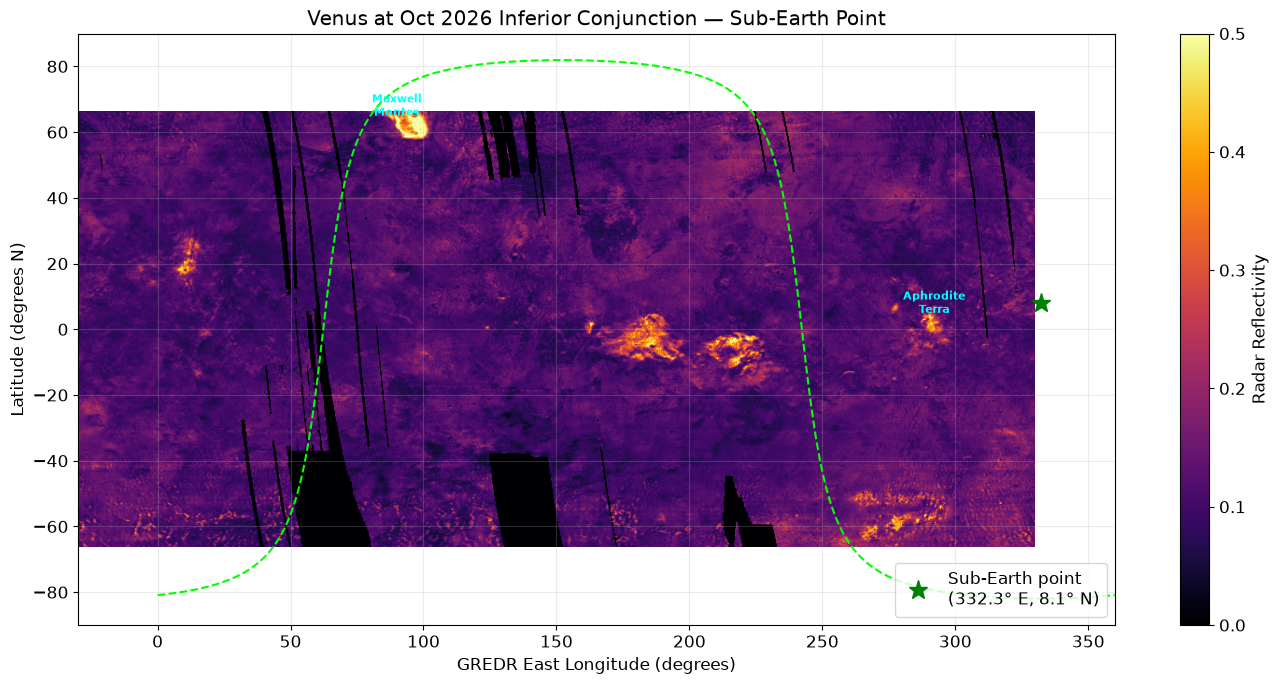

In [20]:
# October 2026 inferior conjunction window
# Duplicate and modify this cell to get another date window
# (Venus reaches inferior conjunction around 22-23 October 2026)
conj_window_start = datetime(2026, 9, 1,  0, 0, tzinfo=timezone.utc)
conj_window_stop  = datetime(2026, 12, 1, 0, 0, tzinfo=timezone.utc)
inferior_conjunction_date = datetime(2026, 10, 22, 0, 0, tzinfo=timezone.utc)  # approximate


# June 2028 inferior conjunction window
#conj_window_start_2028 = datetime(2028, 4, 1,  0, 0, tzinfo=timezone.utc)
#conj_window_stop_2028  = datetime(2028, 7, 15, 0, 0, tzinfo=timezone.utc)
#inferior_conjunction_2028 = datetime(2028, 6, 1, 0, 0, tzinfo=timezone.utc)

 
print("Fetching Venus sub-Earth longitudes from JPL Horizons...")
ephemeris = HorizonsVenusEphemeris()
sub_earth_rows = ephemeris.get_sub_earth_series(
    start=conj_window_start,
    stop=conj_window_stop,
    step="3d",   # every 3 days gives good resolution without flooding the API
)
 
print(f"\nDate                     ObsSub-LON (°W)  ObsSub-LAT (°N)")
print("-" * 60)
for row in sub_earth_rows:
    flag = " ← CONJUNCTION" if abs((row["utc"] - inferior_conjunction_date).days) <= 2 else ""
    print(f"  {row['utc'].strftime('%Y-%m-%d')}   {row['ObsSub_LON']:>10.2f}°       "
          f"{row['ObsSub_LAT']:>+7.3f}°{flag}")
 
# Show the map with the conjunction sub-Earth point
conj_row = min(sub_earth_rows,
               key=lambda r: abs((r["utc"] - inferior_conjunction_date).total_seconds()))
print(f"\nAt inferior conjunction (~{inferior_conjunction_date.date()}):")
print(f"  Sub-Earth Longitude: {conj_row['ObsSub_LON']:.2f}° East")
print(f"  Sub-Earth Latitude:  {conj_row['ObsSub_LAT']:.3f}° North")
 
fig = vmap.plot_map(
    sub_lon_east=conj_row["ObsSub_LON"],
    sub_lat=conj_row["ObsSub_LAT"],
    title=f"Venus at Oct 2026 Inferior Conjunction — Sub-Earth Point",
)
plt.show()

### Compute the Disk-Integrated Effective Albedo
 
For dishes that over-illuminate Venus (beam >> Venus angular diameter), the
radar cross section is:
 
    σ = π R² · ρ_eff
 
where ρ_eff is the power-weighted mean reflectivity over the visible hemisphere.
 
The integration uses a quasi-specular backscatter weight:
 
    w(Δ) = cos²(Δ)
 
where Δ is the angle from the sub-radar point. This is appropriate for
Venus's smooth plains at decimeter wavelengths. The exponent `n_backscatter`
can be varied — higher n gives more weight to the sub-radar region.
 
The Hagfors model tells us that the sub-radar region dominates, so this
integration is not just a simple average. It is a physically motivated
weighted average that concentrates on the area contributing most of the
return.

Computing disk-integrated effective albedo across the conjunction window...
(This takes a minute — integrating the map for each date.)

  Integrating... 0/31  (ObsSub-LON = 247.8°E)
  Integrating... 3/31  (ObsSub-LON = 267.8°E)
  Integrating... 6/31  (ObsSub-LON = 286.3°E)
  Integrating... 9/31  (ObsSub-LON = 302.7°E)
  Integrating... 12/31  (ObsSub-LON = 316.3°E)
  Integrating... 15/31  (ObsSub-LON = 326.7°E)
  Integrating... 18/31  (ObsSub-LON = 334.9°E)
  Integrating... 21/31  (ObsSub-LON = 343.3°E)
  Integrating... 24/31  (ObsSub-LON = 354.3°E)
  Integrating... 27/31  (ObsSub-LON = 8.5°E)
  Integrating... 30/31  (ObsSub-LON = 25.5°E)

Date           ObsSub-LON    ρ_eff   vs nominal 0.152
----------------------------------------------------------
  2026-09-01    247.8°E   0.1001   -1.81 dB
  2026-09-04    254.6°E   0.1008   -1.78 dB
  2026-09-07    261.3°E   0.1016   -1.75 dB
  2026-09-10    267.8°E   0.1025   -1.71 dB
  2026-09-13    274.1°E   0.1035   -1.67 dB
  2026-09-16    280.

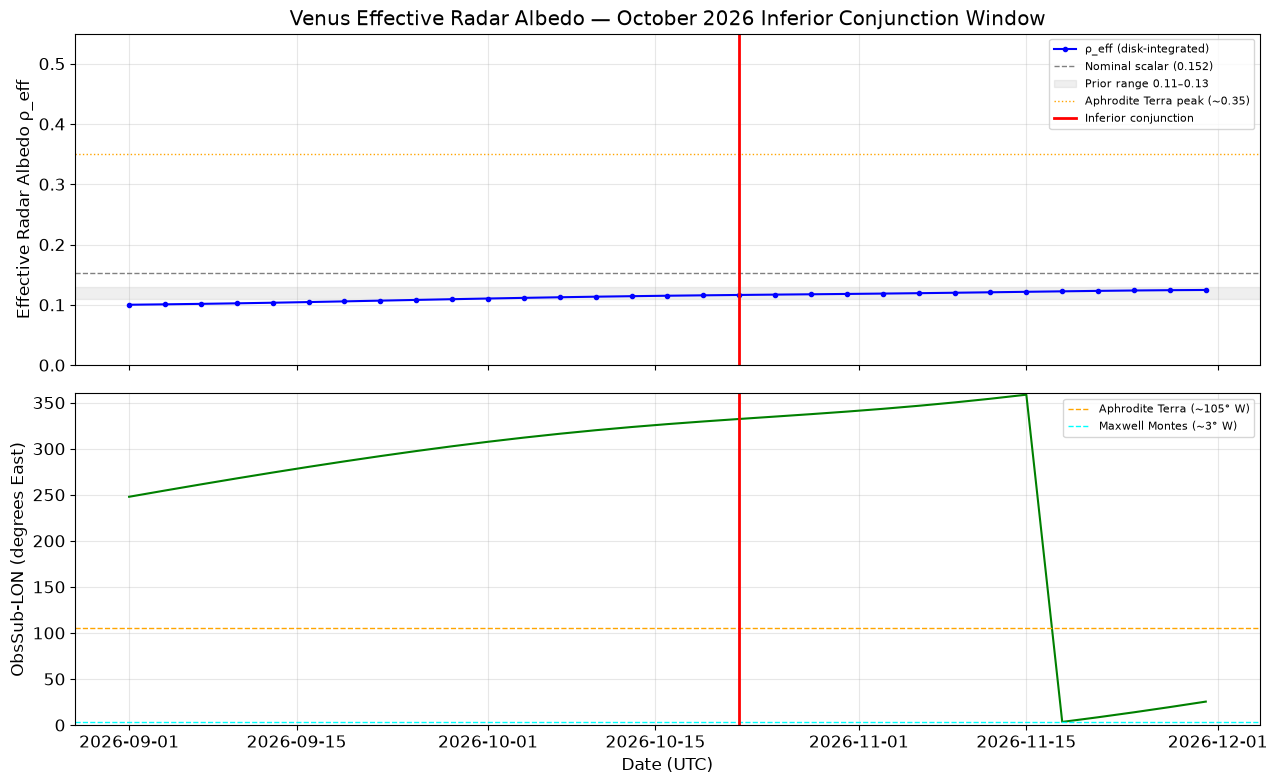

In [21]:
# Compute ρ_eff for the conjunction window
 
# Create the mapper (n=2: quasi-specular, appropriate for Venus plains at 2.3 GHz)
albedo_mapper = VenusAlbedoMapper(
    reflectivity_map=vmap,
    n_backscatter=2.0,          # quasi-specular; try 1.0 for Lambertian comparison
    grid_resolution_deg=0.5,    # 0.5° grid; ~0.5 s per date
)
 
print("Computing disk-integrated effective albedo across the conjunction window...")
print("(This takes a minute — integrating the map for each date.)\n")
 
albedo_results = albedo_mapper.albedo_series(
    start=conj_window_start,
    stop=conj_window_stop,
    step="3d",
)
 
print("\nDate           ObsSub-LON    ρ_eff   vs nominal 0.152")
print("-" * 58)
for r in albedo_results:
    delta_db = 10 * np.log10(r["albedo_eff"] / 0.152)
    flag = " ← near conjunction" if abs((r["utc_date"] - inferior_conjunction_date).days) <= 5 else ""
    print(f"  {r['utc_date'].strftime('%Y-%m-%d')}   {r['sub_lon_E']:>6.1f}°E   "
      f"{r['albedo_eff']:.4f}   {delta_db:+.2f} dB{flag}")
 
# Plot the albedo series
fig = albedo_mapper.plot_albedo_series(
    albedo_results,
    conjunction_date=inferior_conjunction_date,
    title="Venus Effective Radar Albedo — October 2026 Inferior Conjunction Window",
)
plt.show()

In [22]:
from skyfield.api import load, wgs84
from skyfield.almanac import find_discrete, risings_and_settings

site = wgs84.latlon(
    calculator.params.latitude,
    calculator.params.longitude,
    elevation_m=calculator.params.elevation
)

planets = load('de421.bsp')
ts = load.timescale()
earth = planets['earth']
venus = planets['venus']

print(f"{'Date':<12}  {'Peak Elev':>10}  {'UTC at Peak':>12}  {'Distance (km)':>15}")
print("-" * 58)

for entry in albedo_results:
    date = entry['utc_date']
    
    # Sample Venus elevation every 10 minutes through the day
    times = ts.utc(date.year, date.month, date.day, 
                   0, range(0, 1440, 10))  # every 10 min
    observer = earth + site
    alts = observer.at(times).observe(venus).apparent().altaz()[0]
    
    # Find the peak
    peak_idx = alts.degrees.argmax()
    peak_alt = alts.degrees[peak_idx]
    peak_time = times[peak_idx]
    
    # Get distance at peak elevation time
    astrometric = observer.at(peak_time).observe(venus)
    _, _, distance = astrometric.apparent().altaz()
    
    entry['elevation_deg'] = peak_alt
    entry['distance_km'] = distance.km
    entry['peak_utc'] = peak_time.utc_datetime()
    
    flag = " ← conjunction" if abs((entry['utc_date'] - inferior_conjunction_date).days) <= 5 else ""
    observable = "" if peak_alt > 0 else " [below horizon all day]"
    print(f"  {date.strftime('%Y-%m-%d')}   {peak_alt:>8.1f}°   "
          f"{peak_time.utc_strftime('%H:%M UTC'):>12}   "
          f"{distance.km:>14,.0f} km{flag}{observable}")

Date           Peak Elev   UTC at Peak    Distance (km)
----------------------------------------------------------
  2026-09-01       24.8°      14:10 UTC       82,253,080 km
  2026-09-04       23.6°      14:10 UTC       78,831,289 km
  2026-09-07       22.4°      14:10 UTC       75,458,293 km
  2026-09-10       21.3°      14:00 UTC       72,148,881 km
  2026-09-13       20.3°      14:00 UTC       68,896,179 km
  2026-09-16       19.3°      13:50 UTC       65,725,973 km
  2026-09-19       18.5°      13:40 UTC       62,643,993 km
  2026-09-22       17.7°      13:40 UTC       59,659,466 km
  2026-09-25       17.1°      13:30 UTC       56,805,095 km
  2026-09-28       16.5°      13:20 UTC       54,095,669 km
  2026-10-01       16.1°      13:10 UTC       51,555,670 km
  2026-10-04       15.9°      13:00 UTC       49,211,675 km
  2026-10-07       15.9°      12:40 UTC       47,096,819 km
  2026-10-10       16.0°      12:30 UTC       45,231,769 km
  2026-10-13       16.4°      12:10 UTC      

## Where do I Point the Telescope?

Here we calculate Venus's approximate coordinates at a particular time, such as the conjunction or at the conjunction-adjacent session windows. For example, Venus on October 22, 2026 will be near the Sun at inferior conjunction, at roughly RA 13h 30m, Dec -8°. By using Skyfield we can obtain the position at, for example, the middle of one of the 2.5 hour scheduled windows, or the position at the exact moment of conjunction. This is a fixed position. This gives the scheduler or telescope operator a sky position to work with in order to track Venus. 

Geocentric RA/Dec is prepared for things like instrument time request source entries. Green Bank Telescope scheduler (for example) uses these coordinates to assess LST pressure (Local Sidereal Time conflicts or variances) and visibility windows. All other position calculations in this notebook use topocentric coordinates (the observer is on Earth's surface) for elevation, Doppler, and dish pointing. GBT will compute its own topocentric pointing during observations using its internal ephemeris. In other words, these coordinates are the scheduler's reference only.

In [23]:
# find location of Venus at a particular time for applications for 
# time on scientific instruments such as Green Bank Observatory, Effelsberg,
# and others. 
ts = load.timescale()
eph = load('de421.bsp')
earth = eph['earth']
venus = eph['venus']

t = ts.utc(2026, 10, 22, 17, 0)  # time in UTC to generate position at peak
astrometric = earth.at(t).observe(venus)
ra, dec, distance = astrometric.radec()
print(f"Venus RA:  {ra}")
print(f"Venus Dec: {dec}")

Venus RA:  13h 46m 37.75s
Venus Dec: -18deg 13' 31.0"


## Dynamic Venus Radar Albedo in the Link Budget

Instead of using a fixed scalar for Venus radar albedo, we now use the
spatially-resolved Magellan GREDR reflectivity map to compute a
date-dependent effective albedo ρ_eff for each date in the conjunction window.

The approach:
1. JPL Horizons gives us the Venus sub-Earth longitude (ObsSub-LON) for each date
2. The Magellan GREDR map gives us pixel-level radar reflectivity across the surface
3. We integrate the map over the visible hemisphere weighted by a quasi-specular
   backscatter function w(Δ) = cos²(Δ), where Δ is the angle from the sub-radar point
4. The resulting ρ_eff replaces the fixed venus_radar_albedo in EVELinkBudget

Coordinate note: The GREDR map uses the Magellan mission coordinate frame (~1992).
JPL Horizons uses the IAU 2000 frame. These differ by approximately 186.5°, which
is applied automatically inside VenusAlbedoMapper.

The Magellan GREDR was collected at 2.385 GHz. Our link budget uses 2.304 GHz.
The ~3.5% frequency difference is a second-order effect — both frequencies probe
the same surface roughness scale and the spatial map is fully valid. The absolute
reflectivity values carry a small implicit frequency correction of a few percent,
well within the uncertainty from other model parameters.

We call the existing EVELinkBudget calculator directly, overriding venus_radar_albedo
for each date and reporting cnr_db_1hz — the same quantity used throughout this notebook.

In [24]:
print(f"calculator.params class: {calculator.params.__class__.__name__}")
print(f"calculator.params.rx_antenna_diameter_m: {calculator.params.rx_antenna_diameter_m}")
print(f"calculator.tx_params class: {calculator.tx_params.__class__.__name__ if calculator.tx_params else 'None'}")

from dataclasses import asdict
gbt = GBTLinkParameters()
print(f"GBT lna_noise_figure_db:  {gbt.lna_noise_figure_db}")
print(f"GBT lna_noise_figure_K:   {gbt.lna_noise_figure_K:.2f}")
print(f"GBT rx_antenna_diameter:  {gbt.rx_antenna_diameter_m}")
dwin = DwingelooLinkParameters()
print(f"Dwingeloo lna_noise_figure_db: {dwin.lna_noise_figure_db}")
print(f"Dwingeloo lna_noise_figure_K:  {dwin.lna_noise_figure_K:.2f}")


print("Scanning conjunction window with dynamic albedo...")
print(f"\n{'Date':<12}  {'ρ_eff':>6}  {'Elev':>6}  {'Dist (Mkm)':>10}  "
      f"{'CNR 1Hz':>9}  {'ΔCNR':>7}")
print("-" * 68)

# Nominal: use the actual inferior conjunction date entry
conj_entry = min(albedo_results,
                 key=lambda e: abs((e['utc_date'] - inferior_conjunction_date).days))
nominal = calculator.calculate_link_budget(
    conj_entry['distance_km'],
    elevation_deg=max(conj_entry['elevation_deg'], 5.0),  # clamp here too
    atmospheric_conditions='clear'
)
nominal_cnr_1hz = nominal['cnr_db_1hz']


scan_results = []
for entry in albedo_results:
    calculator.venus_radar_albedo = entry['albedo_eff']

    r = calculator.calculate_link_budget(
        entry['distance_km'],
        elevation_deg=max(entry['elevation_deg'], 5.0),  # clamp to 5° minimum
        atmospheric_conditions='clear'
    )

    delta = r['cnr_db_1hz'] - nominal_cnr_1hz
    flag = " ← conjunction" if abs((entry['utc_date'] - inferior_conjunction_date).days) <= 5 else ""
    print(f"  {entry['utc_date'].strftime('%Y-%m-%d')}  "
          f"{entry['albedo_eff']:.4f}  "
          f"{entry['elevation_deg']:>5.1f}°  "
          f"{entry['distance_km']/1e6:>9.2f}  "
          f"{r['cnr_db_1hz']:>+8.2f} dB  "
          f"{delta:>+6.2f} dB{flag}")

    scan_results.append({
        'utc_date':       entry['utc_date'],
        'albedo_eff':     entry['albedo_eff'],
        'elevation_deg':  entry['elevation_deg'],
        'distance_km':    entry['distance_km'],
        't_sys_k':        r['system_noise_temperature'],
        'cnr_db_1hz':     r['cnr_db_1hz'],
        'delta_cnr':      delta,
    })

# Restore nominal albedo
calculator.venus_radar_albedo = 0.152

best = max(scan_results, key=lambda r: r['cnr_db_1hz'])
print(f"\nBest day:    {best['utc_date'].strftime('%Y-%m-%d')}")
print(f"  ρ_eff:     {best['albedo_eff']:.4f}")
print(f"  Elevation: {best['elevation_deg']:.1f}°")
print(f"  Distance:  {best['distance_km']/1e6:.2f} million km")
print(f"  T_sys:     {best['t_sys_k']:.1f} K")
print(f"  CNR 1Hz:   {best['cnr_db_1hz']:+.2f} dB")
print(f"  ΔCNR:      {best['delta_cnr']:+.2f} dB vs nominal")

calculator.params class: DwingelooLinkParameters
calculator.params.rx_antenna_diameter_m: 25
calculator.tx_params class: None
GBT lna_noise_figure_db:  0.3
GBT lna_noise_figure_K:   20.74
GBT rx_antenna_diameter:  100.0
Dwingeloo lna_noise_figure_db: 0.629
Dwingeloo lna_noise_figure_K:  45.20
Scanning conjunction window with dynamic albedo...

Date           ρ_eff    Elev  Dist (Mkm)    CNR 1Hz     ΔCNR
--------------------------------------------------------------------
  2026-09-01  0.1001   24.8°      82.25    -14.79 dB  -13.83 dB
  2026-09-04  0.1008   23.6°      78.83    -14.04 dB  -13.08 dB
  2026-09-07  0.1016   22.4°      75.46    -13.27 dB  -12.30 dB
  2026-09-10  0.1025   21.3°      72.15    -12.47 dB  -11.50 dB
  2026-09-13  0.1035   20.3°      68.90    -11.64 dB  -10.67 dB
  2026-09-16  0.1046   19.3°      65.73    -10.79 dB   -9.83 dB
  2026-09-19  0.1058   18.5°      62.64     -9.93 dB   -8.96 dB
  2026-09-22  0.1070   17.7°      59.66     -9.05 dB   -8.08 dB
  2026-09-25

### Effect of Backscatter Exponent n on Dynamic Albedo

ρ_eff is the disk-integrated effective radar albedo. This is a single number that represents the weighted average reflectivity of the entire Venus hemisphere facing Earth. The weighting is heavier near the sub-Earth point because the backscatter is strongest there. The backscatter falls off toward the limb.

The backscatter exponent n controls the shape of that weighting function. Think of this like a spotlight beam pattern. n=1 (Lambertian) is a broad, gentle falloff. The entire visible hemisphere contributes roughly equally, like diffuse light off a matte wall. n=2 is a narrower beam, weighting the center more. n=4 and n=8 concentrate almost all the weight on the sub-radar bullseye, like a specular glint off a polished billiard ball.

What the table the code below generates is telling us is that at this particular sub-Earth longitude (332.3° W), our choice of n barely matters. Only 0.15 dB difference from Lambertian to near-Fresnel. This is physically meaningful. The terrain directly facing Earth at conjunction is relatively featureless plains. Whether you weight the center heavily or spread the weight across the disk, you're averaging over similar reflectivity values either way, so ρ_eff doesn't move much.

An interesting case, that we can run as a comparison, would be the same sweep centered on Aphrodite Terra or Maxwell Montes. There, because those features are genuinely brighter than the surrounding plains, a high-n model would give a noticeably higher ρ_eff than n=1, because it concentrates the weight on the bright center rather than diluting it with dimmer surroundings.

So the table is telling us that our October 2026 conjunction geometry is relatively n-insensitive, which is actually useful information. Our CNR estimate isn't going to swing wildly based on uncertainty in the scattering model for this particular window.

In [25]:
# Sensitivity analysis — backscatter exponent n
"""
How sensitive is ρ_eff to the choice of backscatter exponent n?
 
n = 1: Lambertian (rough surface)
n = 2: quasi-specular (smooth plains — appropriate for Venus at 2.3 GHz)
n = 4: very specular (appropriate for Maxwell Montes)
 
We evaluate at the conjunction sub-Earth point to understand the uncertainty.
"""
 
conj_lon = conj_row["ObsSub_LON"]
conj_lat = conj_row["ObsSub_LAT"]
 
print(f"\nSensitivity to backscatter exponent n")
print(f"(sub-Earth point: {conj_lon:.1f}° W, {conj_lat:.3f}° N)\n")
print(f"  {'n':>4}   {'ρ_eff':>8}   {'dB vs n=2':>10}   Interpretation")
print("-" * 60)

rho_ref = None
for n_val, desc in [(1, "Lambertian"), (2, "Quasi-specular (default)"),
                    (4, "Very specular"), (8, "Near-Fresnel")]:
    mapper_n = VenusAlbedoMapper(vmap, n_backscatter=n_val, grid_resolution_deg=1.0)
    r = mapper_n.effective_albedo(conj_lon, conj_lat)
    rho = r["albedo_eff"]

    if n_val == 2:
        rho_ref = rho

    if n_val == 2:
        delta = "(reference)"
    elif rho_ref is not None:
        delta = f"{10 * np.log10(rho / rho_ref):+.2f} dB"
    else:
        delta = "—"

    print(f"  {n_val:>4}   {rho:>8.4f}   {delta:>10}   {desc}")


Sensitivity to backscatter exponent n
(sub-Earth point: 332.3° W, 8.086° N)

     n      ρ_eff    dB vs n=2   Interpretation
------------------------------------------------------------
     1     0.1152            —   Lambertian
     2     0.1164   (reference)   Quasi-specular (default)
     4     0.1184     +0.07 dB   Very specular
     8     0.1206     +0.15 dB   Near-Fresnel


In [26]:
# What we actually get — October 2026
r_oct = albedo_mapper.effective_albedo(sub_lon_east_deg=332.3, sub_lat_deg=8.1)

# Best case — Aphrodite centered
r_best = albedo_mapper.effective_albedo(sub_lon_east_deg=105.0, sub_lat_deg=0.0)

print(f"October 2026:      ρ_eff = {r_oct['albedo_eff']:.4f}")
print(f"Aphrodite centered: ρ_eff = {r_best['albedo_eff']:.4f}")
print(f"Opportunity cost:   {10*np.log10(r_best['albedo_eff']/r_oct['albedo_eff']):+.2f} dB")

October 2026:      ρ_eff = 0.1164
Aphrodite centered: ρ_eff = 0.1209
Opportunity cost:   +0.17 dB


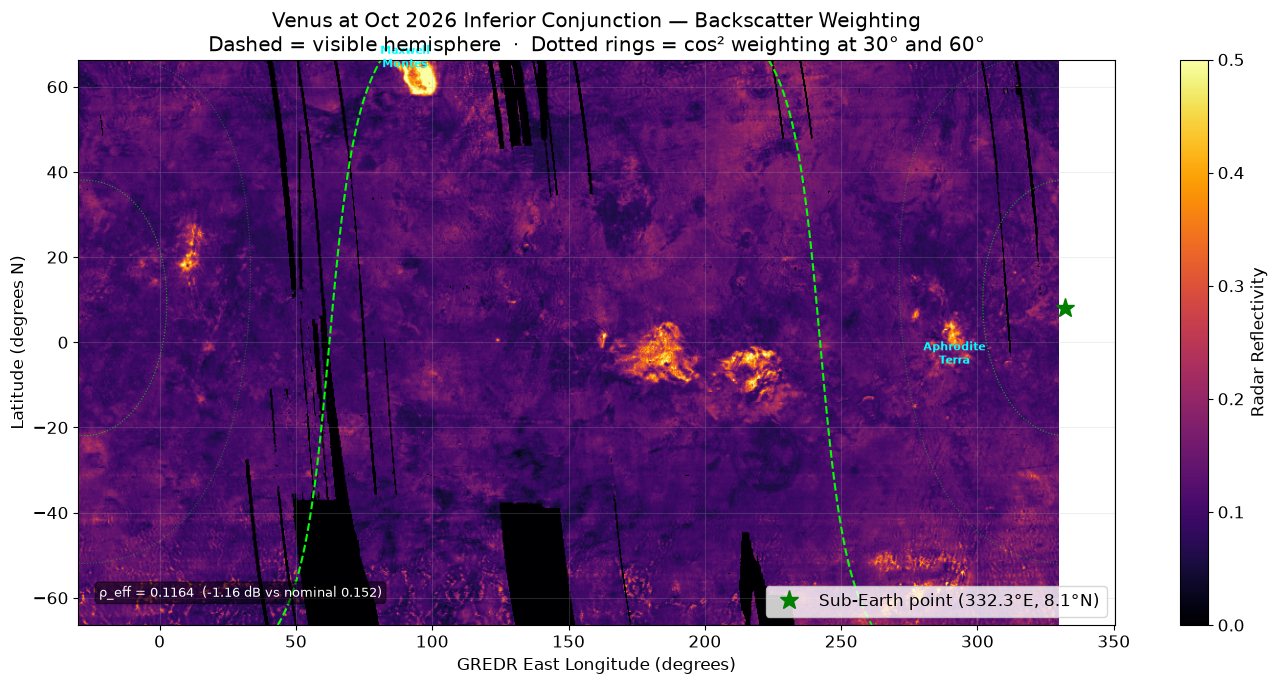

In [27]:
# Plot the map with sub-Earth point AND the backscatter weighting rings
# so the audience can immediately see how much Aphrodite contributes
# ── always recompute so the plot is self-contained ───────────────────────
albedo_result = albedo_mapper.albedo_for_date(
    datetime(2026, 10, 22, 0, 0, tzinfo=timezone.utc)
)

fig, ax = plt.subplots(figsize=(14, 7))
lats, lons, refl = vmap.reflectivity_grid()

im = ax.imshow(
    refl,
    extent=[lons[0], lons[-1], lats[-1], lats[0]],
    origin="upper", aspect="auto",
    cmap="inferno", vmin=0.0, vmax=0.5,
)
plt.colorbar(im, ax=ax, label="Radar Reflectivity")

sub_lon = albedo_result["sub_lon_E"]   # 332.3°E (GREDR frame)
sub_lat = albedo_result["sub_lat_N"]   # 8.1°N

# Draw the visible hemisphere boundary
phi_s = np.radians(sub_lat)
lam_s = np.radians(sub_lon)
lon_g = np.linspace(lons[0], lons[-1], 500)
lat_g = np.linspace(lats[-1], lats[0], 200)
LAM, PHI = np.meshgrid(np.radians(lon_g), np.radians(lat_g))
cos_d = np.sin(phi_s)*np.sin(PHI) + np.cos(phi_s)*np.cos(PHI)*np.cos(LAM - lam_s)
ax.contour(lon_g, lat_g, cos_d, levels=[0.0],
           colors="lime", linewidths=1.5, linestyles="--")

# Draw cos² weighting rings at 30°, 60° from sub-Earth point
# (these show how the disk integration weights the surface)
for delta_deg, alpha in [(30, 0.6), (60, 0.35)]:
    cos_level = np.cos(np.radians(delta_deg))
    ax.contour(lon_g, lat_g, cos_d, levels=[cos_level],
               colors="lime", linewidths=0.8,
               linestyles=":", alpha=alpha)

# Sub-Earth point star
ax.plot(sub_lon, sub_lat, "g*", markersize=14,
        label=f"Sub-Earth point ({sub_lon:.1f}°E, {sub_lat:.1f}°N)")

# Feature labels
ax.annotate("Maxwell\nMontes", xy=(90.1, 64.6),
            color="cyan", fontsize=8, ha="center", fontweight="bold")
ax.annotate("Aphrodite\nTerra", xy=(291.5, -5),
            color="cyan", fontsize=8, ha="center", fontweight="bold")

# CNR annotation
ax.text(0.02, 0.05,
        f"ρ_eff = {albedo_result['albedo_eff']:.4f}  "
        f"({10*np.log10(albedo_result['albedo_eff']/0.152):+.2f} dB vs nominal 0.152)",
        transform=ax.transAxes, color="white", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.5))

ax.set_xlabel("GREDR East Longitude (degrees)")
ax.set_ylabel("Latitude (degrees N)")
ax.set_title("Venus at Oct 2026 Inferior Conjunction — Backscatter Weighting\n"
             "Dashed = visible hemisphere  ·  Dotted rings = cos² weighting at 30° and 60°")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [28]:
# Independent verification — does the current code match the radar equation?
import numpy as np

# Bistatic-aware: mirror the same tx/rx split as calculate_link_budget()
tx = calculator.tx_params if calculator.tx_params is not None else calculator.params
rx = calculator.params

wavelength = rx.c / (rx.tx_frequency_mhz * 1e6)
R = 38_000_000 * 1000  # meters
R_v = calculator.venus_radius_km * 1000  # meters
sigma = calculator.venus_radar_albedo * np.pi * R_v**2

# Radar equation term by term in dB — immune to underflow from R^4
Pt_dBW = 10 * np.log10(tx.tx_power_w)
Gt_dBi = 10 * np.log10(
             tx.tx_antenna_efficiency *
             (np.pi * tx.tx_antenna_diameter_m / wavelength)**2)
Gr_dBi = 10 * np.log10(
             rx.rx_antenna_efficiency *
             (np.pi * rx.rx_antenna_diameter_m / wavelength)**2)

Pr_radar_eq_dBW = (
    Pt_dBW
    + Gt_dBi
    + Gr_dBi
    + 20 * np.log10(wavelength)
    + 10 * np.log10(sigma)
    - 10 * np.log10((4 * np.pi)**3)
    - 40 * np.log10(R)
)

# What the notebook's calculate_link_budget gives
r = calculator.calculate_link_budget(38_000_000)
Pr_notebook_dBW = r['rx_power_dbw']

print(f"Tx site:            {tx.__class__.__name__}")
print(f"Rx site:            {rx.__class__.__name__}")
print(f"Radar equation Pr:  {Pr_radar_eq_dBW:.3f} dBW")
print(f"Notebook Pr:        {Pr_notebook_dBW:.3f} dBW")
print(f"Difference:         {Pr_notebook_dBW - Pr_radar_eq_dBW:.3f} dB")
print(f"(Expected: ~-1.0 dB = tx_line_loss + rx_line_loss = 0.5 + 0.5 dB)")
print(f"(If this showed ~+16 dB, the old sign bug was present)")

Tx site:            DwingelooLinkParameters
Rx site:            DwingelooLinkParameters
Radar equation Pr:  -208.420 dBW
Notebook Pr:        -209.423 dBW
Difference:         -1.003 dB
(Expected: ~-1.0 dB = tx_line_loss + rx_line_loss = 0.5 + 0.5 dB)
(If this showed ~+16 dB, the old sign bug was present)


## Temporal Spread Worksheet

Gary K6MG writes "One other item I didn’t see addressed is the temporal spreading of the energy. Given a 12000Km diameter for venus the returned energy gets spread over a 12e6/3e8 = 40ms window. This dual temporal/spectral spreading presents a challenge to coherently summing the returned energy to detect a weak signal. OTOH it provides astronomers the mechanism to do planetary surface mapping by pixellating the surface into delay-doppler regions.

With a chip period of 2e-7 a total of 40e-3/2e-7=2e5 PN sequences need to be summed to collect all of the returned energy."

In [29]:
print(f"diameter of Venus is: {2*calculator.venus_radius_km * 1000} m")
print(f"chip_rate_hz from Zadoff-Chu calculator is {ZadoffChuSequenceEvaluator.chip_rate_hz} Hz")
print(f"speed of light is {calculator.params.c} meters per second")
temporal_spread = (2 * calculator.venus_radius_km * 1000)/calculator.params.c
print(f"Temporal spread is {temporal_spread} seconds")
chip_period = 1/ZadoffChuSequenceEvaluator.chip_rate_hz
print(f"With a chip period of {chip_period} seconds a total of {(temporal_spread/chip_period):.2f} chips need to be summed to collect all of the returned energy.")
num_chips = ZadoffChuSequenceEvaluator.get_number_chips()
print(f"Number of chips in our Zadoff-Chu sequence is {num_chips:.2f}")


diameter of Venus is: 12103600.0 m
chip_rate_hz from Zadoff-Chu calculator is 1000.0 Hz
speed of light is 299792458 meters per second
Temporal spread is 0.04037326382640353 seconds
With a chip period of 0.001 seconds a total of 40.37 chips need to be summed to collect all of the returned energy.
Integration time limit from Doppler rate: 1.0624 seconds
Integration time limit from Doppler spread: 0.6667 seconds
Coherent integration limited by Doppler spread
Using maximum integration time of 0.6667 seconds
Number of chips in our Zadoff-Chu sequence is 666.67


## Planetary Radar Detector

So far, we've generally assumed that we are attempting communications. Most of the signals we are interested in are relatively complex digital communications protocols. We're trying to detect, demodulate, and decode so that we can retrieve the information encoded within them.

What if we just want to prove we can bounce a very simple signal off Venus? 

In this case, the example Python notebook and SigMF files from CAMRAS from the March 2025 EVE event are the way to go.

Please visit https://data.camras.nl/venus/ and read on for how to use the archive.

### How to Process an Earth-Venus-Earth Radar Return Signal Using CAMRAS Data

With receiver data successfully collected by Dwingeloo and Stockert amateur radio astronomy sites during the Earth-Venus-Earth communications event on 22 March 2025, attention moved to processing the data to see if the transmitted carrier wave signal could be detected. 

Four transmissions of a carrier wave from the Dwingeloo radio astronomy site were made. Each transmission was 278 seconds long. This time span was selected because it equaled the expected round-trip time from Earth to Venus and back. This would allow the transmitter to transmit for the round trip time, shut down, and then immediately begin receiving what should be the leading edge of the reflected radio signal. Both Dwingeloo and Stockert made time-coordinated in-phase and quadrature (IQ) recordings of the receive spectrum. 

IQ samples are complex numbers that are created by sampling a received waveform. IQ samples fully specify any waveform, as long as they are taken at a rate faster than twice the bandwidth of the recorded signal. These IQ time series recordings are then mathematically evaluated in order to reveal the reflected carrier wave spike in the frequency domain. 

Raw data (at 1 MSps), decimated data (at 5 kSps), and the example data processing Python Notebook are available from https://data.camras.nl/venus/

The data files are in SigMF format. This format is widely used for IQ signal data recordings. A data file, containing IQ samples, is paired with a metadata file, which has a variety of metadata describing the conditions and configurations of recorded data. Learn more about SigMF at https://sigmf.org

In addition to the SigMF files and a Python Notebook that performs the data analysis, there are also two comma separated value (CSV) files containing the expected frequency offsets and Doppler rates for RX timestamps. There is one for Stockert and one for Dwingeloo. These values are needed by the script in order to correct the received samples frequency shifts due to Doppler. 

Once the notebook eve-cw-detect-example.ipynb is downloaded from the site, then all of the 5 kSps files, dwingeloo_venus_doppler.csv and stockert_venus_doppler.csv should also be downloaded. 

While the 1 MSps files are higher resolution, the 5 kSps files are more than enough resolution to carry out the math. It takes much less time to process these smaller lower resolution files than the larger higher resolution files, and the results will be exactly the same. 

Note: There is a bug in the python package sigmf version 1.2.8 that prevents these files from loading. Please install 1.2.6 or a version greater than 1.2.8. Or, modify the script to set up a SigMFFile instace manually, to evade the bug. 

Run the script, and if all goes well, the visualization will show a spike for the carrier wave. Success!

What is this script doing?

Here is a summary of the most important calculations. 

The notebook loads the recorded IQ data SigMF files and the Doppler information from CSV files. It then compensates for both the Doppler shift and Doppler rate of change using phase rotation. 

#### Compensate for Doppler and Doppler rate
dr = np.repeat(doppler_rate, len(data) / len(doppler_rate))
t_s = np.arange(len(data)) / fs
fdrift = -dr # Doppler rate
f0_Hz = -expected_freq_offset # Doppler
phi_Hz = (fdrift * t_s**2) / 2 + (f0_Hz * t_s)  # Instantaneous phase.
phi_rad = 2 * np.pi * phi_Hz  # Convert to radians.
data = data * np.exp(1j * phi_rad)

This means our signal will be centered at 0 Hz offset for the rest of the processing. 

#### Coherent Processing
Next, we do some coherent processing. Coherent processing means that we preserve the phase information of the signal. Non-coherent processing just looks at the amplitude. Fast Fourier Transforms (FFT) preserve magnitude and phase. 

spectrum = np.fft.fftshift(np.fft.fft(data.reshape(-1, int(sample_rate))))

The data is reshaped to have segments of length sample_rate (which is 5000 samples per second), meaning each FFT operation is performed on exactly 1 second of data. This is the coherent integration time used in the experiment. 

This is less than the maximum coherency time available due to Doppler rate of change limitations (~1.3 seconds), but it is larger than another maximum limit due to Doppler Spread from Venus' rotation (we calculated a much lower 0.03 seconds based on 31 Hz). The reasoning for being able to use 1 second coherent integration time (based on a Doppler Spread of 1Hz) is that the updated Doppler Spread is not as bad as we originally calculated 

#### Non-Coherent Processing
After obtaining the FFT results, the notebook performs non-coherent integration by averaging the magnitudes of the FFT outputs. 

This means it discards the phase information and combines power/energy over the entire recording run. 
spec_sum = np.mean(np.abs(spectrum), axis=0)

The axis=0 parameter means it's averaging across multiple 1-second segments, effectively performing non-coherent integration over the entire 278 second long recording duration. This allows us to integrate over much longer periods than would be possible with purely coherent integration. 

#### Get Involved
Dwingeloo's Thomas Telkamp invites the community to expand on and improve the Python notebook, saying in late March 2025, "A few remarks: 1) use the 5ksps files, 2) there is an example notebook now on how to process the data, and 3) you’re not supposed to duplicate it, but to improve it!" 

Also, please read the excellent analysis of the event from Dr. Daniel Estevez at https://destevez.net/2025/04/analysis-of-the-camras-venus-radar-experiment/ This analysis was used in our Doppler Spread section above.

And, additional details from Cees Bassa can be found at https://www.camras.nl/en/blog/2025/first-venus-bounce-with-the-dwingeloo-telescope/


# Appendix A

## ORI Earth-Venus-Earth Communications Development Roadmap
Note: the checkboxes for each task listed below _may not_ automatically render if you are viewing this document on GitHub. If you want to see completed vs. uncompleted tasks, then you will need to see the PDF rendering of this document, or render it to a viewer yourself. 

## Phase 1: Foundation and Research (3-4 months)

### Documentation and Requirements
- [x] Document full link budget analysis (this notebook)
- [x] Compile SDR Capabilities (zc706/adrv9009 or any partner SDR system)
- [x] Create detailed Doppler analysis (in this notebook)
- [x] Define custom mode specifications (CNR in 1Hz now known)

#### Custom Mode Specficiation
- [x] Doppler-delay channel protocol modeling
- [x] Doppler-delay channel protocol article
- [ ] Doppler-delay channel protocol specification

### Community Engagement
- [x] Present project on ORI channels
- [x] Recruit additional developers (mailing list, Slack)
- [x] Set up project definition and documentation (this document)

## Phase 2: Core Development (6-8 months)
### Integration Planning
- [x] SDR selection and acquisition: zc706/adrv9009, zcu102/adrv9009 or 9002, new hardware
- [x] Interface definition for hardware
- [x] Test equipment requirements (Remote Labs confirmed)
- [x] Performance measurement plans (in notebook)

## Phase 3: Integration and Testing (4-6 months)

### Hardware Integration
- [x] SDR integration (SigMF files produced)

## Phase 4: Optimization and Documentation (3-4 months)

### Community Resources
- [x] Example configurations
- [x] Tutorial development
- [x] Test data publication
- [x] Contribution guidelines

## Phase 5: Deployment and Validation (3-4 months)

### Field Testing (EME stations as proxies until October 2026)
- [x] Initial station setup (may be very narrow cases if remote access not available)
- [ ] Performance validation

### Final Documentation
- [x] Test results publication
- [ ] Performance results publication

### Community Support
- [ ] Training materials
- [x] Support documentation
- [x] Schedule of next opportunity for communications attempts October 2026
- [x] Future development plans

## Ongoing Activities

### Community Engagement
- [x] Regular progress updates (Inner Circle, email, published video recordings)
- [x] Technical presentations (IEEE vTools events)
- [ ] Conference participation
- [x] Developer meetings

### Development Support
- [x] Code review process (weekly meetups)
- [x] Bug tracking (Github Issues Tracker)
- [x] Feature requests (Slack, email, meetups)
- [ ] Performance monitoring

### Documentation Maintenance
- [x] Regular documentation updates
- [x] Performance reports
- [x] Configuration Artifacts Recorded
- [x] Best practices documentation

## Review Points
- [x] Weekly progress reviews
- [x] Monthly milestone assessments (Inner Circle Newsletter)
- [x] Community feedback sessions (vTools crosslisting, email list)
- [x] Performance validation checks (Doppler spread updated from March 2025 event)
- [x] Documentation reviews (ongoing)
